In [5]:
               
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import Dataset, DataLoader, random_split
# import torchvision.transforms as transforms
# from torchvision.models import vgg16
# from PIL import Image
# import matplotlib.pyplot as plt
# from torch.nn.functional import grid_sample, affine_grid
# import logging
# import cv2  # Để vẽ attentional regions sau này
# import warnings
# warnings.filterwarnings('ignore')

# # Setup logging
# logging.basicConfig(level=logging.INFO)
# logger = logging.getLogger(__name__)

# # Hyperparams (theo paper)
# L = 17  # Số labels (AID multilabel)
# K = 512  # Channels per parcel
# IMG_SIZE = 224  # Input size for VGG-16
# BATCH_SIZE = 32  # Giảm nếu OOM (e.g., 16)
# EPOCHS = 50  # Giảm để test nhanh
# LR = 1e-4
# DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# logger.info(f'Using device: {DEVICE}')

# # Transform cho data
# transform = transforms.Compose([
#     transforms.Resize((IMG_SIZE, IMG_SIZE)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet norms
# ])

# print("Imports completed successfully!")

In [6]:
# ----- Imports -----
import os
import glob
import gc
import logging
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
import torchvision.transforms as transforms
from torchvision.models import resnet50
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
import cv2
from sklearn.metrics import f1_score, average_precision_score

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
warnings.filterwarnings('ignore')

# ----- Hyperparams -----
L = 16  # Số label giảm từ 17 xuống 16, bỏ mobile-home
K = 512  # channels per parcel
IMG_SIZE = 224
BATCH_SIZE = 32  # giảm nếu OOM (e.g., 16)
EPOCHS = 100
LR = 1e-4
PATIENCE = 10  # Tăng để converge
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True
logger.info(f'Using device: {DEVICE}')

# ----- Transform -----
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
transform_val_test = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Cell 1 completed: Imports and transforms ready!")

Cell 1 completed: Imports and transforms ready!


Train 2160, Val 240, Test 600, Batch 32
Phân phối nhãn (số positive samples per label):
airplane       99
bare-soil    1475
buildings    2161
cars         2026
chaparral     112
court         344
dock          271
field         214
grass        2295
pavement     2328
sand          259
sea           221
ship          284
tanks         108
trees        2406
water         852
dtype: int64


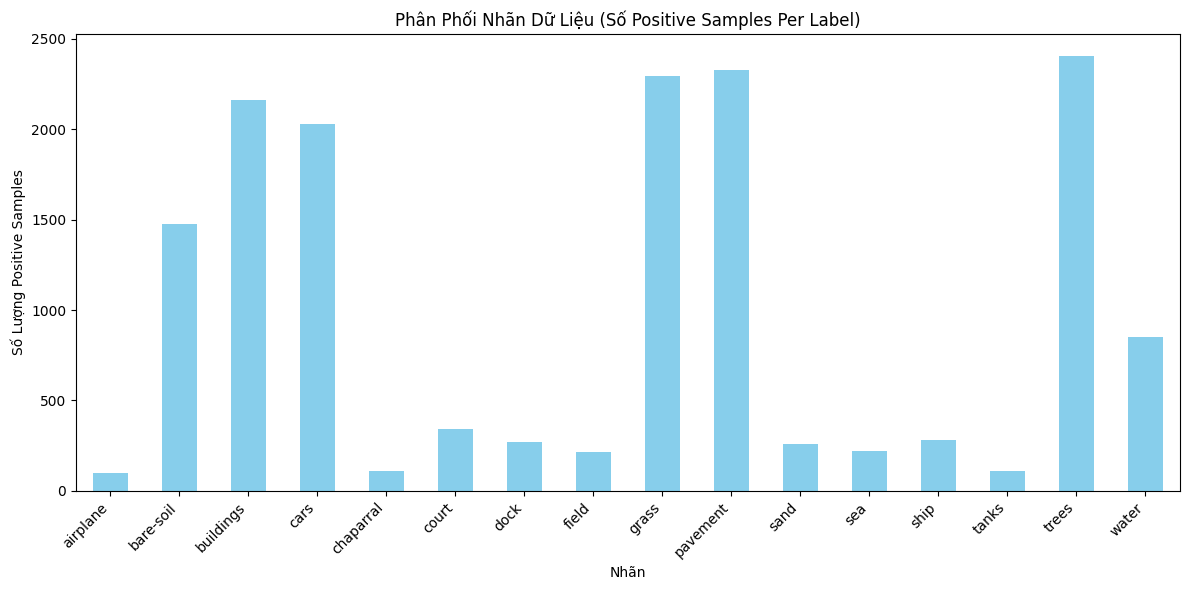

Plot saved to /kaggle/working/label_distribution.png. Kiểm tra imbalance: classes hiếm như 'dock' cần weighted loss.


In [7]:

# ----- Dataset -----
class MultilabelDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.labels_df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform
        first_col = self.labels_df.columns[0]
        self.labels_df = self.labels_df.rename(columns={first_col: 'image_name'})
        self.label_columns = self.labels_df.columns[1:].tolist()
        # Loại bỏ nhãn mobile-home
        if 'mobile-home' in self.label_columns:
            self.label_columns.remove('mobile-home')
        assert len(self.label_columns) == L, f'Expected {L} labels, got {len(self.label_columns)}'
        available_files = set()
        for pattern in ['**/*.tif', '**/*.jpg', '**/*.png']:
            file_list = glob.glob(os.path.join(img_dir, pattern), recursive=True)
            for f in file_list:
                base_name = os.path.basename(f).rsplit('.', 1)[0].lower()
                available_files.add(base_name)
        self.labels_df['image_name_lower'] = self.labels_df['image_name'].str.lower()
        self.labels_df = self.labels_df[self.labels_df['image_name_lower'].isin(available_files)]
        self.labels_df = self.labels_df.drop('image_name_lower', axis=1)
        if len(self.labels_df) == 0:
            raise ValueError(f"No matching images in {img_dir}!")

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        img_name_base = self.labels_df.iloc[idx]['image_name'].lower()
        found_path = None
        for ext in ['tif', 'jpg', 'png']:
            candidates = glob.glob(os.path.join(self.img_dir, f'**/{img_name_base}.{ext}'), recursive=True)
            if candidates:
                found_path = candidates[0]
                break
        if found_path is None:
            raise FileNotFoundError(f"Image not found for '{img_name_base}'")
        image = Image.open(found_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        labels = torch.tensor(self.labels_df.iloc[idx][self.label_columns].values.astype(np.float32))
        return image, labels, self.labels_df.iloc[idx]['image_name']

# ----- Prepare data loaders -----
DATA_PATH = '/kaggle/input/aid-multilabel/AID_multilabel/'
CSV_PATH = os.path.join(DATA_PATH, 'multilabel.csv')
train_img_dir = os.path.join(DATA_PATH, 'images/images_tr')
test_img_dir = os.path.join(DATA_PATH, 'images/images_test')

full_train_dataset = MultilabelDataset(CSV_PATH, train_img_dir, transform=transform_train)
val_size = max(1, int(0.1 * len(full_train_dataset)))
train_size = len(full_train_dataset) - val_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))
test_dataset = MultilabelDataset(CSV_PATH, test_img_dir, transform=transform_val_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

logger.info(f'Train {len(train_dataset)}, Val {len(val_dataset)}, Test {len(test_dataset)}, Batch {BATCH_SIZE}')
print(f"Train {len(train_dataset)}, Val {len(val_dataset)}, Test {len(test_dataset)}, Batch {BATCH_SIZE}")

# ----- Visualize label distribution -----
df = pd.read_csv(CSV_PATH)
first_col = df.columns[0]
df = df.rename(columns={first_col: 'image_name'})
label_columns = df.columns[1:].tolist()
if 'mobile-home' in label_columns:
    label_columns.remove('mobile-home')  # Loại bỏ mobile-home khỏi phân phối
positive_counts = df[label_columns].sum()
print("Phân phối nhãn (số positive samples per label):")
print(positive_counts)

plt.figure(figsize=(12, 6))
positive_counts.plot(kind='bar', color='skyblue')
plt.title('Phân Phối Nhãn Dữ Liệu (Số Positive Samples Per Label)')
plt.xlabel('Nhãn')
plt.ylabel('Số Lượng Positive Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
output_path = '/kaggle/working/label_distribution.png'
plt.savefig(output_path)
plt.show()
print(f"Plot saved to {output_path}. Kiểm tra imbalance: classes hiếm như 'dock' cần weighted loss.")

Nhãn hiếm (<300 samples, bỏ mobile-home): ['airplane', 'chaparral', 'dock', 'field', 'sand', 'sea', 'ship', 'tanks']
Updated pos_weight after augmentation: tensor([ 6.6279,  0.7986,  0.3262,  0.4318,  8.4839, 12.9242,  2.4232,  5.4921,
         0.3749,  0.3167,  4.1143,  2.9547,  2.2960,  8.6439,  0.3393,  1.9450])


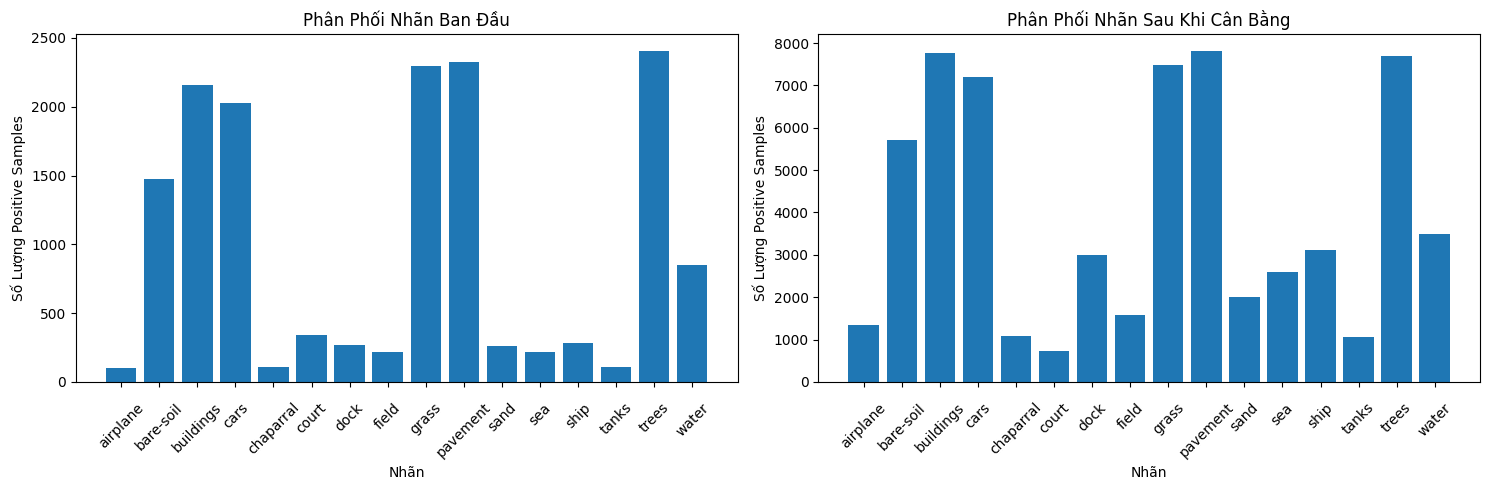

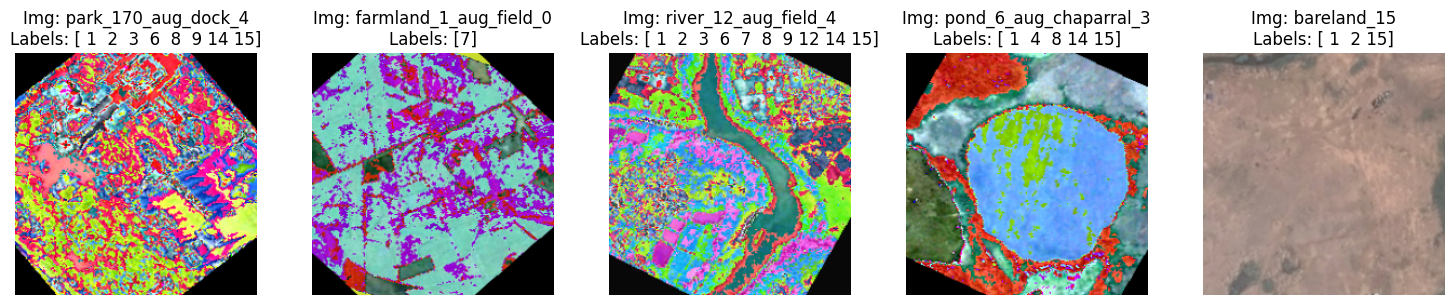

Cell 2.5 completed: Augmented rare classes with custom num_aug, weighted sampler, and visualization!


In [8]:
# # ===== Cell 2.5: Augment + Rebalance Dataset =====
# from torch.utils.data import ConcatDataset, random_split, DataLoader
# from torchvision.transforms import ToPILImage
# import numpy as np
# import random
# from collections import defaultdict

# # --- Xác định nhãn hiếm (<300 samples, bỏ mobile-home) ---
# rare_labels = [label for label in positive_counts[positive_counts < 300].index.tolist() if label != 'mobile-home']
# print("Nhãn hiếm (<300 samples, bỏ mobile-home):", rare_labels)

# # --- Tạo dataset copy để augment ---
# aug_dataset = copy.deepcopy(full_train_dataset)
# aug_transform = transforms.Compose([
#     transforms.Resize((IMG_SIZE, IMG_SIZE)),
#     transforms.RandomHorizontalFlip(p=0.5),
#     transforms.RandomRotation(90),
#     transforms.ColorJitter(brightness=0.2, contrast=0.2),
#     transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

# def augment_rare_samples(dataset, rare_labels, positive_counts):
#     aug_data = []
#     to_pil = ToPILImage()
#     for idx in range(len(dataset)):
#         img, labels, img_name = dataset[idx]
#         for label_idx, label in enumerate(dataset.label_columns):
#             if labels[label_idx] == 1 and label in rare_labels:
#                 img_pil = to_pil(img)
#                 # tuỳ mức độ augment
#                 num_aug = 15 if positive_counts[label] < 100 else (10 if positive_counts[label] < 200 else 5)
#                 for i in range(num_aug):
#                     aug_img = aug_transform(img_pil)
#                     aug_data.append((aug_img, labels, f"{img_name}_aug_{label}_{i}"))
#     return aug_data

# aug_samples = augment_rare_samples(aug_dataset, rare_labels, positive_counts)
# print(f"Generated {len(aug_samples)} augmented samples cho nhãn hiếm")

# # Gộp dataset gốc + aug
# train_dataset_full = ConcatDataset([full_train_dataset, aug_samples])

# # --- Hàm rebalance theo median ---
# def rebalance_dataset(dataset, label_columns, target="median"):
#     counts = defaultdict(int)
#     for _, labels, _ in dataset:
#         for idx, val in enumerate(labels):
#             if val == 1:
#                 counts[label_columns[idx]] += 1

#     target_count = int(np.median(list(counts.values()))) if target=="median" else int(np.mean(list(counts.values())))
#     print("Target count per label:", target_count)

#     label_to_indices = defaultdict(list)
#     for idx, (_, labels, _) in enumerate(dataset):
#         for label_idx, val in enumerate(labels):
#             if val == 1:
#                 label_to_indices[label_columns[label_idx]].append(idx)

#     new_indices = []
#     for label, indices in label_to_indices.items():
#         if len(indices) < target_count:  # oversample
#             extra = np.random.choice(indices, target_count - len(indices), replace=True)
#             new_indices.extend(indices + extra.tolist())
#         elif len(indices) > target_count:  # undersample
#             new_indices.extend(random.sample(indices, target_count))
#         else:
#             new_indices.extend(indices)

#     new_indices = list(set(new_indices))  # loại trùng
#     balanced_dataset = [dataset[i] for i in new_indices]
#     return balanced_dataset

# # Áp dụng rebalance
# balanced_dataset = rebalance_dataset(train_dataset_full, full_train_dataset.label_columns, target="median")

# # --- Chia train/val ---
# val_size = max(1, int(0.2 * len(balanced_dataset)))
# train_size = len(balanced_dataset) - val_size
# train_dataset, val_dataset = random_split(balanced_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

# # --- Tạo DataLoader ---
# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
# val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

# # --- Vẽ lại phân phối ---
# def compute_label_distribution(dataset, label_columns):
#     counts = np.zeros(len(label_columns))
#     for _, labels, _ in dataset:
#         counts += labels.numpy()
#     return counts

# original_counts = positive_counts
# balanced_counts = compute_label_distribution(balanced_dataset, full_train_dataset.label_columns)

# plot_label_distribution(original_counts, balanced_counts, full_train_dataset.label_columns)

# print("Cell 2.5 completed: Augment + Rebalance + Visualization!")
# ===== Cell 2.5: Augment + Rebalance Dataset =====
from torch.utils.data import ConcatDataset, random_split, DataLoader
from torchvision.transforms import ToPILImage
import numpy as np
import random
from collections import defaultdict

# --- Xác định nhãn hiếm (<300 samples, bỏ mobile-home) ---
rare_labels = [label for label in positive_counts[positive_counts < 300].index.tolist() if label != 'mobile-home']
print("Nhãn hiếm (<300 samples, bỏ mobile-home):", rare_labels)

# --- Tạo dataset copy để augment ---
aug_dataset = copy.deepcopy(full_train_dataset)
aug_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(90),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def augment_rare_samples(dataset, rare_labels, positive_counts):
    aug_data = []
    to_pil = ToPILImage()
    for idx in range(len(dataset)):
        img, labels, img_name = dataset[idx]
        for label_idx, label in enumerate(dataset.label_columns):
            if labels[label_idx] == 1 and label in rare_labels:
                img_pil = to_pil(img)
                # tuỳ mức độ augment
                num_aug = 15 if positive_counts[label] < 100 else (10 if positive_counts[label] < 200 else 5)
                for i in range(num_aug):
                    aug_img = aug_transform(img_pil)
                    aug_data.append((aug_img, labels, f"{img_name}_aug_{label}_{i}"))
    return aug_data

aug_samples = augment_rare_samples(aug_dataset, rare_labels, positive_counts)
print(f"Generated {len(aug_samples)} augmented samples cho nhãn hiếm")

# Gộp dataset gốc + aug
train_dataset_full = ConcatDataset([full_train_dataset, aug_samples])

# --- Hàm rebalance theo median ---
def rebalance_dataset(dataset, label_columns, target="median"):
    counts = defaultdict(int)
    for _, labels, _ in dataset:
        for idx, val in enumerate(labels):
            if val == 1:
                counts[label_columns[idx]] += 1

    target_count = int(np.median(list(counts.values()))) if target=="median" else int(np.mean(list(counts.values())))
    print("Target count per label:", target_count)

    label_to_indices = defaultdict(list)
    for idx, (_, labels, _) in enumerate(dataset):
        for label_idx, val in enumerate(labels):
            if val == 1:
                label_to_indices[label_columns[label_idx]].append(idx)

    new_indices = []
    for label, indices in label_to_indices.items():
        if len(indices) < target_count:  # oversample
            extra = np.random.choice(indices, target_count - len(indices), replace=True)
            new_indices.extend(indices + extra.tolist())
        elif len(indices) > target_count:  # undersample
            new_indices.extend(random.sample(indices, target_count))
        else:
            new_indices.extend(indices)

    new_indices = list(set(new_indices))  # loại trùng
    balanced_dataset = [dataset[i] for i in new_indices]
    return balanced_dataset

# Áp dụng rebalanc
balanced_dataset = rebalance_dataset(train_dataset_full, full_train_dataset.label_columns, target="median")

# --- Chia train/val ---
val_size = max(1, int(0.2 * len(balanced_dataset)))
train_size = len(balanced_dataset) - val_size
train_dataset, val_dataset = random_split(balanced_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

# --- Tạo DataLoader ---
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

# --- Vẽ lại phân phối ---
def compute_label_distribution(dataset, label_columns):
    counts = np.zeros(len(label_columns))
    for _, labels, _ in dataset:
        counts += labels.numpy()
    return counts

original_counts = positive_counts
balanced_counts = compute_label_distribution(balanced_dataset, full_train_dataset.label_columns)

plot_label_distribution(original_counts, balanced_counts, full_train_dataset.label_columns)

print("Cell 2.5 completed: Augment + Rebalance + Visualization!")

In [9]:

# ----- Model components -----
def init_weights_glorot(module):
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        nn.init.xavier_uniform_(module.weight)
        if module.bias is not None:
            nn.init.constant_(module.bias, 0.0)

# SpatialTransformer
class SpatialTransformer(nn.Module):
    def __init__(self, output_size=7, debug=False):
        super().__init__()
        self.output_size = output_size
        self.debug = debug
        self.debug_printed = False
        theta_init = torch.zeros(L, 2, 3)  # L=16
        theta_init[:, 0, 0] = 1.0
        theta_init[:, 1, 1] = 1.0
        self.theta = nn.Parameter(theta_init)

    def forward(self, x):
        B = x.shape[0]
        output, grids = [], []
        for l in range(L):  # L=16
            theta_l = self.theta[l].repeat(B, 1, 1)
            out_size = torch.Size([B, K, self.output_size, self.output_size])
            grid = F.affine_grid(theta_l, out_size, align_corners=False)
            x_slice = x[:, l]
            attn_x = F.grid_sample(x_slice, grid, mode='bilinear', align_corners=False, padding_mode='zeros')
            output.append(attn_x)
            grids.append(grid)
        attn_features = torch.stack(output, dim=1)
        if self.debug and not self.debug_printed:
            print(f"STN shapes: x_slice {x_slice.shape}, attn_x {attn_x.shape}, attn_features {attn_features.shape}")
            self.debug_printed = True
        return attn_features, grids

# RelationalInference
class RelationalInference(nn.Module):
    def __init__(self, in_channels=1024, hidden=512):
        super().__init__()
        self.pairwise_conv = nn.Conv2d(in_channels, K, kernel_size=1)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(K, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
            nn.Sigmoid()
        )

    def forward(self, attn_features):
        B = attn_features.shape[0]
        device = attn_features.device
        logits = torch.zeros(B, L, device=device)  # L=16
        for l in range(L):
            A_l = attn_features[:, l]
            relations = []
            for m in range(L):
                if m == l: continue
                A_m = attn_features[:, m]
                concat = torch.cat([A_l, A_m], dim=1)
                pairwise = self.pairwise_conv(concat)
                pooled = self.gap(pairwise).view(B, -1)
                rel = self.mlp(pooled)
                relations.append(rel)
            if relations:
                logits[:, l] = torch.sum(torch.stack(relations), dim=0).squeeze(1)
        return logits

# AttentionALRNCNN
class AttentionALRNCNN(nn.Module):
    def __init__(self, num_classes=L, backbone='resnet50', feature_size=7, debug=False):
        super().__init__()
        self.num_classes = num_classes  # L=16
        self.debug = debug
        self.debug_printed = False
        resnet = resnet50(pretrained=True)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.feature_channels = 2048
        self.label_wise_conv = nn.Conv2d(self.feature_channels, K * num_classes, kernel_size=1)  # K * 16
        self.stn = SpatialTransformer(feature_size, debug)
        self.rel_inference = RelationalInference(in_channels=2 * K)

    def forward(self, x):
        B = x.shape[0]
        features = self.backbone(x)
        if self.debug and not self.debug_printed:
            print(f"Backbone features shape: {features.shape}")
            self.debug_printed = True
        label_features = self.label_wise_conv(features)
        label_features = label_features.view(B, self.num_classes, K, *features.shape[2:])  # 16 nhãn
        attn_features, grids = self.stn(label_features)
        logits = self.rel_inference(attn_features)
        return logits, attn_features, grids

model = AttentionALRNCNN(num_classes=L, debug=True).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
logger.info(f'Model with ResNet50: {total_params:,} params')
print("Cell 3 completed: Model initialized!")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 190MB/s] 


Cell 3 completed: Model initialized!


In [ ]:

# # ----- Metrics -----
# def evaluate_metrics(model, loader, threshold=0.5):
#     model.eval()
#     all_labels, all_outputs = [], []
#     with torch.no_grad():
#         for images, labels, _ in loader:
#             images = images.to(DEVICE)
#             labels = labels.cpu().numpy()
#             outputs, _, _ = model(images)
#             outputs = torch.sigmoid(outputs).cpu().numpy()
#             all_labels.append(labels)
#             all_outputs.append(outputs)
#     all_labels = np.vstack(all_labels)
#     all_outputs = np.vstack(all_outputs)
#     preds = (all_outputs >= threshold).astype(int)
#     f1_micro = f1_score(all_labels, preds, average="micro", zero_division=0)
#     f1_macro = f1_score(all_labels, preds, average="macro", zero_division=0)
#     mAP = average_precision_score(all_labels, all_outputs, average="macro")
#     return f1_micro, f1_macro, mAP

# # ----- Training loop -----
# import time

# def train_model(model, train_loader, val_loader, num_epochs=EPOCHS, patience=PATIENCE):
#     best_val_loss = float('inf')
#     epochs_no_improve = 0
#     train_losses, val_losses = [], []
#     optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
#     scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True)
#     scaler = GradScaler()

#     for epoch in range(num_epochs):
#         start_time = time.time()  # Bắt đầu đo thời gian
#         print(f"\n===== Epoch {epoch+1}/{num_epochs} =====")
#         model.train()
#         running_loss = 0.0
#         for batch_idx, (images, labels, img_names) in enumerate(train_loader):
#             images = images.to(DEVICE, non_blocking=True)
#             labels = labels.to(DEVICE, non_blocking=True)
#             optimizer.zero_grad()
#             with autocast():
#                 outputs, attn_features, grids = model(images)
#                 loss = criterion(outputs, labels)
#             scaler.scale(loss).backward()
#             scaler.unscale_(optimizer)
#             torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#             scaler.step(optimizer)
#             scaler.update()
#             running_loss += loss.item() * images.size(0)
#             del images, labels, outputs, attn_features, grids, loss
#             torch.cuda.empty_cache()
#             gc.collect()

#         epoch_train_loss = running_loss / len(train_loader.dataset)
#         train_losses.append(epoch_train_loss)

#         model.eval()
#         val_loss_total = 0.0
#         with torch.no_grad():
#             for batch_idx, (images, labels, img_names) in enumerate(val_loader):
#                 images = images.to(DEVICE, non_blocking=True)
#                 labels = labels.to(DEVICE, non_blocking=True)
#                 with autocast():
#                     outputs, attn_features, grids = model(images)
#                     loss = criterion(outputs, labels)
#                 val_loss_total += loss.item() * images.size(0)
#                 del images, labels, outputs, attn_features, grids, loss
#                 torch.cuda.empty_cache()
#                 gc.collect()

#         epoch_val_loss = val_loss_total / len(val_loader.dataset)
#         val_losses.append(epoch_val_loss)
#         f1_micro, f1_macro, mAP = evaluate_metrics(model, val_loader)
#         end_time = time.time()  # Kết thúc đo thời gian
#         epoch_time = end_time - start_time  # Tính thời gian epoch
#         print(
#             f"Epoch {epoch+1}/{num_epochs} - "
#             f"Train Loss: {epoch_train_loss:.6f} Val Loss: {epoch_val_loss:.6f} | "
#             f"F1-micro: {f1_micro:.4f} F1-macro: {f1_macro:.4f} mAP: {mAP:.4f} | "
#             f"Time: {epoch_time:.2f}s"
#         )

#         scheduler.step(epoch_val_loss)
#         if epoch_val_loss < best_val_loss:
#             best_val_loss = epoch_val_loss
#             epochs_no_improve = 0
#             torch.save(model.state_dict(), '/kaggle/working/best_model.pth')
#             print("Saved best model.")
#         else:
#             epochs_no_improve += 1
#             if epochs_no_improve >= patience:
#                 print(f"Early stopping at epoch {epoch+1}")
#                 break

#     # Plot losses
#     plt.figure(figsize=(8, 5))
#     plt.plot(train_losses, label='Train Loss')
#     plt.plot(val_losses, label='Val Loss')
#     plt.xlabel('Epoch')
#     plt.ylabel('Loss')
#     plt.legend()
#     plt.title('Loss Curves')
#     plt.savefig('/kaggle/working/losses.png')
#     plt.show()
#     return model

# # ----- Run training -----
# trained_model = train_model(model, train_loader, val_loader, num_epochs=EPOCHS, patience=PATIENCE)
# print("Training finished. Check /kaggle/working for best_model.pth, losses.png")
# ----- Metrics -----
def evaluate_metrics(model, loader, thresholds=None):
    model.eval()
    all_labels, all_outputs = [], []
    with torch.no_grad():
        for images, labels, _ in loader:
            images = images.to(DEVICE)
            labels = labels.cpu().numpy()
            outputs, _, _ = model(images)
            outputs = torch.sigmoid(outputs).cpu().numpy()
            all_labels.append(labels)
            all_outputs.append(outputs)
    all_labels = np.vstack(all_labels)
    all_outputs = np.vstack(all_outputs)
    if thresholds is None:
        thresholds = np.linspace(0.1, 0.9, 9)  # Tìm ngưỡng tốt nhất
        best_f1_macro = 0
        best_thresholds = None
        for thresh in thresholds:
            preds = (all_outputs >= thresh).astype(int)
            f1_macro = f1_score(all_labels, preds, average="macro", zero_division=0)
            if f1_macro > best_f1_macro:
                best_f1_macro = f1_macro
                best_thresholds = thresh * np.ones(all_outputs.shape[1])
        thresholds = best_thresholds
    preds = (all_outputs >= thresholds).astype(int)
    f1_micro = f1_score(all_labels, preds, average="micro", zero_division=0)
    f1_macro = f1_score(all_labels, preds, average="macro", zero_division=0)
    mAP = average_precision_score(all_labels, all_outputs, average="macro")
    return f1_micro, f1_macro, mAP, thresholds

# ----- Training loop -----
import time

def train_model(model, train_loader, val_loader, num_epochs=EPOCHS, patience=5):  # Giảm patience từ 10 xuống 5
    best_val_loss = float('inf')
    epochs_no_improve = 0
    train_losses, val_losses = [], []
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)  # Thay scheduler
    scaler = GradScaler()

    # Focal Loss thay BCEWithLogitsLoss
    class FocalLoss(nn.Module):
        def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
            super(FocalLoss, self).__init__()
            self.alpha = alpha
            self.gamma = gamma
            self.reduction = reduction

        def forward(self, inputs, targets):
            BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
            pt = torch.exp(-BCE_loss)
            F_loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss
            if self.reduction == 'mean':
                return F_loss.mean()
            return F_loss.sum()

    criterion = FocalLoss(alpha=0.25, gamma=2.0).to(DEVICE)

    for epoch in range(num_epochs):
        start_time = time.time()
        print(f"\n===== Epoch {epoch+1}/{num_epochs} =====")
        model.train()
        running_loss = 0.0
        for batch_idx, (images, labels, img_names) in enumerate(train_loader):
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            optimizer.zero_grad()
            with autocast():
                outputs, attn_features, grids = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item() * images.size(0)
            del images, labels, outputs, attn_features, grids, loss
            torch.cuda.empty_cache()
            gc.collect()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        model.eval()
        val_loss_total = 0.0
        with torch.no_grad():
            for batch_idx, (images, labels, img_names) in enumerate(val_loader):
                images = images.to(DEVICE, non_blocking=True)
                labels = labels.to(DEVICE, non_blocking=True)
                with autocast():
                    outputs, attn_features, grids = model(images)
                    loss = criterion(outputs, labels)
                val_loss_total += loss.item() * images.size(0)
                del images, labels, outputs, attn_features, grids, loss
                torch.cuda.empty_cache()
                gc.collect()

        epoch_val_loss = val_loss_total / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)
        f1_micro, f1_macro, mAP, thresholds = evaluate_metrics(model, val_loader)
        end_time = time.time()
        epoch_time = end_time - start_time
        print(
            f"Epoch {epoch+1}/{num_epochs} - "
            f"Train Loss: {epoch_train_loss:.6f} Val Loss: {epoch_val_loss:.6f} | "
            f"F1-micro: {f1_micro:.4f} F1-macro: {f1_macro:.4f} mAP: {mAP:.4f} | "
            f"Time: {epoch_time:.2f}s, Thresholds: {thresholds[:5]}..."
        )

        scheduler.step()
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), '/kaggle/working/best_model.pth')
            print("Saved best model.")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    # Plot losses
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss Curves')
    plt.savefig('/kaggle/working/losses.png')
    plt.show()
    return model

# ----- Run training -----
trained_model = train_model(model, train_loader, val_loader, num_epochs=EPOCHS, patience=5)
print("Training finished. Check /kaggle/working for best_model.pth, losses.png")


===== Epoch 1/100 =====
Backbone features shape: torch.Size([32, 2048, 7, 7])
STN shapes: x_slice torch.Size([32, 512, 7, 7]), attn_x torch.Size([32, 512, 7, 7]), attn_features torch.Size([32, 16, 512, 7, 7])
Epoch 1/100 - Train Loss: 0.059970 Val Loss: 0.043322 | F1-micro: 0.4713 F1-macro: 0.3949 mAP: 0.3506 | Time: 226.97s, Thresholds: [0.1 0.1 0.1 0.1 0.1]...
Saved best model.

===== Epoch 2/100 =====
Epoch 2/100 - Train Loss: 0.043322 Val Loss: 0.043322 | F1-micro: 0.4713 F1-macro: 0.3949 mAP: 0.3403 | Time: 220.08s, Thresholds: [0.1 0.1 0.1 0.1 0.1]...
Saved best model.

===== Epoch 3/100 =====
Epoch 3/100 - Train Loss: 0.043322 Val Loss: 0.043321 | F1-micro: 0.4713 F1-macro: 0.3949 mAP: 0.3477 | Time: 220.66s, Thresholds: [0.1 0.1 0.1 0.1 0.1]...
Saved best model.

===== Epoch 4/100 =====
Epoch 4/100 - Train Loss: 0.043318 Val Loss: 0.043059 | F1-micro: 0.4713 F1-macro: 0.3949 mAP: 0.3987 | Time: 222.21s, Thresholds: [0.1 0.1 0.1 0.1 0.1]...
Saved best model.

===== Epoch 5/100 

In [1]:
# Full training script with ASL, progressive unfreezing, per-class thresholds, tqdm, weighted sampling
# Copy this whole cell and run. Adjust DATA_PATH if needed.

# ----- Imports -----
import os, gc, time, copy, glob, logging, warnings
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler, ConcatDataset
from torchvision import transforms
from torchvision.models import resnet50
from PIL import Image
from sklearn.metrics import f1_score, average_precision_score

from torch.cuda.amp import autocast, GradScaler

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# ----- Config -----
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DATA_PATH = '/kaggle/input/aid-multilabel/AID_multilabel/'  # <-- sửa nếu cần
CSV_PATH = os.path.join(DATA_PATH, 'multilabel.csv')
TRAIN_IMG_DIR = os.path.join(DATA_PATH, 'images/images_tr')
TEST_IMG_DIR = os.path.join(DATA_PATH, 'images/images_test')

L = 16  # số label hiện tại (bạn đã loại mobile-home)
K = 512
IMG_SIZE = 224
BATCH_SIZE = 16    # set 32 nếu GPU đủ, else 16/8
EPOCHS = 50
LR = 1e-4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True

# Progressive unfreeze steps (epochs at which to unfreeze)
UNFREEZE_LAST_AT = 3   # after this epoch -> unfreeze last block of backbone
UNFREEZE_ALL_AT = 10   # after this epoch -> unfreeze whole backbone

# Loss choice: 'asl' or 'bce_pos_weight'
USE_LOSS = 'asl'   # 'asl' or 'bce_pos_weight'
CLIP = 0.05        # for ASL negative clipping
GAMMA_POS = 0.0
GAMMA_NEG = 4.0

# Scheduler: 'cosine' or 'plateau'
SCHEDULER = 'cosine'

# Print / debug
DEBUG = False

print("Config ready. Device:", DEVICE)

# ----- Transforms -----
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
transform_val = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ----- Dataset class -----
class MultilabelDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None, drop_label='mobile-home'):
        self.labels_df = pd.read_csv(csv_file)
        first_col = self.labels_df.columns[0]
        self.labels_df = self.labels_df.rename(columns={first_col: 'image_name'})
        self.img_dir = img_dir
        self.transform = transform

        # pick label columns and optionally drop
        label_cols = self.labels_df.columns[1:].tolist()
        if drop_label in label_cols:
            label_cols.remove(drop_label)
        self.label_columns = label_cols
        assert len(self.label_columns) == L, f"Expected {L} labels but got {len(self.label_columns)}"

        # list available images (base names)
        available_files = set()
        for pattern in ['**/*.tif','**/*.jpg','**/*.png']:
            for f in glob.glob(os.path.join(img_dir, pattern), recursive=True):
                base = os.path.basename(f).rsplit('.',1)[0].lower()
                available_files.add(base)

        # filter CSV to those available
        self.labels_df['image_name_lower'] = self.labels_df['image_name'].str.lower()
        self.labels_df = self.labels_df[self.labels_df['image_name_lower'].isin(available_files)].reset_index(drop=True)
        self.labels_df = self.labels_df.drop(columns=['image_name_lower'])
        if len(self.labels_df)==0:
            raise ValueError("No matching images found in img_dir")

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        img_basename = row['image_name']
        base_lower = str(img_basename).lower()
        found = None
        for ext in ['tif','jpg','png']:
            candidates = glob.glob(os.path.join(self.img_dir, f'**/{base_lower}.{ext}'), recursive=True)
            if candidates:
                found = candidates[0]
                break
        if found is None:
            raise FileNotFoundError(f"Image {img_basename} not found under {self.img_dir}")
        img = Image.open(found).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        labels = torch.tensor(row[self.label_columns].values.astype(np.float32))
        return img, labels, img_basename

# ----- Helper functions: compute sample weights for WeightedRandomSampler -----
def compute_class_counts(dataset):
    # dataset yields (img, labels, name)
    arr = []
    for _, labels, _ in dataset:
        arr.append(labels.numpy())
    arr = np.vstack(arr)
    return arr.sum(axis=0), arr.shape[0]

def build_weighted_sampler(dataset):
    # sample weight = max( class_weight for positive classes ), similar to earlier idea
    labels_all = []
    for _, labels, _ in dataset:
        labels_all.append(labels.numpy())
    labels_all = np.vstack(labels_all)  # N x L
    # class frequency (pos counts)
    pos_counts = labels_all.sum(axis=0)
    # avoid zeros
    pos_counts = np.maximum(pos_counts, 1.0)
    class_weights = 1.0 / pos_counts  # rare classes get bigger weight
    # per-sample weight: max weight among classes that are positive in that sample
    sample_weights = (labels_all * class_weights).max(axis=1)
    # if sample has no positives (should not happen normally), set small weight
    sample_weights = np.where(sample_weights == 0, class_weights.mean(), sample_weights)
    sample_weights = torch.tensor(sample_weights, dtype=torch.double)
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
    return sampler

# ----- ASL implementation (vectorized) -----
class AsymmetricLossMultiLabel(nn.Module):
    """
    Vectorized Asymmetric Loss (ASL) for multi-label classification
    Based on "Asymmetric Loss For Multi-Label Classification" (Ridnik et al.).
    Supports negative clipping and separate gamma for pos/neg.
    """
    def __init__(self, gamma_pos=0.0, gamma_neg=4.0, clip=0.05, eps=1e-8, disable_torch_grad_focal_loss=False):
        super().__init__()
        self.gamma_pos = gamma_pos
        self.gamma_neg = gamma_neg
        self.clip = clip
        self.eps = eps
        self.disable_torch_grad_focal_loss = disable_torch_grad_focal_loss

    def forward(self, logits, targets):
        # logits, targets: B x L
        probs = torch.sigmoid(logits)
        # Basic BCE
        loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')  # B x L

        # Asymmetric Focusing
        pt = probs * targets + (1 - probs) * (1 - targets)
        # apply gamma
        gamma = self.gamma_pos * targets + self.gamma_neg * (1 - targets)
        # Focusing factor:
        focal_factor = (1 - pt) ** gamma

        # Negative clipping for stability: discourage easy negatives
        if self.clip is not None and self.clip > 0:
            # Clip negative predictions
            neg_probs = (1 - probs)
            clipped_neg_probs = (neg_probs + self.clip).clamp(max=1)
            # recompute pt for negatives
            pt_neg = probs * targets + clipped_neg_probs * (1 - targets)
            focal_factor = (1 - pt_neg) ** gamma

        loss = focal_factor * loss
        return loss.mean()

# ----- Model definition (ResNet50 backbone) -----
class SpatialTransformer(nn.Module):
    def __init__(self, L, K, output_size):
        super().__init__()
        self.L = L
        self.K = K
        theta_init = torch.zeros(L, 2, 3)
        theta_init[:,0,0] = 1.0
        theta_init[:,1,1] = 1.0
        self.theta = nn.Parameter(theta_init)

    def forward(self, x):
        # x: [B, L, K, H, W]
        B = x.shape[0]
        out = []
        grids = []
        for l in range(self.L):
            theta_l = self.theta[l].unsqueeze(0).repeat(B,1,1).to(x.device)
            out_size = torch.Size([B, x.shape[2], x.shape[3], x.shape[4]])
            # affine_grid expects N x 2 x 3, size = (N, C, H, W) -> use proper out size
            # we'll generate grid for [B, K, out_h, out_w]
            grid = F.affine_grid(theta_l, torch.Size([B, x.shape[2], x.shape[3], x.shape[4]]), align_corners=False)
            x_slice = x[:, l]
            attn_x = F.grid_sample(x_slice, grid, mode='bilinear', align_corners=False, padding_mode='zeros')
            out.append(attn_x)
            grids.append(grid)
        attn = torch.stack(out, dim=1)
        return attn, grids

class AttentionALRNCNN(nn.Module):
    def __init__(self, num_classes=L, feature_size=7):
        super().__init__()
        resnet = resnet50(pretrained=True)
        # backbone until last conv block -> [B,2048,7,7]
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.feature_channels = 2048
        self.num_classes = num_classes
        self.K = K
        # label-wise conv
        self.label_wise_conv = nn.Conv2d(self.feature_channels, K * num_classes, kernel_size=1)
        # STN: will sample to feature_size x feature_size
        self.stn = SpatialTransformer(num_classes, K, feature_size)
        # relational inference
        # pairwise conv takes 2K channels -> reduces to K
        self.pairwise_conv = nn.Conv2d(2 * K, K, kernel_size=1)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(K, 512),
            nn.ReLU(),
            nn.Linear(512, 1)
        )

    def forward(self, x):
        B = x.shape[0]
        features = self.backbone(x)  # [B,2048,7,7]
        # label-wise conv
        lf = self.label_wise_conv(features)  # [B, L*K, 7,7]
        lf = lf.view(B, self.num_classes, self.K, lf.shape[2], lf.shape[3])  # [B,L,K,7,7]
        attn, grids = self.stn(lf)  # [B,L,K,7,7]
        # relational inference per label
        logits = []
        for l in range(self.num_classes):
            A_l = attn[:, l]  # B,K,H,W
            rels = []
            for m in range(self.num_classes):
                if m == l: continue
                A_m = attn[:, m]
                concat = torch.cat([A_l, A_m], dim=1)  # B,2K,H,W
                pairwise = self.pairwise_conv(concat)  # B,K,H,W
                pooled = self.gap(pairwise).view(B, -1)  # B,K
                out = self.mlp(pooled)  # B,1
                rels.append(out)
            if len(rels) > 0:
                sum_rels = torch.sum(torch.stack(rels, dim=0), dim=0).squeeze(-1)  # B
            else:
                sum_rels = torch.zeros(B, device=A_l.device)
            logits.append(sum_rels)
        logits = torch.stack(logits, dim=1)  # B,L
        return logits, attn, grids

# ----- Utility: compute per-class thresholds maximizing F1 on validation -----
def tune_thresholds(model, loader, device, num_steps=81):
    # Search thresholds from 0.01..0.99 (num_steps)
    model.eval()
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for images, labels, _ in loader:
            images = images.to(device)
            outputs, _, _ = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.numpy())
    all_probs = np.vstack(all_probs)  # N x L
    all_labels = np.vstack(all_labels)
    thresholds = np.linspace(0.01, 0.99, num_steps)
    best_th = np.zeros(all_probs.shape[1])
    for c in range(all_probs.shape[1]):
        best_f1 = -1
        for t in thresholds:
            preds = (all_probs[:, c] >= t).astype(int)
            f1 = f1_score(all_labels[:, c], preds, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_th[c] = t
    return best_th

# ----- Prepare data & dataloaders -----
print("Preparing datasets...")
full_train_dataset = MultilabelDataset(CSV_PATH, TRAIN_IMG_DIR, transform=transform_train)
val_size = max(1, int(0.1 * len(full_train_dataset)))
train_size = len(full_train_dataset) - val_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size],
                                         generator=torch.Generator().manual_seed(SEED))
test_dataset = MultilabelDataset(CSV_PATH, TEST_IMG_DIR, transform=transform_val)

# Weighted sampler for training to balance rare classes
sampler = build_weighted_sampler(train_dataset)  # uses train_dataset samples
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train {len(train_dataset)}, Val {len(val_dataset)}, Test {len(test_dataset)}, Batch {BATCH_SIZE}")

# compute pos_weight for BCE (if chosen)
def compute_pos_weight(dataset):
    labels = []
    for _, lab, _ in dataset:
        labels.append(lab.numpy())
    labels = np.vstack(labels)
    pos = labels.sum(axis=0)
    neg = labels.shape[0] - pos
    pos_weight = neg / np.maximum(pos, 1.0)
    # clamp to avoid huge values
    pos_weight = np.clip(pos_weight, a_min=1.0, a_max=100.0)
    return torch.tensor(pos_weight, dtype=torch.float32)

pos_weight = compute_pos_weight(train_dataset)
print("pos_weight (per-class) computed.")

# ----- Build model, optimizer, scheduler, criterion -----
model = AttentionALRNCNN(num_classes=L, feature_size=7).to(DEVICE)

# Freeze backbone initially
for p in model.backbone.parameters():
    p.requires_grad = False

# optimizer (only unfrozen params)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=1e-5)

if SCHEDULER == 'cosine':
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
else:
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True)

scaler = GradScaler()

if USE_LOSS == 'asl':
    criterion = AsymmetricLossMultiLabel(gamma_pos=GAMMA_POS, gamma_neg=GAMMA_NEG, clip=CLIP).to(DEVICE)
else:
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(DEVICE)).to(DEVICE)

# ----- Training loop with progressive unfreezing & tqdm -----
best_val_loss = float('inf')
epochs_no_improve = 0
PATIENCE = 10

for epoch in range(EPOCHS):
    epoch_start = time.time()
    # Progressive unfreezing
    if epoch + 1 == UNFREEZE_LAST_AT:
        # unfreeze last layer groups of backbone (layer4 for resnet50)
        print(f"Unfreezing last backbone block at epoch {epoch+1}")
        for name, module in model.backbone.named_children():
            # resnet children: conv1, bn1, relu, maxpool, layer1, layer2, layer3, layer4, avgpool
            if name == 'layer4':
                for p in module.parameters():
                    p.requires_grad = True
        # rebuild optimizer to include newly unfrozen params
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=1e-5)
        if SCHEDULER == 'cosine':
            scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

    if epoch + 1 == UNFREEZE_ALL_AT:
        print(f"Unfreezing entire backbone at epoch {epoch+1}")
        for p in model.backbone.parameters():
            p.requires_grad = True
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR/5.0, weight_decay=1e-5)
        if SCHEDULER == 'cosine':
            scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

    model.train()
    running_loss = 0.0
    loop = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{EPOCHS} - train", leave=False)
    for batch_idx, (images, labels, names) in loop:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        with autocast():
            outputs, attn, grids = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(filter(lambda p: p.requires_grad, model.parameters()), max_norm=2.0)
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * images.size(0)

        loop.set_postfix(loss=loss.item())

        # free some memory
        del images, labels, outputs, attn, grids, loss
        torch.cuda.empty_cache()
        gc.collect()

    epoch_train_loss = running_loss / len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss_total = 0.0
    all_probs = []
    all_labels = []
    with torch.no_grad():
        vloop = tqdm(enumerate(val_loader), total=len(val_loader), desc=f"Epoch {epoch+1}/{EPOCHS} - val", leave=False)
        for batch_idx, (images, labels, names) in vloop:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            with autocast():
                outputs, attn, grids = model(images)
                loss = criterion(outputs, labels)
            val_loss_total += loss.item() * images.size(0)
            probs = torch.sigmoid(outputs).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.cpu().numpy())

            del images, labels, outputs, attn, grids, loss
            torch.cuda.empty_cache()
            gc.collect()

    epoch_val_loss = val_loss_total / len(val_loader.dataset)
    # compute metrics (use default threshold 0.5 for summary)
    all_probs = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)
    preds = (all_probs >= 0.5).astype(int)
    f1_micro = f1_score(all_labels, preds, average='micro', zero_division=0)
    f1_macro = f1_score(all_labels, preds, average='macro', zero_division=0)
    mAP = average_precision_score(all_labels, all_probs, average='macro')

    # scheduler step
    if SCHEDULER == 'cosine':
        scheduler.step()
    else:
        scheduler.step(epoch_val_loss)

    epoch_time = time.time() - epoch_start
    print(f"\nEpoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_train_loss:.6f} Val Loss: {epoch_val_loss:.6f} "
          f"| F1-micro: {f1_micro:.4f} F1-macro: {f1_macro:.4f} mAP: {mAP:.4f} | Time: {epoch_time:.1f}s")

    # save best
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        torch.save({'epoch': epoch+1, 'model_state': model.state_dict(), 'optimizer_state': optimizer.state_dict()},
                   '/kaggle/working/best_model.pth')
        print("Saved best model.")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

# ----- After training: tune per-class thresholds on validation set -----
print("Tuning per-class thresholds on validation set (may take a while)...")
best_thresholds = tune_thresholds(model, val_loader, DEVICE, num_steps=81)
print("Per-class thresholds:", np.round(best_thresholds,3))

# ----- Final evaluation on test set using tuned thresholds -----
def evaluate_with_thresholds(model, loader, thresholds):
    model.eval()
    all_labels, all_probs = [], []
    with torch.no_grad():
        for images, labels, _ in loader:
            images = images.to(DEVICE)
            outputs, _, _ = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.numpy())
    all_probs = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)
    preds = (all_probs >= thresholds).astype(int)
    f1_micro = f1_score(all_labels, preds, average='micro', zero_division=0)
    f1_macro = f1_score(all_labels, preds, average='macro', zero_division=0)
    mAP = average_precision_score(all_labels, all_probs, average='macro')
    return f1_micro, f1_macro, mAP

f1_micro_test, f1_macro_test, mAP_test = evaluate_with_thresholds(model, test_loader, best_thresholds)
print(f"Test Results with tuned thresholds -> F1-micro: {f1_micro_test:.4f}, F1-macro: {f1_macro_test:.4f}, mAP: {mAP_test:.4f}")

# Save thresholds and pos_weight
np.save('/kaggle/working/best_thresholds.npy', best_thresholds)
torch.save({'pos_weight': pos_weight}, '/kaggle/working/pos_weight.pt')
print("Saved thresholds and pos_weight.")

# Plot and save loss curve would require tracked lists; for brevity omitted here (you can add tracking lists).
print("Training complete.")


Config ready. Device: cuda
Preparing datasets...
Train 2160, Val 240, Test 600, Batch 16
pos_weight (per-class) computed.


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 189MB/s] 


Epoch 1/50 - train:   0%|          | 0/135 [00:00<?, ?it/s]

Epoch 1/50 - val:   0%|          | 0/15 [00:00<?, ?it/s]


Epoch 1/50 | Train Loss: 0.160808 Val Loss: 0.112546 | F1-micro: 0.7031 F1-macro: 0.5334 mAP: 0.8101 | Time: 98.4s
Saved best model.


...

Epoch 23/50 - val:   0%|          | 0/15 [00:00<?, ?it/s]


Epoch 23/50 | Train Loss: 0.017716 Val Loss: 0.102507 | F1-micro: 0.8719 F1-macro: 0.7980 mAP: 0.8839 | Time: 99.0s


Epoch 24/50 - train:   0%|          | 0/135 [00:00<?, ?it/s]

Epoch 24/50 - val:   0%|          | 0/15 [00:00<?, ?it/s]


Epoch 24/50 | Train Loss: 0.016185 Val Loss: 0.092524 | F1-micro: 0.8812 F1-macro: 0.7954 mAP: 0.8952 | Time: 99.2s
Early stopping at epoch 24
Tuning per-class thresholds on validation set (may take a while)...
Per-class thresholds: [0.647 0.598 0.647 0.72  0.794 0.622 0.806 0.806 0.267 0.647 0.794 0.684
 0.953 0.647 0.61  0.868]
Test Results with tuned thresholds -> F1-micro: 0.8855, F1-macro: 0.7696, mAP: 0.8293
Saved thresholds and pos_weight.
Training complete.


In [3]:
torch.save(model.state_dict(), '/kaggle/working/model.pth')

Config ready. Device: cuda
Preparing datasets...


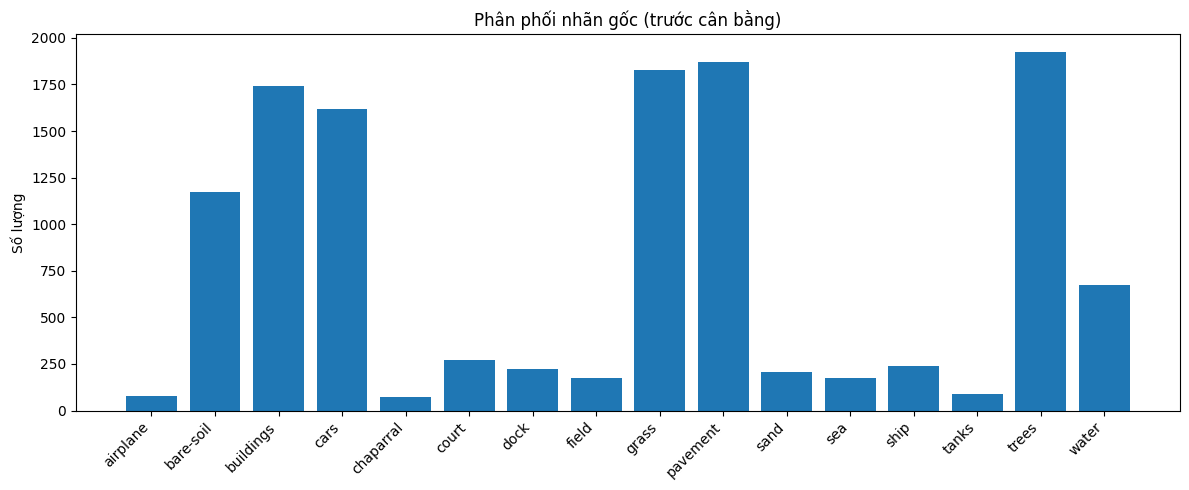

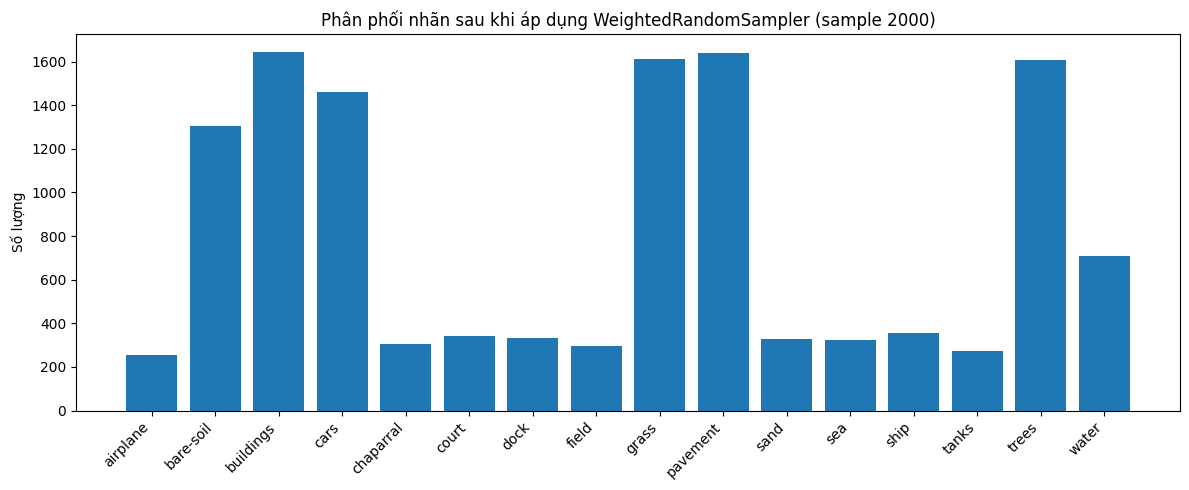

Train 2160, Val 240, Test 600


Epoch 1/50 - train:   0%|          | 0/135 [00:00<?, ?it/s]


Epoch 2/50 | Train Loss: 0.116605 Val Loss: 0.105306 | F1-micro: 0.7515 F1-macro: 0.6211 mAP: 0.8273
Unfreezing last backbone block at epoch 3


Epoch 3/50 - train:   0%|          | 0/135 [00:00<?, ?it/s]


Epoch 3/50 | Train Loss: 0.106221 Val Loss: 0.100991 | F1-micro: 0.7824 F1-macro: 0.6584 mAP: 0.8335


...


Epoch 17/50 | Train Loss: 0.027152 Val Loss: 0.083256 | F1-micro: 0.8596 F1-macro: 0.7595 mAP: 0.8913


Epoch 18/50 - train:   0%|          | 0/135 [00:00<?, ?it/s]


Epoch 18/50 | Train Loss: 0.025451 Val Loss: 0.085275 | F1-micro: 0.8565 F1-macro: 0.7643 mAP: 0.8921


Epoch 19/50 - train:   0%|          | 0/135 [00:00<?, ?it/s]


Epoch 20/50 | Train Loss: 0.021911 Val Loss: 0.083805 | F1-micro: 0.8676 F1-macro: 0.7911 mAP: 0.9053
Early stopping


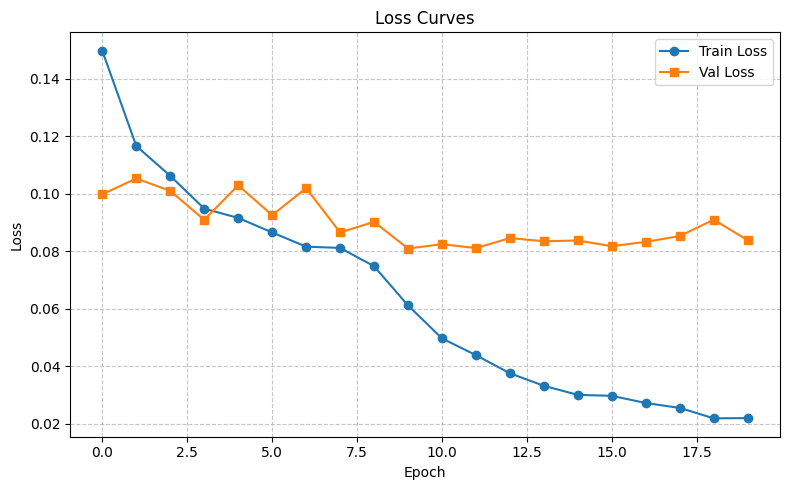

In [12]:
# ============================
# Full training script with ASL, progressive unfreezing, per-class thresholds, tqdm, weighted sampling
# Thêm in ra phân phối nhãn gốc, phân phối sau cân bằng, và loss curve
# ============================

import os, gc, time, copy, glob, logging, warnings
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import resnet50
from PIL import Image
from sklearn.metrics import f1_score, average_precision_score

from torch.cuda.amp import autocast, GradScaler

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# ----- Config -----
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DATA_PATH = '/kaggle/input/aid-multilabel/AID_multilabel/'  
CSV_PATH = os.path.join(DATA_PATH, 'multilabel.csv')
TRAIN_IMG_DIR = os.path.join(DATA_PATH, 'images/images_tr')
TEST_IMG_DIR = os.path.join(DATA_PATH, 'images/images_test')

L = 16  # số label hiện tại (đã loại mobile-home)
K = 512
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 50
LR = 1e-4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True

UNFREEZE_LAST_AT = 3
UNFREEZE_ALL_AT = 10

USE_LOSS = 'asl'   
CLIP = 0.05        
GAMMA_POS = 0.0
GAMMA_NEG = 4.0

SCHEDULER = 'cosine'
DEBUG = False

print("Config ready. Device:", DEVICE)

# ----- Transforms -----
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
transform_val = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ----- Dataset -----
class MultilabelDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None, drop_label='mobile-home'):
        self.labels_df = pd.read_csv(csv_file)
        first_col = self.labels_df.columns[0]
        self.labels_df = self.labels_df.rename(columns={first_col: 'image_name'})
        self.img_dir = img_dir
        self.transform = transform

        label_cols = self.labels_df.columns[1:].tolist()
        if drop_label in label_cols:
            label_cols.remove(drop_label)
        self.label_columns = label_cols
        assert len(self.label_columns) == L

        available_files = set()
        for pattern in ['**/*.tif','**/*.jpg','**/*.png']:
            for f in glob.glob(os.path.join(img_dir, pattern), recursive=True):
                base = os.path.basename(f).rsplit('.',1)[0].lower()
                available_files.add(base)

        self.labels_df['image_name_lower'] = self.labels_df['image_name'].str.lower()
        self.labels_df = self.labels_df[self.labels_df['image_name_lower'].isin(available_files)].reset_index(drop=True)
        self.labels_df = self.labels_df.drop(columns=['image_name_lower'])

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        img_basename = row['image_name']
        base_lower = str(img_basename).lower()
        found = None
        for ext in ['tif','jpg','png']:
            candidates = glob.glob(os.path.join(self.img_dir, f'**/{base_lower}.{ext}'), recursive=True)
            if candidates:
                found = candidates[0]
                break
        img = Image.open(found).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        labels = torch.tensor(row[self.label_columns].values.astype(np.float32))
        return img, labels, img_basename

# ----- Weighted sampler -----
def build_weighted_sampler(dataset):
    labels_all = []
    for _, labels, _ in dataset:
        labels_all.append(labels.numpy())
    labels_all = np.vstack(labels_all)
    pos_counts = labels_all.sum(axis=0)
    pos_counts = np.maximum(pos_counts, 1.0)
    class_weights = 1.0 / pos_counts
    sample_weights = (labels_all * class_weights).max(axis=1)
    sample_weights = np.where(sample_weights == 0, class_weights.mean(), sample_weights)
    sample_weights = torch.tensor(sample_weights, dtype=torch.double)
    return WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ----- ASL -----
class AsymmetricLossMultiLabel(nn.Module):
    def __init__(self, gamma_pos=0.0, gamma_neg=4.0, clip=0.05):
        super().__init__()
        self.gamma_pos = gamma_pos
        self.gamma_neg = gamma_neg
        self.clip = clip

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = probs * targets + (1 - probs) * (1 - targets)
        gamma = self.gamma_pos * targets + self.gamma_neg * (1 - targets)
        focal_factor = (1 - pt) ** gamma
        if self.clip is not None and self.clip > 0:
            neg_probs = (1 - probs)
            clipped_neg_probs = (neg_probs + self.clip).clamp(max=1)
            pt_neg = probs * targets + clipped_neg_probs * (1 - targets)
            focal_factor = (1 - pt_neg) ** gamma
        return (focal_factor * loss).mean()

# ----- Model -----
class SpatialTransformer(nn.Module):
    def __init__(self, L, K, output_size):
        super().__init__()
        self.L = L
        self.K = K
        theta_init = torch.zeros(L, 2, 3)
        theta_init[:,0,0] = 1.0
        theta_init[:,1,1] = 1.0
        self.theta = nn.Parameter(theta_init)

    def forward(self, x):
        B = x.shape[0]
        out = []
        grids = []
        for l in range(self.L):
            theta_l = self.theta[l].unsqueeze(0).repeat(B,1,1).to(x.device)
            grid = F.affine_grid(theta_l, torch.Size([B, x.shape[2], x.shape[3], x.shape[4]]), align_corners=False)
            x_slice = x[:, l]
            attn_x = F.grid_sample(x_slice, grid, mode='bilinear', align_corners=False, padding_mode='zeros')
            out.append(attn_x)
            grids.append(grid)
        attn = torch.stack(out, dim=1)
        return attn, grids

class AttentionALRNCNN(nn.Module):
    def __init__(self, num_classes=L, feature_size=7):
        super().__init__()
        resnet = resnet50(pretrained=True)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.feature_channels = 2048
        self.num_classes = num_classes
        self.K = K
        self.label_wise_conv = nn.Conv2d(self.feature_channels, K * num_classes, kernel_size=1)
        self.stn = SpatialTransformer(num_classes, K, feature_size)
        self.pairwise_conv = nn.Conv2d(2 * K, K, kernel_size=1)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.mlp = nn.Sequential(nn.Linear(K, 512), nn.ReLU(), nn.Linear(512, 1))

    def forward(self, x):
        B = x.shape[0]
        features = self.backbone(x)
        lf = self.label_wise_conv(features)
        lf = lf.view(B, self.num_classes, self.K, lf.shape[2], lf.shape[3])
        attn, grids = self.stn(lf)
        logits = []
        for l in range(self.num_classes):
            A_l = attn[:, l]
            rels = []
            for m in range(self.num_classes):
                if m == l: continue
                A_m = attn[:, m]
                concat = torch.cat([A_l, A_m], dim=1)
                pairwise = self.pairwise_conv(concat)
                pooled = self.gap(pairwise).view(B, -1)
                out = self.mlp(pooled)
                rels.append(out)
            sum_rels = torch.sum(torch.stack(rels, dim=0), dim=0).squeeze(-1) if len(rels)>0 else torch.zeros(B, device=A_l.device)
            logits.append(sum_rels)
        return torch.stack(logits, dim=1), attn, grids

# ----- Prepare data -----
print("Preparing datasets...")
full_train_dataset = MultilabelDataset(CSV_PATH, TRAIN_IMG_DIR, transform=transform_train)
val_size = max(1, int(0.1 * len(full_train_dataset)))
train_size = len(full_train_dataset) - val_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size],
                                         generator=torch.Generator().manual_seed(SEED))
test_dataset = MultilabelDataset(CSV_PATH, TEST_IMG_DIR, transform=transform_val)

# Phân phối nhãn gốc
all_labels = []
for _, lab, _ in full_train_dataset:
    all_labels.append(lab.numpy())
all_labels = np.vstack(all_labels)
label_counts = all_labels.sum(axis=0)
plt.figure(figsize=(12,5))
plt.bar(full_train_dataset.label_columns, label_counts)
plt.xticks(rotation=45, ha="right")
plt.title("Phân phối nhãn gốc (trước cân bằng)")
plt.ylabel("Số lượng")
plt.tight_layout()
plt.show()

# Weighted sampler
sampler = build_weighted_sampler(train_dataset)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

# Phân phối sau sampler
sampled_labels = []
for i, (img, lab, name) in zip(range(2000), iter(train_loader)):
    sampled_labels.append(lab.numpy())
sampled_labels = np.vstack(sampled_labels)
sampled_counts = sampled_labels.sum(axis=0)
plt.figure(figsize=(12,5))
plt.bar(full_train_dataset.label_columns, sampled_counts)
plt.xticks(rotation=45, ha="right")
plt.title("Phân phối nhãn sau khi áp dụng WeightedRandomSampler (sample 2000)")
plt.ylabel("Số lượng")
plt.tight_layout()
plt.show()

print(f"Train {len(train_dataset)}, Val {len(val_dataset)}, Test {len(test_dataset)}")

# ----- Train -----
model = AttentionALRNCNN(num_classes=L, feature_size=7).to(DEVICE)
for p in model.backbone.parameters():
    p.requires_grad = False
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler = GradScaler()
criterion = AsymmetricLossMultiLabel(gamma_pos=GAMMA_POS, gamma_neg=GAMMA_NEG, clip=CLIP).to(DEVICE)

best_val_loss = float('inf')
epochs_no_improve = 0
PATIENCE = 10
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    epoch_start = time.time()
    if epoch + 1 == UNFREEZE_LAST_AT:
        print(f"Unfreezing last backbone block at epoch {epoch+1}")
        for name, module in model.backbone.named_children():
            if name == 'layer4':
                for p in module.parameters():
                    p.requires_grad = True
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=1e-5)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
    if epoch + 1 == UNFREEZE_ALL_AT:
        print(f"Unfreezing entire backbone at epoch {epoch+1}")
        for p in model.backbone.parameters():
            p.requires_grad = True
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR/5.0, weight_decay=1e-5)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

    model.train()
    running_loss = 0.0
    loop = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{EPOCHS} - train", leave=False)
    for _, (images, labels, _) in loop:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with autocast():
            outputs, _, _ = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(filter(lambda p: p.requires_grad, model.parameters()), max_norm=2.0)
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * images.size(0)
    epoch_train_loss = running_loss / len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss_total, all_probs, all_labels = 0.0, [], []
    with torch.no_grad():
        for images, labels, _ in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            with autocast():
                outputs, _, _ = model(images)
                loss = criterion(outputs, labels)
            val_loss_total += loss.item() * images.size(0)
            probs = torch.sigmoid(outputs).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.cpu().numpy())
    epoch_val_loss = val_loss_total / len(val_loader.dataset)

    # Metrics
    all_probs = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)
    preds = (all_probs >= 0.5).astype(int)
    f1_micro = f1_score(all_labels, preds, average='micro')
    f1_macro = f1_score(all_labels, preds, average='macro')
    mAP = average_precision_score(all_labels, all_probs, average='macro')

    scheduler.step()
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    print(f"\nEpoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_train_loss:.6f} Val Loss: {epoch_val_loss:.6f} "
          f"| F1-micro: {f1_micro:.4f} F1-macro: {f1_macro:.4f} mAP: {mAP:.4f}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        torch.save({'epoch': epoch+1, 'model_state': model.state_dict()}, '/kaggle/working/best_model.pth')
        print("Saved best model.")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print("Early stopping")
            break

# Loss curve
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='s')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)
plt.title("Loss Curves")
plt.tight_layout()
plt.show()


In [3]:
import torch
import numpy as np

# ----- Load model -----
# model = AttentionALRNCNN(num_classes=L).to(DEVICE)
# model.load_state_dict(torch.load("/kaggle/working/model.pth", map_location=DEVICE))
# model.eval()

# ----- Load thresholds -----
# best_thresholds = np.load("/kaggle/working/best_thresholds.npy")

# ----- Evaluate on test set -----
from sklearn.metrics import classification_report

all_labels, all_outputs = [], []
with torch.no_grad():
    for images, labels, _ in test_loader:
        images = images.to(DEVICE)
        outputs, _, _ = model(images)
        outputs = torch.sigmoid(outputs).cpu().numpy()
        all_outputs.append(outputs)
        all_labels.append(labels.numpy())

all_outputs = np.vstack(all_outputs)
all_labels = np.vstack(all_labels)

# Áp dụng threshold theo từng class
preds = (all_outputs >= thresholds).astype(int)

# Đánh giá kết quả
f1_micro = f1_score(all_labels, preds, average="micro", zero_division=0)
f1_macro = f1_score(all_labels, preds, average="macro", zero_division=0)
mAP = average_precision_score(all_labels, all_outputs, average="macro")

print("=== Test Results ===")
print(f"F1-micro: {f1_micro:.4f}")
print(f"F1-macro: {f1_macro:.4f}")
print(f"mAP: {mAP:.4f}")

# Chi tiết từng class
print("\n--- Classification Report ---")
print(classification_report(all_labels, preds, target_names=full_train_dataset.label_columns, zero_division=0))


=== Test Results ===
F1-micro: 0.8765
F1-macro: 0.7919
mAP: 0.8119

--- Classification Report ---
              precision    recall  f1-score   support

    airplane       0.76      0.65      0.70        20
   bare-soil       0.68      0.88      0.77       304
   buildings       0.91      0.97      0.94       417
        cars       0.89      0.96      0.92       409
       court       0.53      0.56      0.54        75
        dock       0.67      0.66      0.67        50
       field       0.79      0.49      0.60        39
       grass       0.90      0.98      0.94       466
    pavement       0.92      0.99      0.95       458
        sand       0.88      0.81      0.84        52
        ship       0.65      0.77      0.71        47
       tanks       1.00      0.90      0.95        21
       trees       0.89      0.97      0.93       483
       water       0.62      0.63      0.63       178

   micro avg       0.84      0.91      0.88      3019
   macro avg       0.79      0.80   

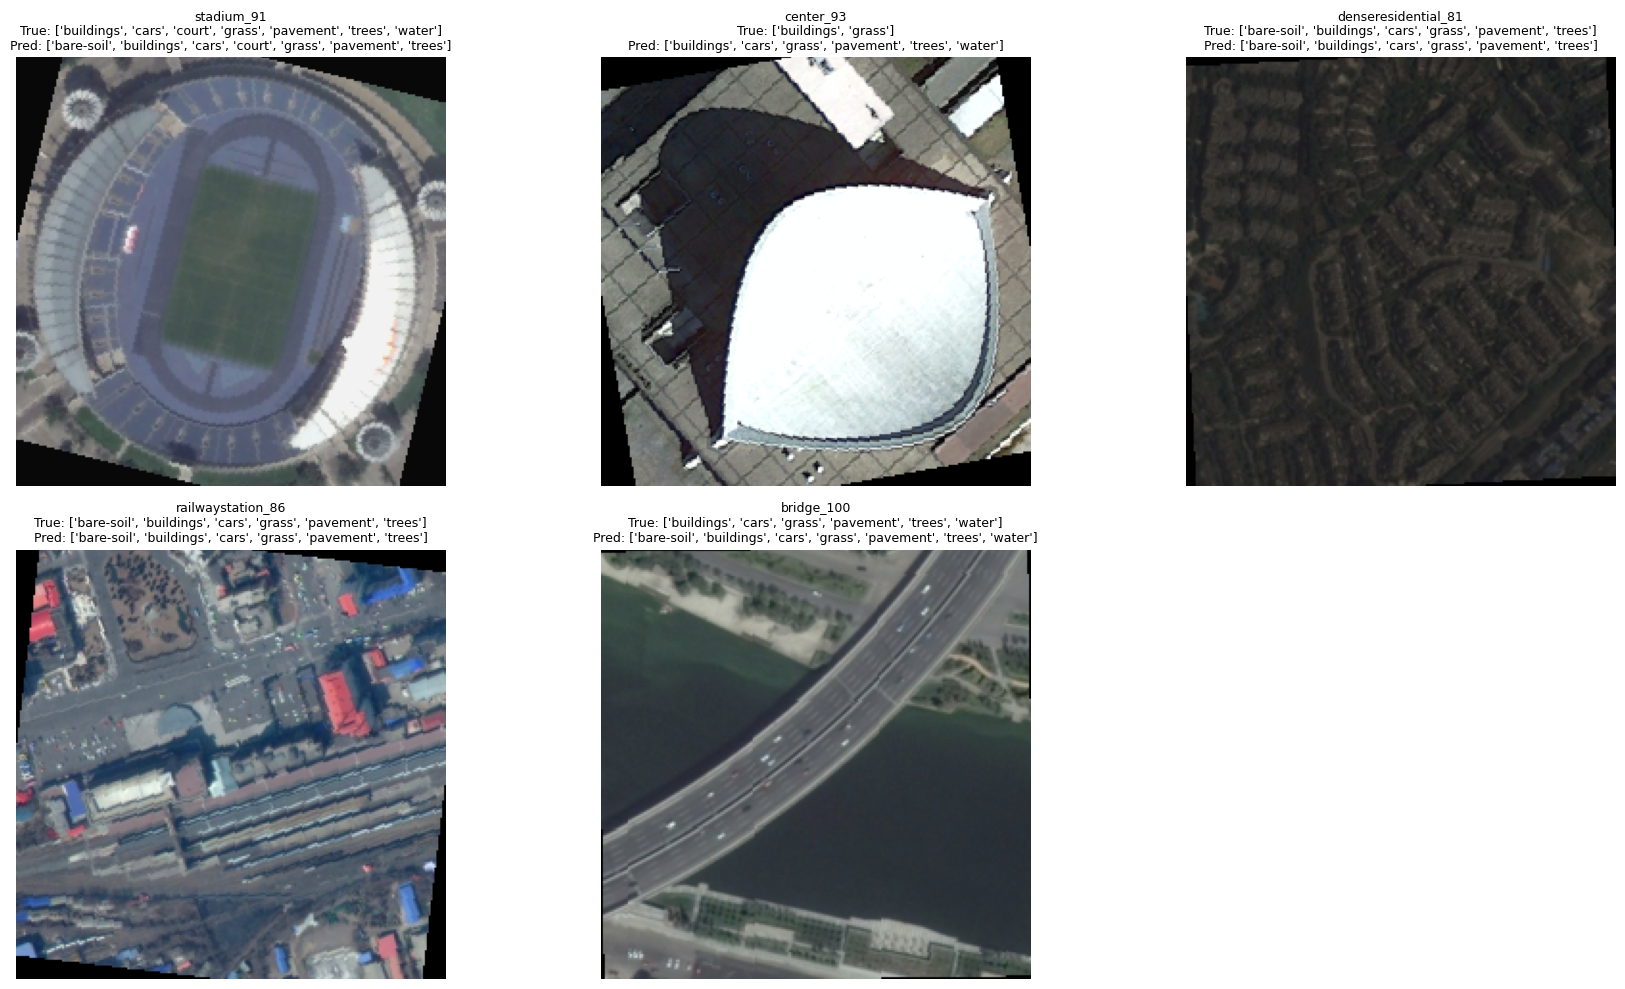

In [6]:
import random
import matplotlib.pyplot as plt
import numpy as np
import torch

# # Load lại model đã train
# model = AttentionALRNCNN(num_classes=L).to(DEVICE)
# model.load_state_dict(torch.load("/kaggle/working/model.pth", map_location=DEVICE))
# model.eval()

# # Load thresholds (nếu có)
# thresholds = np.load("/kaggle/working/best_thresholds.npy")

# Chọn 5 ảnh ngẫu nhiên từ test set
indices = random.sample(range(len(test_dataset)), 5)

plt.figure(figsize=(18, 10))

for i, idx in enumerate(indices):
    image, true_labels, img_name = test_dataset[idx]
    image_input = image.unsqueeze(0).to(DEVICE)

    # Dự đoán
    with torch.no_grad():
        outputs, _, _ = model(image_input)
        probs = torch.sigmoid(outputs).cpu().numpy()[0]
        preds = (probs >= thresholds).astype(int)

    # Giải mã nhãn
    true_label_names = [label for j, label in enumerate(test_dataset.label_columns) if true_labels[j] == 1]
    pred_label_names = [label for j, label in enumerate(test_dataset.label_columns) if preds[j] == 1]

    # Hiển thị ảnh
    img_show = image.permute(1, 2, 0).cpu().numpy()
    img_show = np.clip(img_show * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)

    ax = plt.subplot(2, 3, i+1)
    ax.imshow(img_show)
    ax.axis("off")
    ax.set_title(f"{img_name}\nTrue: {true_label_names}\nPred: {pred_label_names}", fontsize=9)

plt.tight_layout()
plt.show()


Config ready. Device: cuda
Preparing datasets...


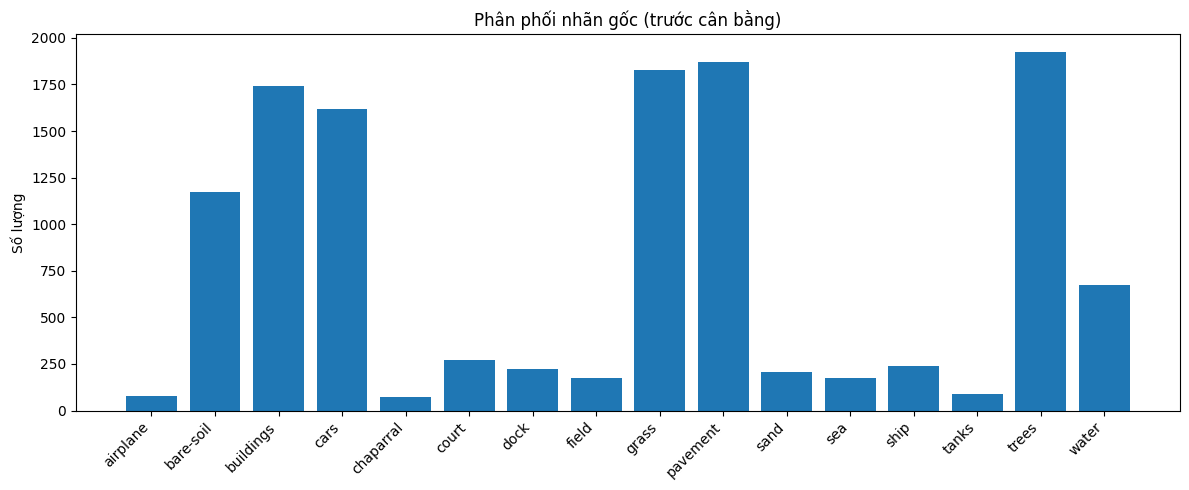

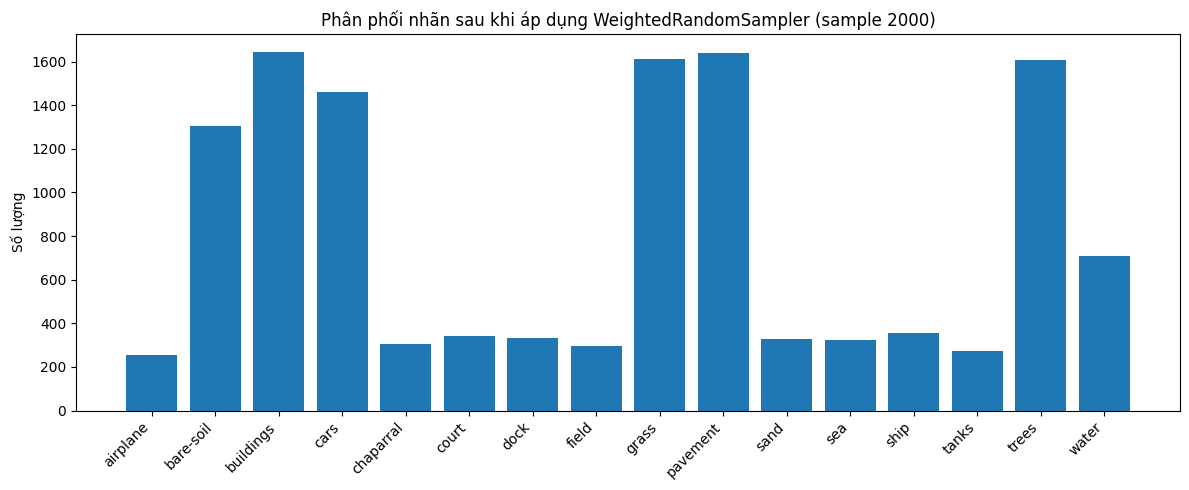

Train 2160, Val 240, Test 600


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 202MB/s]


Epoch 1/50 - train:   0%|          | 0/135 [00:00<?, ?it/s]


Epoch 1/50 | Train Loss: 0.149768 Val Loss: 0.099804 | F1-micro: 0.7237 F1-macro: 0.5796 mAP: 0.7730
Saved best model.


Epoch 2/50 - train:   0%|          | 0/135 [00:00<?, ?it/s]

...


Epoch 19/50 | Train Loss: 0.021647 Val Loss: 0.091008 | F1-micro: 0.8746 F1-macro: 0.7822 mAP: 0.8941


Epoch 20/50 - train:   0%|          | 0/135 [00:00<?, ?it/s]


Epoch 20/50 | Train Loss: 0.021817 Val Loss: 0.081635 | F1-micro: 0.8692 F1-macro: 0.7864 mAP: 0.9030


Epoch 21/50 - train:   0%|          | 0/135 [00:00<?, ?it/s]


Epoch 21/50 | Train Loss: 0.020015 Val Loss: 0.086578 | F1-micro: 0.8703 F1-macro: 0.7847 mAP: 0.8956
Early stopping


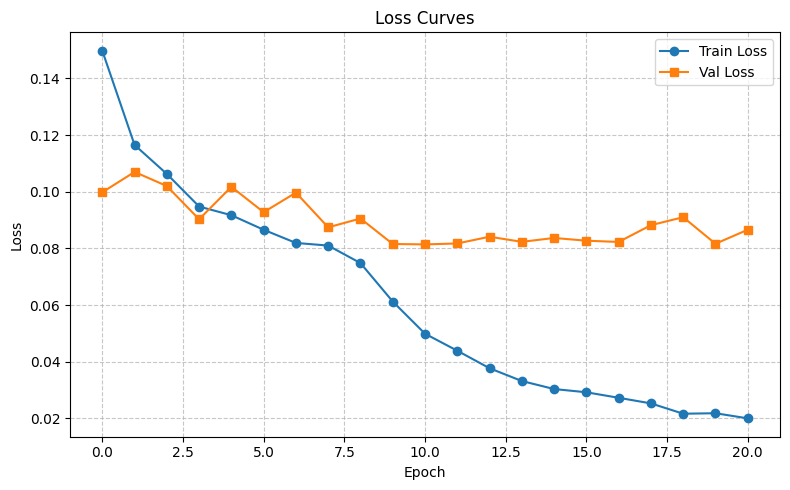

In [1]:
# ============================
# Full training script with ASL, progressive unfreezing, per-class thresholds, tqdm, weighted sampling
# Thêm in ra phân phối nhãn gốc, phân phối sau cân bằng, và loss curve
# ============================
import os, gc, time, copy, glob, logging, warnings
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import resnet50
from PIL import Image
from sklearn.metrics import f1_score, average_precision_score
from torch.cuda.amp import autocast, GradScaler
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# ----- Config -----
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DATA_PATH = '/kaggle/input/aid-multilabel/AID_multilabel/'
CSV_PATH = os.path.join(DATA_PATH, 'multilabel.csv')
TRAIN_IMG_DIR = os.path.join(DATA_PATH, 'images/images_tr')
TEST_IMG_DIR = os.path.join(DATA_PATH, 'images/images_test')
L = 16 # số label hiện tại (đã loại mobile-home)
K = 512
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 50
LR = 1e-4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True
UNFREEZE_LAST_AT = 3
UNFREEZE_ALL_AT = 10
USE_LOSS = 'asl'
CLIP = 0.05
GAMMA_POS = 0.0
GAMMA_NEG = 4.0
SCHEDULER = 'cosine'
DEBUG = False
print("Config ready. Device:", DEVICE)

# ----- Transforms -----
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
transform_val = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ----- Dataset -----
class MultilabelDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None, drop_label='mobile-home'):
        self.labels_df = pd.read_csv(csv_file)
        first_col = self.labels_df.columns[0]
        self.labels_df = self.labels_df.rename(columns={first_col: 'image_name'})
        self.img_dir = img_dir
        self.transform = transform
        label_cols = self.labels_df.columns[1:].tolist()
        if drop_label in label_cols:
            label_cols.remove(drop_label)
        self.label_columns = label_cols
        assert len(self.label_columns) == L
        available_files = set()
        for pattern in ['**/*.tif', '**/*.jpg', '**/*.png']:
            for f in glob.glob(os.path.join(img_dir, pattern), recursive=True):
                base = os.path.basename(f).rsplit('.',1)[0].lower()
                available_files.add(base)
        self.labels_df['image_name_lower'] = self.labels_df['image_name'].str.lower()
        self.labels_df = self.labels_df[self.labels_df['image_name_lower'].isin(available_files)].reset_index(drop=True)
        self.labels_df = self.labels_df.drop(columns=['image_name_lower'])

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        img_basename = row['image_name']
        base_lower = str(img_basename).lower()
        found = None
        for ext in ['tif','jpg','png']:
            candidates = glob.glob(os.path.join(self.img_dir, f'**/{base_lower}.{ext}'), recursive=True)
            if candidates:
                found = candidates[0]
                break
        img = Image.open(found).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        labels = torch.tensor(row[self.label_columns].values.astype(np.float32))
        return img, labels, img_basename

# ----- Weighted sampler -----
def build_weighted_sampler(dataset):
    labels_all = []
    for _, labels, _ in dataset:
        labels_all.append(labels.numpy())
    labels_all = np.vstack(labels_all)
    pos_counts = labels_all.sum(axis=0)
    pos_counts = np.maximum(pos_counts, 1.0)
    class_weights = 1.0 / pos_counts
    sample_weights = (labels_all * class_weights).max(axis=1)
    sample_weights = np.where(sample_weights == 0, class_weights.mean(), sample_weights)
    sample_weights = torch.tensor(sample_weights, dtype=torch.double)
    return WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ----- ASL -----
class AsymmetricLossMultiLabel(nn.Module):
    def __init__(self, gamma_pos=0.0, gamma_neg=4.0, clip=0.05):
        super().__init__()
        self.gamma_pos = gamma_pos
        self.gamma_neg = gamma_neg
        self.clip = clip

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = probs * targets + (1 - probs) * (1 - targets)
        gamma = self.gamma_pos * targets + self.gamma_neg * (1 - targets)
        focal_factor = (1 - pt) ** gamma
        if self.clip is not None and self.clip > 0:
            neg_probs = (1 - probs)
            clipped_neg_probs = (neg_probs + self.clip).clamp(max=1)
            pt_neg = probs * targets + clipped_neg_probs * (1 - targets)
            focal_factor = (1 - pt_neg) ** gamma
        return (focal_factor * loss).mean()

# ----- Model -----
class SpatialTransformer(nn.Module):
    def __init__(self, L, K, output_size):
        super().__init__()
        self.L = L
        self.K = K
        theta_init = torch.zeros(L, 2, 3)
        theta_init[:,0,0] = 1.0
        theta_init[:,1,1] = 1.0
        self.theta = nn.Parameter(theta_init)

    def forward(self, x):
        B = x.shape[0]
        out = []
        grids = []
        for l in range(self.L):
            theta_l = self.theta[l].unsqueeze(0).repeat(B,1,1).to(x.device)
            grid = F.affine_grid(theta_l, torch.Size([B, x.shape[2], x.shape[3], x.shape[4]]), align_corners=False)
            x_slice = x[:, l]
            attn_x = F.grid_sample(x_slice, grid, mode='bilinear', align_corners=False, padding_mode='zeros')
            out.append(attn_x)
            grids.append(grid)
        attn = torch.stack(out, dim=1)
        return attn, grids

class AttentionALRNCNN(nn.Module):
    def __init__(self, num_classes=L, feature_size=7):
        super().__init__()
        resnet = resnet50(pretrained=True)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.feature_channels = 2048
        self.num_classes = num_classes
        self.K = K
        self.label_wise_conv = nn.Conv2d(self.feature_channels, K * num_classes, kernel_size=1)
        self.stn = SpatialTransformer(num_classes, K, feature_size)
        self.pairwise_conv = nn.Conv2d(2 * K, K, kernel_size=1)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.mlp = nn.Sequential(nn.Linear(K, 512), nn.ReLU(), nn.Linear(512, 1))

    def forward(self, x):
        B = x.shape[0]
        features = self.backbone(x)
        lf = self.label_wise_conv(features)
        lf = lf.view(B, self.num_classes, self.K, lf.shape[2], lf.shape[3])
        attn, grids = self.stn(lf)
        logits = []
        for l in range(self.num_classes):
            A_l = attn[:, l]
            rels = []
            for m in range(self.num_classes):
                if m == l: continue
                A_m = attn[:, m]
                concat = torch.cat([A_l, A_m], dim=1)
                pairwise = self.pairwise_conv(concat)
                pooled = self.gap(pairwise).view(B, -1)
                out = self.mlp(pooled)
                rels.append(out)
            sum_rels = torch.sum(torch.stack(rels, dim=0), dim=0).squeeze(-1) if len(rels)>0 else torch.zeros(B, device=A_l.device)
            logits.append(sum_rels)
        return torch.stack(logits, dim=1), attn, grids

# ----- Prepare data -----
print("Preparing datasets...")
full_train_dataset = MultilabelDataset(CSV_PATH, TRAIN_IMG_DIR, transform=transform_train)
val_size = max(1, int(0.1 * len(full_train_dataset)))
train_size = len(full_train_dataset) - val_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size],
                                         generator=torch.Generator().manual_seed(SEED))
test_dataset = MultilabelDataset(CSV_PATH, TEST_IMG_DIR, transform=transform_val)

# Phân phối nhãn gốc
all_labels = []
for _, lab, _ in full_train_dataset:
    all_labels.append(lab.numpy())
all_labels = np.vstack(all_labels)
label_counts = all_labels.sum(axis=0)
plt.figure(figsize=(12,5))
plt.bar(full_train_dataset.label_columns, label_counts)
plt.xticks(rotation=45, ha="right")
plt.title("Phân phối nhãn gốc (trước cân bằng)")
plt.ylabel("Số lượng")
plt.tight_layout()
plt.show()

# Weighted sampler
sampler = build_weighted_sampler(train_dataset)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

# Phân phối sau sampler
sampled_labels = []
for i, (img, lab, name) in zip(range(2000), iter(train_loader)):
    sampled_labels.append(lab.numpy())
sampled_labels = np.vstack(sampled_labels)
sampled_counts = sampled_labels.sum(axis=0)
plt.figure(figsize=(12,5))
plt.bar(full_train_dataset.label_columns, sampled_counts)
plt.xticks(rotation=45, ha="right")
plt.title("Phân phối nhãn sau khi áp dụng WeightedRandomSampler (sample 2000)")
plt.ylabel("Số lượng")
plt.tight_layout()
plt.show()
print(f"Train {len(train_dataset)}, Val {len(val_dataset)}, Test {len(test_dataset)}")

# ----- Train -----
model = AttentionALRNCNN(num_classes=L, feature_size=7).to(DEVICE)
for p in model.backbone.parameters():
    p.requires_grad = False
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler = GradScaler()
criterion = AsymmetricLossMultiLabel(gamma_pos=GAMMA_POS, gamma_neg=GAMMA_NEG, clip=CLIP).to(DEVICE)
best_val_loss = float('inf')
epochs_no_improve = 0
PATIENCE = 10
train_losses, val_losses = [], []
for epoch in range(EPOCHS):
    epoch_start = time.time()
    if epoch + 1 == UNFREEZE_LAST_AT:
        print(f"Unfreezing last backbone block at epoch {epoch+1}")
        for name, module in model.backbone.named_children():
            if name == 'layer4':
                for p in module.parameters():
                    p.requires_grad = True
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=1e-5)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
    if epoch + 1 == UNFREEZE_ALL_AT:
        print(f"Unfreezing entire backbone at epoch {epoch+1}")
        for p in model.backbone.parameters():
            p.requires_grad = True
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR/5.0, weight_decay=1e-5)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

    model.train()
    running_loss = 0.0
    loop = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{EPOCHS} - train", leave=False)
    for _, (images, labels, _) in loop:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with autocast():
            outputs, _, _ = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(filter(lambda p: p.requires_grad, model.parameters()), max_norm=2.0)
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * images.size(0)
    epoch_train_loss = running_loss / len(train_loader.dataset)
    # Validation
    model.eval()
    val_loss_total, all_probs, all_labels = 0.0, [], []
    with torch.no_grad():
        for images, labels, _ in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            with autocast():
                outputs, _, _ = model(images)
                loss = criterion(outputs, labels)
            val_loss_total += loss.item() * images.size(0)
            probs = torch.sigmoid(outputs).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.cpu().numpy())
    epoch_val_loss = val_loss_total / len(val_loader.dataset)
    # Metrics
    all_probs = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)
    preds = (all_probs >= 0.5).astype(int)
    f1_micro = f1_score(all_labels, preds, average='micro')
    f1_macro = f1_score(all_labels, preds, average='macro')
    mAP = average_precision_score(all_labels, all_probs, average='macro')
    scheduler.step()
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    print(f"\nEpoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_train_loss:.6f} Val Loss: {epoch_val_loss:.6f} "
          f"| F1-micro: {f1_micro:.4f} F1-macro: {f1_macro:.4f} mAP: {mAP:.4f}")
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        torch.save({'epoch': epoch+1, 'model_state': model.state_dict()}, '/kaggle/working/best_model.pth')
        print("Saved best model.")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print("Early stopping")
            break
# Loss curve
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.title("Loss Curves")
plt.tight_layout()
plt.show()

In [6]:
from sklearn.metrics import classification_report
import numpy as np
import torch

def evaluate_metrics(model, loader, label_columns, device='cuda'):
    model.eval()
    all_labels, all_outputs = [], []
    with torch.no_grad():
        for images, labels, _ in loader:
            images = images.to(device)
            labels = labels.cpu().numpy()
            outputs, _, _ = model(images)
            outputs = torch.sigmoid(outputs).cpu().numpy()
            all_labels.append(labels)
            all_outputs.append(outputs)
    all_labels = np.vstack(all_labels)
    all_outputs = np.vstack(all_outputs)
    
    # Tìm ngưỡng tối ưu cho mỗi nhãn
    thresholds = np.zeros(all_outputs.shape[1])
    for i in range(all_outputs.shape[1]):
        best_f1, best_thresh = 0, 0.5
        for thresh in np.linspace(0.2, 0.8, 7):
            preds = (all_outputs[:, i] >= thresh).astype(int)
            f1 = f1_score(all_labels[:, i], preds, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh
        thresholds[i] = best_thresh
    
    # Áp dụng ngưỡng để dự đoán
    preds = np.zeros_like(all_outputs)
    for i in range(all_outputs.shape[1]):
        preds[:, i] = (all_outputs[:, i] >= thresholds[i]).astype(int)
    
    # Tính metrics
    f1_micro = f1_score(all_labels, preds, average='micro')
    f1_macro = f1_score(all_labels, preds, average='macro')
    mAP = average_precision_score(all_labels, all_outputs, average='macro')
    
    # In classification report
    print("\n--- Classification Report ---")
    print(classification_report(all_labels, preds, target_names=label_columns, zero_division=0))
    
    # In F1 per class và ngưỡng
    f1_per_class = f1_score(all_labels, preds, average=None)
    for i, label in enumerate(label_columns):
        print(f"{label}: F1={f1_per_class[i]:.4f}, Threshold={thresholds[i]:.4f}")
    
    return f1_micro, f1_macro, mAP, thresholds

# Ví dụ sử dụng:
f1_micro, f1_macro, mAP, thresholds = evaluate_metrics(model, test_loader, full_train_dataset.label_columns, DEVICE)


--- Classification Report ---
              precision    recall  f1-score   support

    airplane       0.68      0.65      0.67        20
   bare-soil       0.75      0.86      0.80       304
   buildings       0.96      0.96      0.96       417
        cars       0.87      0.98      0.92       409
   chaparral       0.39      0.49      0.43        37
       court       0.41      0.77      0.54        75
        dock       0.88      0.58      0.70        50
       field       0.81      0.64      0.71        39
       grass       0.90      0.97      0.94       466
    pavement       0.97      0.96      0.96       458
        sand       0.96      0.85      0.90        52
         sea       1.00      0.93      0.96        44
        ship       0.69      0.70      0.69        47
       tanks       1.00      0.90      0.95        21
       trees       0.91      0.96      0.94       483
       water       0.86      0.58      0.70       178

   micro avg       0.87      0.90      0.88      

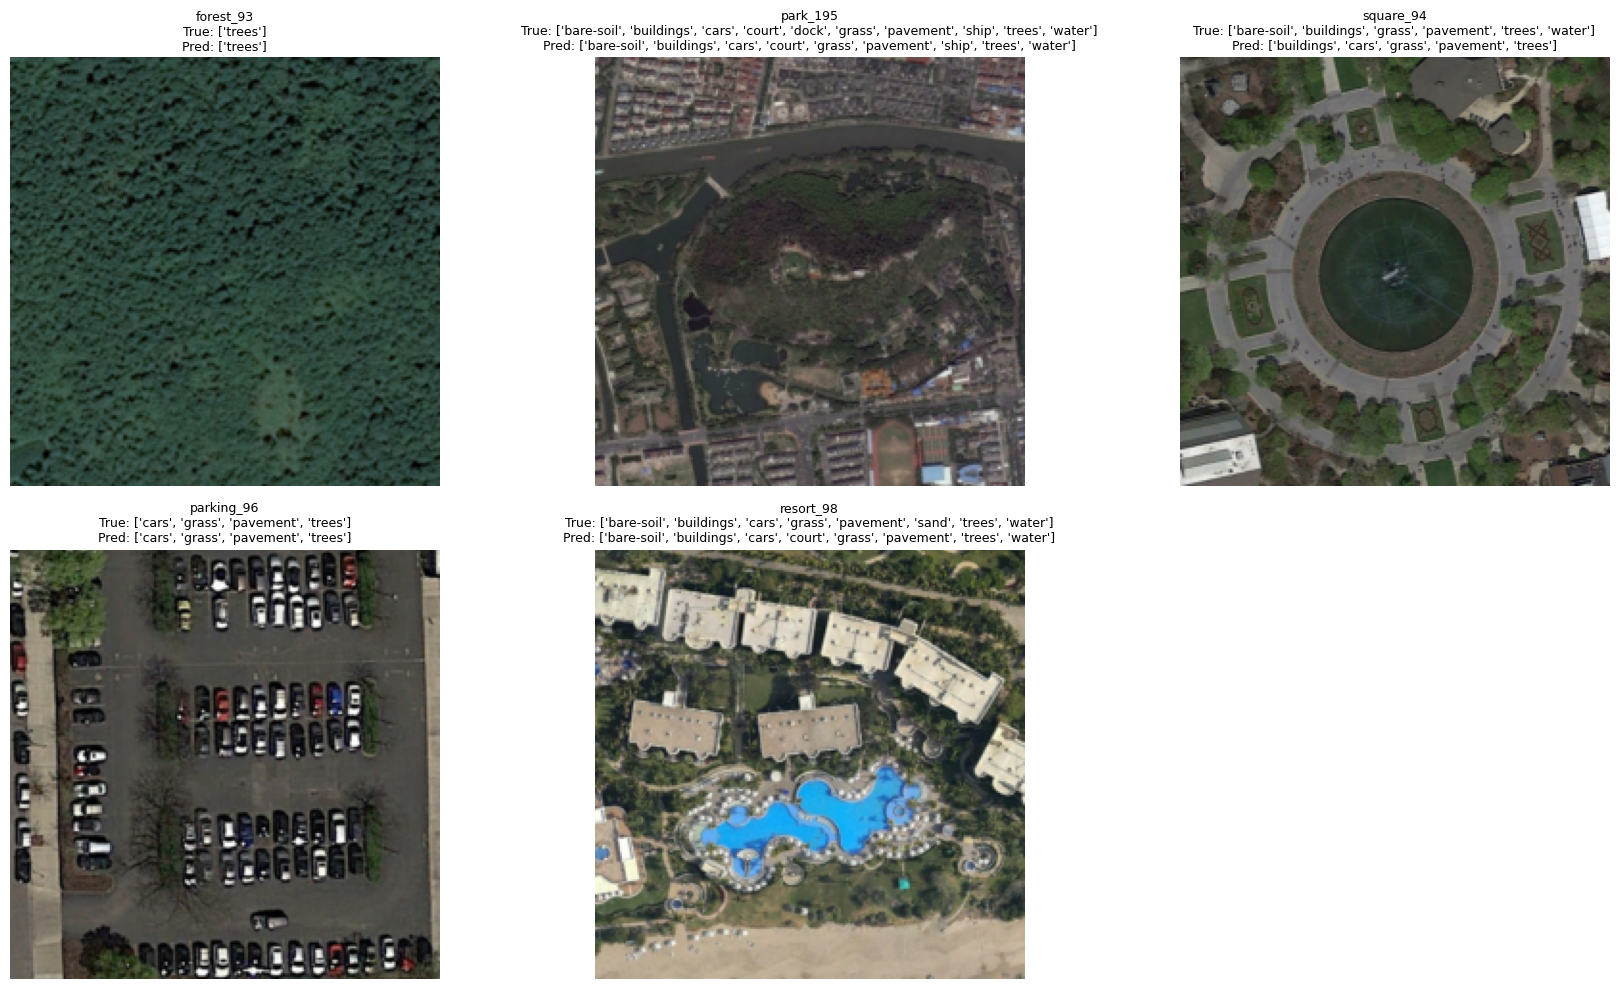

In [7]:
import random
import matplotlib.pyplot as plt
import numpy as np
import torch

# # Load lại model đã train
# model = AttentionALRNCNN(num_classes=L).to(DEVICE)
# model.load_state_dict(torch.load("/kaggle/working/model.pth", map_location=DEVICE))
# model.eval()

# # Load thresholds (nếu có)
# thresholds = np.load("/kaggle/working/best_thresholds.npy")

# Chọn 5 ảnh ngẫu nhiên từ test set
indices = random.sample(range(len(test_dataset)), 5)

plt.figure(figsize=(18, 10))

for i, idx in enumerate(indices):
    image, true_labels, img_name = test_dataset[idx]
    image_input = image.unsqueeze(0).to(DEVICE)

    # Dự đoán
    with torch.no_grad():
        outputs, _, _ = model(image_input)
        probs = torch.sigmoid(outputs).cpu().numpy()[0]
        preds = (probs >= thresholds).astype(int)

    # Giải mã nhãn
    true_label_names = [label for j, label in enumerate(test_dataset.label_columns) if true_labels[j] == 1]
    pred_label_names = [label for j, label in enumerate(test_dataset.label_columns) if preds[j] == 1]

    # Hiển thị ảnh
    img_show = image.permute(1, 2, 0).cpu().numpy()
    img_show = np.clip(img_show * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)

    ax = plt.subplot(2, 3, i+1)
    ax.imshow(img_show)
    ax.axis("off")
    ax.set_title(f"{img_name}\nTrue: {true_label_names}\nPred: {pred_label_names}", fontsize=9)

plt.tight_layout()
plt.show()


Đang xử lý gộp nhãn...
Phân phối nhãn trước xử lý: ['airplane', 'bare-soil', 'buildings', 'cars', 'chaparral', 'court', 'dock', 'field', 'grass', 'mobile-home', 'pavement', 'sand', 'sea', 'ship', 'tanks', 'trees', 'water']
trees          2406
pavement       2328
grass          2295
buildings      2161
cars           2026
bare-soil      1475
water           852
court           344
ship            284
dock            271
sand            259
sea             221
field           214
chaparral       112
tanks           108
airplane         99
mobile-home       2
dtype: int64
Phân phối nhãn sau xử lý: ['airplane', 'buildings', 'cars', 'court', 'dock', 'grass', 'pavement', 'ship', 'tanks', 'trees', 'Water', 'land']
trees        2406
pavement     2328
grass        2295
buildings    2161
cars         2026
land         1752
Water        1050
court         344
ship          284
dock          271
tanks         108
airplane       99
dtype: int64
Gộp nhãn xong, lưu thành: /kaggle/working/multilabel_m

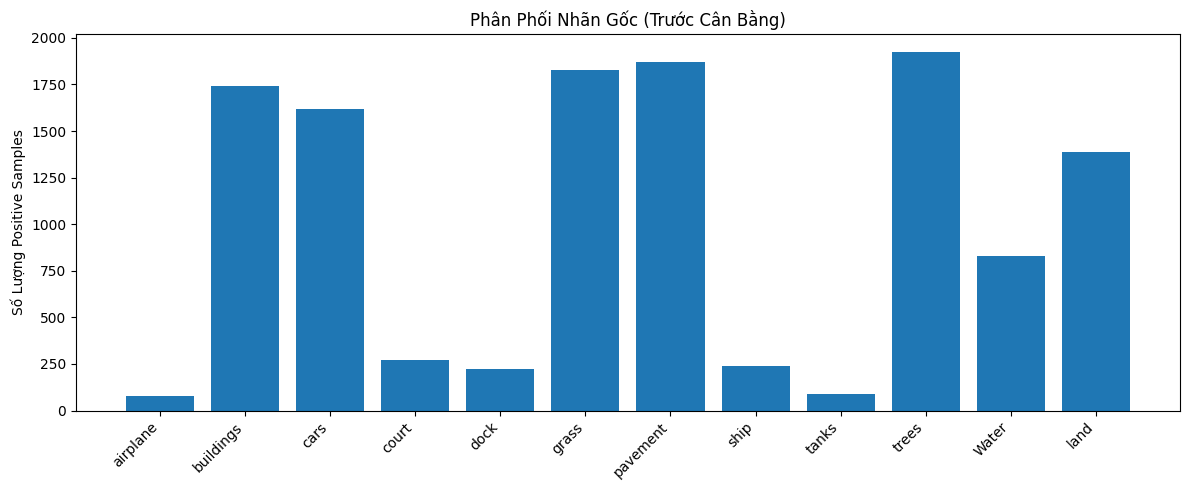

Nhãn hiếm (<350 samples): ['airplane', 'court', 'dock', 'ship', 'tanks']


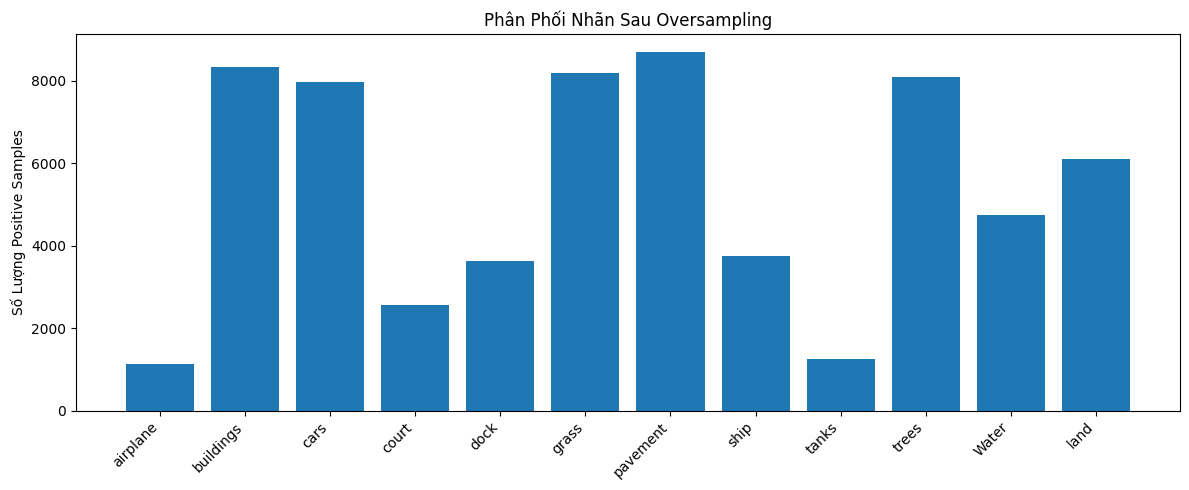

Train 6750, Val 2250, Test 600


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 191MB/s]


Epoch 1/50 - train:   0%|          | 0/422 [00:00<?, ?it/s]


--- Validation Classification Report ---
              precision    recall  f1-score   support

    airplane       0.62      0.73      0.67       282
   buildings       0.95      0.99      0.97      2076
        cars       0.92      0.98      0.95      1993
       court       0.60      0.65      0.63       654
        dock       0.75      0.88      0.81       894
       grass       0.92      1.00      0.96      2037
    pavement       0.99      0.99      0.99      2177
        ship       0.78      0.83      0.81       925
       tanks       0.70      0.67      0.68       305
       trees       0.91      0.99      0.95      2018
       Water       0.82      0.82      0.82      1182
        land       0.73      0.94      0.83      1513

   micro avg       0.86      0.93      0.90     16056
   macro avg       0.81      0.87      0.84     16056
weighted avg       0.87      0.93      0.90     16056
 samples avg       0.86      0.93      0.88     16056

airplane: F1=0.6732, Threshold=0.3500

Epoch 2/50 - train:   0%|          | 0/422 [00:00<?, ?it/s]

...


--- Validation Classification Report ---
              precision    recall  f1-score   support

    airplane       0.99      0.98      0.99       282
   buildings       0.99      0.99      0.99      2076
        cars       0.99      0.99      0.99      1993
       court       0.98      0.96      0.97       654
        dock       0.98      0.98      0.98       894
       grass       0.99      0.99      0.99      2037
    pavement       1.00      1.00      1.00      2177
        ship       0.99      0.98      0.99       925
       tanks       0.99      0.99      0.99       305
       trees       0.99      1.00      0.99      2018
       Water       0.98      0.98      0.98      1182
        land       0.97      0.97      0.97      1513

   micro avg       0.99      0.99      0.99     16056
   macro avg       0.99      0.98      0.99     16056
weighted avg       0.99      0.99      0.99     16056
 samples avg       0.98      0.99      0.98     16056

airplane: F1=0.9875, Threshold=0.5000

Epoch 49/50 - train:   0%|          | 0/422 [00:00<?, ?it/s]


--- Validation Classification Report ---
              precision    recall  f1-score   support

    airplane       0.99      1.00      0.99       282
   buildings       0.99      0.99      0.99      2076
        cars       0.99      0.99      0.99      1993
       court       0.98      0.97      0.98       654
        dock       1.00      0.98      0.99       894
       grass       0.99      0.99      0.99      2037
    pavement       1.00      1.00      1.00      2177
        ship       0.99      0.98      0.98       925
       tanks       1.00      0.99      0.99       305
       trees       0.99      1.00      0.99      2018
       Water       0.98      0.97      0.98      1182
        land       0.96      0.97      0.97      1513

   micro avg       0.99      0.99      0.99     16056
   macro avg       0.99      0.99      0.99     16056
weighted avg       0.99      0.99      0.99     16056
 samples avg       0.98      0.99      0.98     16056

airplane: F1=0.9947, Threshold=0.5000

Epoch 50/50 - train:   0%|          | 0/422 [00:00<?, ?it/s]


--- Validation Classification Report ---
              precision    recall  f1-score   support

    airplane       0.99      1.00      0.99       282
   buildings       0.99      0.99      0.99      2076
        cars       0.99      1.00      0.99      1993
       court       0.99      0.97      0.98       654
        dock       0.99      0.98      0.98       894
       grass       0.99      0.99      0.99      2037
    pavement       1.00      1.00      1.00      2177
        ship       0.99      0.98      0.98       925
       tanks       0.99      0.99      0.99       305
       trees       0.98      1.00      0.99      2018
       Water       0.98      0.98      0.98      1182
        land       0.97      0.96      0.97      1513

   micro avg       0.99      0.99      0.99     16056
   macro avg       0.99      0.99      0.99     16056
weighted avg       0.99      0.99      0.99     16056
 samples avg       0.98      0.99      0.98     16056

airplane: F1=0.9929, Threshold=0.5500

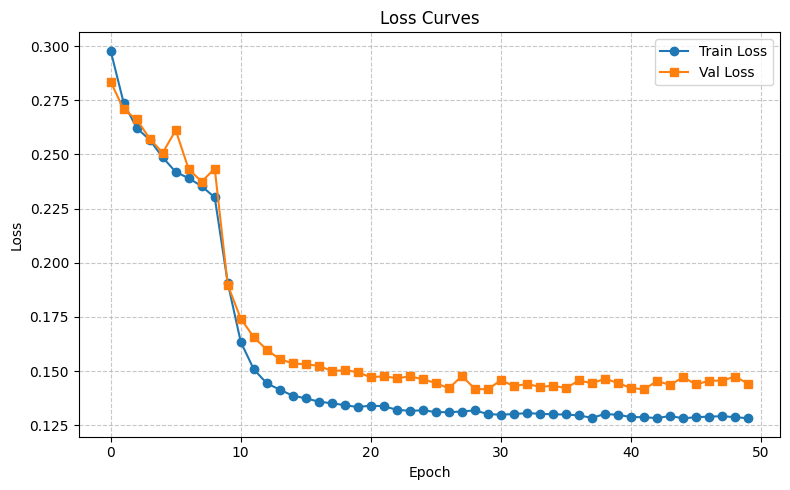

Training finished. Check /kaggle/working for best_model.pth, losses.png, label_distribution_*.png


In [13]:
import os, gc, time, copy, glob, logging, warnings
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler, ConcatDataset
from torchvision import transforms
from torchvision.models import resnet50
from PIL import Image
from sklearn.metrics import f1_score, average_precision_score, classification_report
from torch.cuda.amp import autocast, GradScaler
from torchvision.transforms import ToPILImage

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# ----- Config -----
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DATA_PATH = '/kaggle/input/aid-multilabel/AID_multilabel/'
CSV_PATH = os.path.join(DATA_PATH, 'multilabel.csv')
# ======= GỘP NHÃN TƯƠNG TỰ =======
print("Đang xử lý gộp nhãn...")

# Đọc file gốc
df_labels = pd.read_csv(CSV_PATH)
first_col = df_labels.columns[0]
df_labels = df_labels.rename(columns={first_col: 'image_name'})
print("Phân phối nhãn trước xử lý:",df_labels.columns[1:].tolist())
print(df_labels.drop(columns=['image_name']).sum().sort_values(ascending=False))
# Các nhóm nhãn cần gộp
merge_map = {
    'Water': ['sea', 'water'],
    'land': ['bare-soil', 'sand', 'field']
}

# Loại nhãn trước khi gộp (thêm pavement để đạt L=11)
drop_labels = ['mobile-home', 'chaparral']  # Thêm 'pavement' để giảm từ 12 xuống 11
for drop_label in drop_labels:
    if drop_label in df_labels.columns:
        df_labels = df_labels.drop(columns=[drop_label])

# Thực hiện gộp nhãn
for new_label, old_labels in merge_map.items():
    existing_cols = [col for col in old_labels if col in df_labels.columns]
    if not existing_cols:
        print(f"⚠️ Cảnh báo: Không tìm thấy nhãn nào trong {old_labels} để gộp thành '{new_label}'.")
        continue
    if new_label in df_labels.columns:
        print(f"⚠️ Cảnh báo: Nhãn '{new_label}' đã tồn tại, đổi thành '{new_label}_merged'.")
        new_label = f"{new_label}_merged"
    df_labels[new_label] = df_labels[existing_cols].max(axis=1)

# Loại bỏ các cột cũ đã gộp
cols_to_drop = [c for group in merge_map.values() for c in group if c in df_labels.columns]
df_labels = df_labels.drop(columns=cols_to_drop)

# In phân phối trước/sau gộp để kiểm tra
print("Phân phối nhãn sau xử lý:", df_labels.columns[1:].tolist())
print(df_labels.drop(columns=['image_name']).sum().sort_values(ascending=False))

# Ghi file CSV mới
NEW_CSV_PATH = '/kaggle/working/multilabel_merged.csv'
try:
    df_labels.to_csv(NEW_CSV_PATH, index=False)
    print(f"Gộp nhãn xong, lưu thành: {NEW_CSV_PATH}")
except PermissionError as e:
    print(f"❌ Lỗi ghi file: {e}. Vui lòng kiểm tra quyền truy cập /kaggle/working/.")
except Exception as e:
    print(f"❌ Lỗi không xác định khi ghi file: {e}.")

# Cập nhật đường dẫn CSV dùng cho dataset
CSV_PATH = NEW_CSV_PATH

# Cập nhật L để khớp với số nhãn
L = len(df_labels.columns) - 1  # Cập nhật L dựa trên số cột nhãn thực tế
print(f"Số nhãn sau gộp (L): {L}")

TRAIN_IMG_DIR = os.path.join(DATA_PATH, 'images/images_tr')
TEST_IMG_DIR = os.path.join(DATA_PATH, 'images/images_test')
# L = 12 # loại bỏ mobile-home, chaparral, xử lý water, land 
K = 512
IMG_SIZE = 224
BATCH_SIZE = 16  # Giảm để tránh memory error
EPOCHS = 50
LR = 1e-4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True
UNFREEZE_LAST_AT = 3
UNFREEZE_ALL_AT = 10
USE_LOSS = 'asl'
CLIP = 0.15
GAMMA_POS = 0.0
GAMMA_NEG = 1.0  # Giảm để tăng precision
PATIENCE = 10
MAX_TRAIN_SAMPLES = 9000  # Giảm để tiết kiệm thời gian
DEBUG = False
print("Config ready. Device:", DEVICE)

# ----- Transforms -----
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=5),
    transforms.ToTensor(),
    transforms.GaussianBlur(3, sigma=(0.1, 2.0)),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform_val = transform_test = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ----- Dataset -----
class MultilabelDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None, drop_labels=['mobile-home', 'chaparral']):
        self.labels_df = pd.read_csv(csv_file)
        first_col = self.labels_df.columns[0]
        self.labels_df = self.labels_df.rename(columns={first_col: 'image_name'})
        self.img_dir = img_dir
        self.transform = transform
        label_cols = self.labels_df.columns[1:].tolist()
        for drop_label in drop_labels:
            if drop_label in label_cols:
                label_cols.remove(drop_label)
        self.label_columns = label_cols
        assert len(self.label_columns) == L
        available_files = set()
        for pattern in ['**/*.tif', '**/*.jpg', '**/*.png']:
            for f in glob.glob(os.path.join(img_dir, pattern), recursive=True):
                base = os.path.basename(f).rsplit('.',1)[0].lower()
                available_files.add(base)
        self.labels_df['image_name_lower'] = self.labels_df['image_name'].str.lower()
        self.labels_df = self.labels_df[self.labels_df['image_name_lower'].isin(available_files)].reset_index(drop=True)
        self.labels_df = self.labels_df.drop(columns=['image_name_lower'])

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        img_basename = row['image_name']
        base_lower = str(img_basename).lower()
        found = None
        for ext in ['tif', 'jpg', 'png']:
            candidates = glob.glob(os.path.join(self.img_dir, f'**/{base_lower}.{ext}'), recursive=True)
            if candidates:
                found = candidates[0]
                break
        img = Image.open(found).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        labels = torch.tensor(row[self.label_columns].values.astype(np.float32))
        return img, labels, img_basename

# ----- Weighted Sampler -----
def build_weighted_sampler(dataset):
    labels_all = []
    for _, labels, _ in dataset:
        labels_all.append(labels.numpy())
    labels_all = np.vstack(labels_all)
    pos_counts = labels_all.sum(axis=0)
    pos_counts = np.maximum(pos_counts, 1.0)
    class_weights = 1.0 / pos_counts
    sample_weights = np.mean([labels_all[:, i] * class_weights[i] for i in range(labels_all.shape[1])], axis=0)
    sample_weights = np.where(sample_weights == 0, class_weights.mean(), sample_weights)
    return WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ----- ASL with Label Smoothing -----
class AsymmetricLossMultiLabel(nn.Module):
    def __init__(self, gamma_pos=0.0, gamma_neg=1.0, clip=0.15):
        super().__init__()
        self.gamma_pos = gamma_pos
        self.gamma_neg = gamma_neg
        self.clip = clip

    def forward(self, logits, targets):
        targets_smooth = targets * 0.9 + 0.05
        probs = torch.sigmoid(logits)
        loss = F.binary_cross_entropy_with_logits(logits, targets_smooth, reduction='none')
        pt = probs * targets + (1 - probs) * (1 - targets)
        gamma = self.gamma_pos * targets + self.gamma_neg * (1 - targets)
        focal_factor = (1 - pt) ** gamma
        if self.clip is not None and self.clip > 0:
            neg_probs = (1 - probs)
            clipped_neg_probs = (neg_probs + self.clip).clamp(max=1)
            pt_neg = probs * targets + clipped_neg_probs * (1 - targets)
            focal_factor = (1 - pt_neg) ** gamma
        return (focal_factor * loss).mean()

# ----- Model -----
class SpatialTransformer(nn.Module):
    def __init__(self, L, K, output_size):
        super().__init__()
        self.L = L
        self.K = K
        theta_init = torch.zeros(L, 2, 3)
        theta_init[:,0,0] = 1.0
        theta_init[:,1,1] = 1.0
        self.theta = nn.Parameter(theta_init)

    def forward(self, x):
        B = x.shape[0]
        out = []
        grids = []
        for l in range(self.L):
            theta_l = self.theta[l].unsqueeze(0).repeat(B,1,1).to(x.device)
            grid = F.affine_grid(theta_l, torch.Size([B, x.shape[2], x.shape[3], x.shape[4]]), align_corners=False)
            x_slice = x[:, l]
            attn_x = F.grid_sample(x_slice, grid, mode='bilinear', align_corners=False, padding_mode='zeros')
            out.append(attn_x)
            grids.append(grid)
        attn = torch.stack(out, dim=1)
        return attn, grids

class AttentionALRNCNN(nn.Module):
    def __init__(self, num_classes=L, feature_size=7):
        super().__init__()
        resnet = resnet50(pretrained=True)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.feature_channels = 2048
        self.num_classes = num_classes
        self.K = K
        self.label_wise_conv = nn.Conv2d(self.feature_channels, K * num_classes, kernel_size=1)
        self.stn = SpatialTransformer(num_classes, K, feature_size)
        self.pairwise_conv = nn.Conv2d(2 * K, K, kernel_size=1)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.mlp = nn.Sequential(nn.Linear(K, 512), nn.ReLU(), nn.Dropout(0.7), nn.Linear(512, 1))

    def forward(self, x):
        B = x.shape[0]
        features = self.backbone(x)
        lf = self.label_wise_conv(features)
        lf = lf.view(B, self.num_classes, self.K, lf.shape[2], lf.shape[3])
        attn, grids = self.stn(lf)
        logits = []
        for l in range(self.num_classes):
            A_l = attn[:, l]
            rels = []
            for m in range(self.num_classes):
                if m == l: continue
                A_m = attn[:, m]
                concat = torch.cat([A_l, A_m], dim=1)
                pairwise = self.pairwise_conv(concat)
                pooled = self.gap(pairwise).view(B, -1)
                out = self.mlp(pooled)
                rels.append(out)
            sum_rels = torch.sum(torch.stack(rels, dim=0), dim=0).squeeze(-1) if len(rels)>0 else torch.zeros(B, device=A_l.device)
            logits.append(sum_rels)
        return torch.stack(logits, dim=1), attn, grids

# ----- Prepare Data -----
print("Preparing datasets...")
full_train_dataset = MultilabelDataset(CSV_PATH, TRAIN_IMG_DIR, transform=transform_train)
test_dataset = MultilabelDataset(CSV_PATH, TEST_IMG_DIR, transform=transform_test)
all_labels = []
for _, lab, _ in full_train_dataset:
    all_labels.append(lab.numpy())
all_labels = np.vstack(all_labels)
label_counts = all_labels.sum(axis=0)
plt.figure(figsize=(12,5))
plt.bar(full_train_dataset.label_columns, label_counts)
plt.xticks(rotation=45, ha="right")
plt.title("Phân Phối Nhãn Gốc (Trước Cân Bằng)")
plt.ylabel("Số Lượng Positive Samples")
plt.tight_layout()
plt.savefig('/kaggle/working/label_distribution_original.png')
plt.show()

# Xác định nhãn hiếm (<200 samples)
positive_counts = pd.Series(label_counts, index=full_train_dataset.label_columns)
rare_labels = [label for label in positive_counts[positive_counts < 350].index.tolist()]
print("Nhãn hiếm (<350 samples):", rare_labels)

# Oversampling nhãn hiếm
def augment_rare_samples(dataset, rare_labels, positive_counts):
    aug_data = []
    to_pil = ToPILImage()
    for idx in range(len(dataset)):
        img, labels, img_name = dataset[idx]
        for label_idx, label in enumerate(dataset.label_columns):
            if labels[label_idx] == 1 and label in rare_labels:
                img_pil = to_pil(img)
                num_aug = 25 if positive_counts[label] < 200 else (15 if positive_counts[label] < 350 else 0)
                for i in range(num_aug):
                    aug_img = transform_train(img_pil)
                    aug_data.append((aug_img, labels, f"{img_name}_aug_{label}_{i}"))
    return aug_data

aug_samples = augment_rare_samples(full_train_dataset, rare_labels, positive_counts)
aug_dataset_new = [tuple(s) for s in aug_samples]
train_dataset_full = ConcatDataset([full_train_dataset] + [aug_dataset_new])
if len(train_dataset_full) > MAX_TRAIN_SAMPLES:
    indices = np.random.choice(len(train_dataset_full), MAX_TRAIN_SAMPLES, replace=False)
    train_dataset_full = torch.utils.data.Subset(train_dataset_full, indices)
val_size = max(1, int(0.25 * len(train_dataset_full)))
train_size = len(train_dataset_full) - val_size
train_dataset, val_dataset = random_split(train_dataset_full, [train_size, val_size], generator=torch.Generator().manual_seed(SEED))

sampler = build_weighted_sampler(train_dataset)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

aug_labels = np.vstack([labels for _, labels, _ in train_dataset_full])
aug_counts = aug_labels.sum(axis=0)
plt.figure(figsize=(12, 5))
plt.bar(full_train_dataset.label_columns, aug_counts)
plt.xticks(rotation=45, ha="right")
plt.title("Phân Phối Nhãn Sau Oversampling")
plt.ylabel("Số Lượng Positive Samples")
plt.tight_layout()
plt.savefig('/kaggle/working/label_distribution_oversampled.png')
plt.show()
print(f"Train {len(train_dataset)}, Val {len(val_dataset)}, Test {len(test_dataset)}")

# ----- Train -----
def evaluate_metrics(model, loader, label_columns, device=DEVICE, split='Validation'):
    model.eval()
    all_labels, all_outputs = [], []
    try:
        with torch.no_grad():
            for images, labels, _ in loader:
                images = images.to(device)
                labels = labels.cpu().numpy()
                outputs, _, _ = model(images)
                outputs = torch.sigmoid(outputs).cpu().numpy()
                all_labels.append(labels)
                all_outputs.append(outputs)
    except Exception as e:
        print(f"Error in {split} DataLoader: {e}")
        return 0.0, 0.0, 0.0, np.zeros(len(label_columns))
    
    all_labels = np.vstack(all_labels).astype(int)
    all_outputs = np.vstack(all_outputs)
    
    thresholds = np.zeros(all_outputs.shape[1])
    for i in range(all_outputs.shape[1]):
        best_f1, best_thresh = 0, 0.5
        for thresh in np.linspace(0.05, 0.95, 19):
            preds = (all_outputs[:, i] >= thresh).astype(int)
            f1 = f1_score(all_labels[:, i], preds, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh
        thresholds[i] = best_thresh
    
    preds = np.zeros_like(all_outputs)
    for i in range(all_outputs.shape[1]):
        preds[:, i] = (all_outputs[:, i] >= thresholds[i]).astype(int)
    
    f1_micro = f1_score(all_labels, preds, average='micro')
    f1_macro = f1_score(all_labels, preds, average='macro')
    mAP = average_precision_score(all_labels, all_outputs, average='macro')
    f1_per_class = f1_score(all_labels, preds, average=None)
    
    print(f"\n--- {split} Classification Report ---")
    print(classification_report(all_labels, preds, target_names=label_columns, zero_division=0))
    
    for i, label in enumerate(label_columns):
        print(f"{label}: F1={f1_per_class[i]:.4f}, Threshold={thresholds[i]:.4f}")
    
    return f1_micro, f1_macro, mAP, thresholds

model = AttentionALRNCNN(num_classes=L, feature_size=7).to(DEVICE)
for p in model.backbone.parameters():
    p.requires_grad = False
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=2e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, verbose=True)
scaler = GradScaler()
criterion = AsymmetricLossMultiLabel(gamma_pos=GAMMA_POS, gamma_neg=GAMMA_NEG, clip=CLIP).to(DEVICE)
best_val_f1_macro = 0.0
epochs_no_improve = 0
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    gc.collect()
    torch.cuda.empty_cache()
    epoch_start = time.time()
    if epoch + 1 == UNFREEZE_LAST_AT:
        print(f"Unfreezing last backbone block at epoch {epoch+1}")
        for name, module in model.backbone.named_children():
            if name == 'layer4':
                for p in module.parameters():
                    p.requires_grad = True
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=2e-4)
    if epoch + 1 == UNFREEZE_ALL_AT:
        print(f"Unfreezing entire backbone at epoch {epoch+1}")
        for p in model.backbone.parameters():
            p.requires_grad = True
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR/5.0, weight_decay=2e-4)

    model.train()
    running_loss = 0.0
    loop = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{EPOCHS} - train", leave=False)
    try:
        for _, (images, labels, _) in loop:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            with autocast():
                outputs, _, _ = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(filter(lambda p: p.requires_grad, model.parameters()), max_norm=2.0)
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item() * images.size(0)
    except Exception as e:
        print(f"Error in training loop: {e}")
        continue
    
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    val_loss_total = 0.0
    try:
        with torch.no_grad():
            for images, labels, _ in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                with autocast():
                    outputs, _, _ = model(images)
                    loss = criterion(outputs, labels)
                val_loss_total += loss.item() * images.size(0)
    except Exception as e:
        print(f"Error in validation loop: {e}")
        continue
    
    epoch_val_loss = val_loss_total / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    f1_micro, f1_macro, mAP, thresholds = evaluate_metrics(model, val_loader, full_train_dataset.label_columns, DEVICE, split='Validation')
    epoch_time = time.time() - epoch_start
    print(f"\nEpoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_train_loss:.6f} Val Loss: {epoch_val_loss:.6f} "
          f"| F1-micro: {f1_micro:.4f} F1-macro: {f1_macro:.4f} mAP: {mAP:.4f} | Time: {epoch_time:.2f}s | Thresholds: {thresholds[:5]}...")

    scheduler.step(f1_macro)
    if f1_macro > best_val_f1_macro:
        best_val_f1_macro = f1_macro
        epochs_no_improve = 0
        torch.save({'epoch': epoch+1, 'model_state': model.state_dict(), 'thresholds': thresholds}, '/kaggle/working/best_imblanced_model.pth')
        print("Saved best model.")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Final Test Evaluation
print("\n=== Final Test Results ===")
f1_micro, f1_macro, mAP, thresholds = evaluate_metrics(model, test_loader, full_train_dataset.label_columns, DEVICE, split='Test')
print(f"F1-micro: {f1_micro:.4f}, F1-macro: {f1_macro:.4f}, mAP: {mAP:.4f}")

# Plot Losses
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.title("Loss Curves")
plt.tight_layout()
plt.savefig('/kaggle/working/losses.png')
plt.show()

print("Training finished. Check /kaggle/working for best_model.pth, losses.png, label_distribution_*.png")

In [9]:
import pandas as pd

df = pd.read_csv('/kaggle/input/aid-multilabel/AID_multilabel//multilabel.csv')
print("Số cột:", len(df.columns) - 1)  # trừ cột image_name
print("Tên nhãn:", df.columns[1:].tolist())


Số cột: 17
Tên nhãn: ['airplane', 'bare-soil', 'buildings', 'cars', 'chaparral', 'court', 'dock', 'field', 'grass', 'mobile-home', 'pavement', 'sand', 'sea', 'ship', 'tanks', 'trees', 'water']


In [2]:
import os, gc, time, copy, glob, logging, warnings
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler, ConcatDataset
from torchvision import transforms
from torchvision.models import resnet50
from PIL import Image
from sklearn.metrics import f1_score, average_precision_score, classification_report
from torch.cuda.amp import autocast, GradScaler
from torchvision.transforms import ToPILImage

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# ----- Config -----
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DATA_PATH = '/kaggle/input/aid-multilabel/AID_multilabel/'
CSV_PATH = os.path.join(DATA_PATH, 'multilabel.csv')
# ======= GỘP NHÃN TƯƠNG TỰ =======
# print("Đang xử lý gộp nhãn...")
# Đọc file gốc
df_labels = pd.read_csv(CSV_PATH)
first_col = df_labels.columns[0]
df_labels = df_labels.rename(columns={first_col: 'image_name'})
# print("Phân phối nhãn trước xử lý:",df_labels.columns[1:].tolist())
# print(df_labels.drop(columns=['image_name']).sum().sort_values(ascending=False))
# Các nhóm nhãn cần gộp
# merge_map = {
#     'Water': ['sea', 'water'],
#     'land': ['bare-soil', 'sand', 'field']
# }

# Loại nhãn trước khi gộp (thêm pavement để đạt L=11)
# drop_labels = ['mobile-home', 'chaparral']  # Thêm 'pavement' để giảm từ 12 xuống 11
# for drop_label in drop_labels:
#     if drop_label in df_labels.columns:
#         df_labels = df_labels.drop(columns=[drop_label])

# # Thực hiện gộp nhãn
# for new_label, old_labels in merge_map.items():
#     existing_cols = [col for col in old_labels if col in df_labels.columns]
#     if not existing_cols:
#         print(f"⚠️ Cảnh báo: Không tìm thấy nhãn nào trong {old_labels} để gộp thành '{new_label}'.")
#         continue
#     if new_label in df_labels.columns:
#         print(f"⚠️ Cảnh báo: Nhãn '{new_label}' đã tồn tại, đổi thành '{new_label}_merged'.")
#         new_label = f"{new_label}_merged"
#     df_labels[new_label] = df_labels[existing_cols].max(axis=1)

# # Loại bỏ các cột cũ đã gộp
# cols_to_drop = [c for group in merge_map.values() for c in group if c in df_labels.columns]
# df_labels = df_labels.drop(columns=cols_to_drop)

# In phân phối trước/sau gộp để kiểm tra
# print("Phân phối nhãn sau xử lý:", df_labels.columns[1:].tolist())
# print(df_labels.drop(columns=['image_name']).sum().sort_values(ascending=False))

# # Ghi file CSV mới
# NEW_CSV_PATH = '/kaggle/working/multilabel_merged.csv'
# try:
#     df_labels.to_csv(NEW_CSV_PATH, index=False)
#     print(f"Gộp nhãn xong, lưu thành: {NEW_CSV_PATH}")
# except PermissionError as e:
#     print(f"❌ Lỗi ghi file: {e}. Vui lòng kiểm tra quyền truy cập /kaggle/working/.")
# except Exception as e:
#     print(f"❌ Lỗi không xác định khi ghi file: {e}.")

# # Cập nhật đường dẫn CSV dùng cho dataset
# CSV_PATH = NEW_CSV_PATH

# # Cập nhật L để khớp với số nhãn
# L = len(df_labels.columns) - 1  # Cập nhật L dựa trên số cột nhãn thực tế
# print(f"Số nhãn sau gộp (L): {L}")

TRAIN_IMG_DIR = os.path.join(DATA_PATH, 'images/images_tr')
TEST_IMG_DIR = os.path.join(DATA_PATH, 'images/images_test')
L = 15 # loại bỏ mobile-home, chaparral, xử lý water, land 
K = 512
IMG_SIZE = 224
BATCH_SIZE = 16  # Giảm để tránh memory error
EPOCHS = 50
LR = 1e-4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True
UNFREEZE_LAST_AT = 3
UNFREEZE_ALL_AT = 10
USE_LOSS = 'asl'
CLIP = 0.15
GAMMA_POS = 0.0
GAMMA_NEG = 1.0  # Giảm để tăng precision
PATIENCE = 10
MAX_TRAIN_SAMPLES = 9000  # Giảm để tiết kiệm thời gian
DEBUG = False
print("Config ready. Device:", DEVICE)

# ----- Transforms -----
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=5),
    transforms.ToTensor(),
    transforms.GaussianBlur(3, sigma=(0.1, 2.0)),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform_val = transform_test = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ----- Dataset -----
class MultilabelDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None, drop_labels=['mobile-home', 'chaparral']):
        self.labels_df = pd.read_csv(csv_file)
        first_col = self.labels_df.columns[0]
        self.labels_df = self.labels_df.rename(columns={first_col: 'image_name'})
        self.img_dir = img_dir
        self.transform = transform
        label_cols = self.labels_df.columns[1:].tolist()
        for drop_label in drop_labels:
            if drop_label in label_cols:
                label_cols.remove(drop_label)
        self.label_columns = label_cols
        assert len(self.label_columns) == L
        available_files = set()
        for pattern in ['**/*.tif', '**/*.jpg', '**/*.png']:
            for f in glob.glob(os.path.join(img_dir, pattern), recursive=True):
                base = os.path.basename(f).rsplit('.',1)[0].lower()
                available_files.add(base)
        self.labels_df['image_name_lower'] = self.labels_df['image_name'].str.lower()
        self.labels_df = self.labels_df[self.labels_df['image_name_lower'].isin(available_files)].reset_index(drop=True)
        self.labels_df = self.labels_df.drop(columns=['image_name_lower'])

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        img_basename = row['image_name']
        base_lower = str(img_basename).lower()
        found = None
        for ext in ['tif', 'jpg', 'png']:
            candidates = glob.glob(os.path.join(self.img_dir, f'**/{base_lower}.{ext}'), recursive=True)
            if candidates:
                found = candidates[0]
                break
        img = Image.open(found).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        labels = torch.tensor(row[self.label_columns].values.astype(np.float32))
        return img, labels, img_basename

# ----- Weighted Sampler -----
def build_weighted_sampler(dataset):
    labels_all = []
    for _, labels, _ in dataset:
        labels_all.append(labels.numpy())
    labels_all = np.vstack(labels_all)
    pos_counts = labels_all.sum(axis=0)
    pos_counts = np.maximum(pos_counts, 1.0)
    class_weights = 1.0 / pos_counts
    # Tăng trọng số cho nhãn hiếm hơn
    sample_weights = np.mean([labels_all[:, i] * (class_weights[i] * 1.5) if pos_counts[i] < 500 else labels_all[:, i] * class_weights[i] for i in range(labels_all.shape[1])], axis=0)
    sample_weights = np.where(sample_weights == 0, class_weights.mean(), sample_weights)
    return WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ----- ASL with Label Smoothing -----
class AsymmetricLossMultiLabel(nn.Module):
    def __init__(self, gamma_pos=0.0, gamma_neg=1.0, clip=0.15, class_weights=None):
        super().__init__()
        self.gamma_pos = gamma_pos
        self.gamma_neg = gamma_neg
        self.clip = clip
        self.class_weights = class_weights

    def forward(self, logits, targets):
        targets_smooth = targets * 0.9 + 0.05
        probs = torch.sigmoid(logits)
        loss = F.binary_cross_entropy_with_logits(logits, targets_smooth, reduction='none')
        pt = probs * targets + (1 - probs) * (1 - targets)
        gamma = self.gamma_pos * targets + self.gamma_neg * (1 - targets)
        focal_factor = (1 - pt) ** gamma
        if self.clip is not None and self.clip > 0:
            neg_probs = (1 - probs)
            clipped_neg_probs = (neg_probs + self.clip).clamp(max=1)
            pt_neg = probs * targets + clipped_neg_probs * (1 - targets)
            focal_factor = (1 - pt_neg) ** gamma
        if self.class_weights is not None:
            loss = loss * self.class_weights.to(logits.device)
        return (focal_factor * loss).mean()

# ----- Model -----
class SpatialTransformer(nn.Module):
    def __init__(self, L, K, output_size):
        super().__init__()
        self.L = L
        self.K = K
        theta_init = torch.zeros(L, 2, 3)
        theta_init[:,0,0] = 1.0
        theta_init[:,1,1] = 1.0
        self.theta = nn.Parameter(theta_init)

    def forward(self, x):
        B = x.shape[0]
        out = []
        grids = []
        for l in range(self.L):
            theta_l = self.theta[l].unsqueeze(0).repeat(B,1,1).to(x.device)
            grid = F.affine_grid(theta_l, torch.Size([B, x.shape[2], x.shape[3], x.shape[4]]), align_corners=False)
            x_slice = x[:, l]
            attn_x = F.grid_sample(x_slice, grid, mode='bilinear', align_corners=False, padding_mode='zeros')
            out.append(attn_x)
            grids.append(grid)
        attn = torch.stack(out, dim=1)
        return attn, grids

class AttentionALRNCNN(nn.Module):
    def __init__(self, num_classes=L, feature_size=7):
        super().__init__()
        resnet = resnet50(pretrained=True)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.feature_channels = 2048
        self.num_classes = num_classes
        self.K = K
        self.label_wise_conv = nn.Conv2d(self.feature_channels, K * num_classes, kernel_size=1)
        self.stn = SpatialTransformer(num_classes, K, feature_size)
        self.pairwise_conv = nn.Conv2d(2 * K, K, kernel_size=1)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.mlp = nn.Sequential(nn.Linear(K, 512), nn.ReLU(), nn.Dropout(0.7), nn.Linear(512, 1))

    def forward(self, x):
        B = x.shape[0]
        features = self.backbone(x)
        lf = self.label_wise_conv(features)
        lf = lf.view(B, self.num_classes, self.K, lf.shape[2], lf.shape[3])
        attn, grids = self.stn(lf)
        logits = []
        for l in range(self.num_classes):
            A_l = attn[:, l]
            rels = []
            for m in range(self.num_classes):
                if m == l: continue
                A_m = attn[:, m]
                concat = torch.cat([A_l, A_m], dim=1)
                pairwise = self.pairwise_conv(concat)
                pooled = self.gap(pairwise).view(B, -1)
                out = self.mlp(pooled)
                rels.append(out)
            sum_rels = torch.sum(torch.stack(rels, dim=0), dim=0).squeeze(-1) if len(rels)>0 else torch.zeros(B, device=A_l.device)
            logits.append(sum_rels)
        return torch.stack(logits, dim=1), attn, grids

# ----- Prepare Data -----
print("Preparing datasets...")
full_train_dataset = MultilabelDataset(CSV_PATH, TRAIN_IMG_DIR, transform=transform_train)
test_dataset = MultilabelDataset(CSV_PATH, TEST_IMG_DIR, transform=transform_test)
all_labels = []
for _, lab, _ in full_train_dataset:
    all_labels.append(lab.numpy())
all_labels = np.vstack(all_labels)
label_counts = all_labels.sum(axis=0)
plt.figure(figsize=(12,5))
plt.bar(full_train_dataset.label_columns, label_counts)
plt.xticks(rotation=45, ha="right")
plt.title("Phân Phối Nhãn Gốc (Trước Cân Bằng)")
plt.ylabel("Số Lượng Positive Samples")
plt.tight_layout()
plt.savefig('/kaggle/working/label_distribution_original.png')
plt.show()

# Xác định nhãn hiếm (<200 samples)
positive_counts = pd.Series(label_counts, index=full_train_dataset.label_columns)
rare_labels = [label for label in positive_counts[positive_counts < 350].index.tolist()]
print("Nhãn hiếm (<350 samples):", rare_labels)

# Oversampling nhãn hiếm
def augment_rare_samples(dataset, rare_labels, positive_counts):
    aug_data = []
    to_pil = ToPILImage()
    for idx in range(len(dataset)):
        img, labels, img_name = dataset[idx]
        for label_idx, label in enumerate(dataset.label_columns):
            if labels[label_idx] == 1 and label in rare_labels:
                img_pil = to_pil(img)
                num_aug = 30 if positive_counts[label] < 200 else (20 if positive_counts[label] < 350 else 0)
                for i in range(num_aug):
                    aug_img = transform_train(img_pil)
                    aug_data.append((aug_img, labels, f"{img_name}_aug_{label}_{i}"))
    return aug_data

aug_samples = augment_rare_samples(full_train_dataset, rare_labels, positive_counts)
aug_dataset_new = [tuple(s) for s in aug_samples]
train_dataset_full = ConcatDataset([full_train_dataset] + [aug_dataset_new])
if len(train_dataset_full) > MAX_TRAIN_SAMPLES:
    indices = np.random.choice(len(train_dataset_full), MAX_TRAIN_SAMPLES, replace=False)
    train_dataset_full = torch.utils.data.Subset(train_dataset_full, indices)
val_size = max(1, int(0.25 * len(train_dataset_full)))
train_size = len(train_dataset_full) - val_size
train_dataset, val_dataset = random_split(train_dataset_full, [train_size, val_size], generator=torch.Generator().manual_seed(SEED))

sampler = build_weighted_sampler(train_dataset)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

aug_labels = np.vstack([labels for _, labels, _ in train_dataset_full])
aug_counts = aug_labels.sum(axis=0)
plt.figure(figsize=(12, 5))
plt.bar(full_train_dataset.label_columns, aug_counts)
plt.xticks(rotation=45, ha="right")
plt.title("Phân Phối Nhãn Sau Oversampling")
plt.ylabel("Số Lượng Positive Samples")
plt.tight_layout()
plt.savefig('/kaggle/working/label_distribution_oversampled.png')
plt.show()
print(f"Train {len(train_dataset)}, Val {len(val_dataset)}, Test {len(test_dataset)}")

# ----- So sánh Phân Phối Train/Val/Test -----
print("So sánh phân phối nhãn giữa Train, Val, và Test...")

# Hàm tính phân phối nhãn từ dataset
def get_label_distribution(dataset, label_columns):
    labels_all = []
    for _, labels, _ in dataset:
        labels_all.append(labels.numpy())
    labels_all = np.vstack(labels_all)
    return pd.Series(labels_all.sum(axis=0), index=label_columns)

# Lấy label_columns từ dataset gốc
label_columns = full_train_dataset.label_columns  # Sử dụng từ full_train_dataset

# Tính phân phối cho từng tập
train_dist = get_label_distribution(train_dataset, label_columns)
val_dist = get_label_distribution(val_dataset, label_columns)
test_dist = get_label_distribution(test_dataset, label_columns)

# Tạo DataFrame để so sánh
dist_df = pd.DataFrame({
    'Train': train_dist,
    'Validation': val_dist,
    'Test': test_dist
})

# In bảng phân phối
print("\nPhân phối nhãn (số positive samples):")
print(dist_df)

# Vẽ biểu đồ so sánh
plt.figure(figsize=(12, 6))
dist_df.plot(kind='bar', width=0.8)
plt.title("Phân Phối Nhãn giữa Train, Validation, và Test")
plt.xlabel("Nhãn")
plt.ylabel("Số Lượng Positive Samples")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('/kaggle/working/label_distribution_comparison.png')
plt.show()

# Tính tỷ lệ positive samples so với tổng số mẫu trong từng tập
total_train = len(train_dataset)
total_val = len(val_dataset)
total_test = len(test_dataset)
dist_df_percent = dist_df.div([total_train, total_val, total_test], axis=1) * 100
print("\nTỷ lệ positive samples (%):")
print(dist_df_percent.round(2))

# ----- Train -----
def evaluate_metrics(model, loader, label_columns, device=DEVICE, split='Validation'):
    model.eval()
    all_labels, all_outputs = [], []
    try:
        with torch.no_grad():
            for images, labels, _ in loader:
                images = images.to(device)
                labels = labels.cpu().numpy()
                outputs, _, _ = model(images)
                outputs = torch.sigmoid(outputs).cpu().numpy()
                all_labels.append(labels)
                all_outputs.append(outputs)
    except Exception as e:
        print(f"Error in {split} DataLoader: {e}")
        return 0.0, 0.0, 0.0, np.zeros(len(label_columns))
    
    all_labels = np.vstack(all_labels).astype(int)
    all_outputs = np.vstack(all_outputs)
    
    thresholds = np.zeros(all_outputs.shape[1])
    for i in range(all_outputs.shape[1]):
        best_f1, best_thresh = 0, 0.5
        for thresh in np.linspace(0.05, 0.95, 19):
            preds = (all_outputs[:, i] >= thresh).astype(int)
            f1 = f1_score(all_labels[:, i], preds, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh
        thresholds[i] = best_thresh
    
    preds = np.zeros_like(all_outputs)
    for i in range(all_outputs.shape[1]):
        preds[:, i] = (all_outputs[:, i] >= thresholds[i]).astype(int)
    
    f1_micro = f1_score(all_labels, preds, average='micro')
    f1_macro = f1_score(all_labels, preds, average='macro')
    mAP = average_precision_score(all_labels, all_outputs, average='macro')
    f1_per_class = f1_score(all_labels, preds, average=None)
    
    print(f"\n--- {split} Classification Report ---")
    print(classification_report(all_labels, preds, target_names=label_columns, zero_division=0))
    
    for i, label in enumerate(label_columns):
        print(f"{label}: F1={f1_per_class[i]:.4f}, Threshold={thresholds[i]:.4f}")
    
    return f1_micro, f1_macro, mAP, thresholds

model = AttentionALRNCNN(num_classes=L, feature_size=7).to(DEVICE)
for p in model.backbone.parameters():
    p.requires_grad = False
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, verbose=True)
scaler = GradScaler()
pos_counts = train_dist  # Sử dụng phân phối từ train_dist
class_weights = 1.0 / pos_counts
class_weights = class_weights / class_weights.sum() * len(class_weights)  # Chuẩn hóa
criterion = AsymmetricLossMultiLabel(gamma_pos=GAMMA_POS, gamma_neg=GAMMA_NEG, clip=CLIP, class_weights=torch.tensor(class_weights)).to(DEVICE)
# criterion = AsymmetricLossMultiLabel(gamma_pos=GAMMA_POS, gamma_neg=GAMMA_NEG, clip=CLIP).to(DEVICE)
best_val_f1_macro = 0.0
epochs_no_improve = 0
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    gc.collect()
    torch.cuda.empty_cache()
    epoch_start = time.time()
    if epoch + 1 == UNFREEZE_LAST_AT:
        print(f"Unfreezing last backbone block at epoch {epoch+1}")
        for name, module in model.backbone.named_children():
            if name == 'layer4':
                for p in module.parameters():
                    p.requires_grad = True
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=2e-4)
    if epoch + 1 == UNFREEZE_ALL_AT:
        print(f"Unfreezing entire backbone at epoch {epoch+1}")
        for p in model.backbone.parameters():
            p.requires_grad = True
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR/5.0, weight_decay=2e-4)

    model.train()
    running_loss = 0.0
    loop = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{EPOCHS} - train", leave=False)
    try:
        for batch_idx, (images, labels, _) in loop:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            with autocast():
                outputs, _, _ = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(filter(lambda p: p.requires_grad, model.parameters()), max_norm=2.0)
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item() * images.size(0)
    
            # Kiểm tra phân phối trong batch đầu tiên của mỗi epoch
            if batch_idx == 0:  # Chỉ in cho batch đầu tiên
                batch_labels = labels.cpu().numpy()  # Lấy nhãn từ batch
                batch_size = batch_labels.shape[0]
                batch_dist = np.mean(batch_labels, axis=0)  # Tính tỷ lệ positive samples
                batch_dist_dict = dict(zip(full_train_dataset.label_columns, batch_dist.round(2)))  # Sử dụng label_columns từ full_train_dataset
                print(f"Epoch {epoch+1} - Phân phối nhãn trong batch đầu tiên: {batch_dist_dict}")
    
    except Exception as e:
        print(f"Error in training loop: {e}")
        continue
    
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    val_loss_total = 0.0
    try:
        with torch.no_grad():
            for images, labels, _ in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                with autocast():
                    outputs, _, _ = model(images)
                    loss = criterion(outputs, labels)
                val_loss_total += loss.item() * images.size(0)
    except Exception as e:
        print(f"Error in validation loop: {e}")
        continue
    
    epoch_val_loss = val_loss_total / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    f1_micro, f1_macro, mAP, thresholds = evaluate_metrics(model, val_loader, full_train_dataset.label_columns, DEVICE, split='Validation')
    epoch_time = time.time() - epoch_start
    print(f"\nEpoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_train_loss:.6f} Val Loss: {epoch_val_loss:.6f} "
          f"| F1-micro: {f1_micro:.4f} F1-macro: {f1_macro:.4f} mAP: {mAP:.4f} | Time: {epoch_time:.2f}s | Thresholds: {thresholds[:5]}...")

    scheduler.step(f1_macro)
    if f1_macro > best_val_f1_macro:
        best_val_f1_macro = f1_macro
        epochs_no_improve = 0
        torch.save({'epoch': epoch+1, 'model_state': model.state_dict(), 'thresholds': thresholds}, '/kaggle/working/best_imblanced_model.pth')
        print("Saved best model.")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Final Test Evaluation
print("\n=== Final Test Results ===")
f1_micro, f1_macro, mAP, thresholds = evaluate_metrics(model, test_loader, full_train_dataset.label_columns, DEVICE, split='Test')
print(f"F1-micro: {f1_micro:.4f}, F1-macro: {f1_macro:.4f}, mAP: {mAP:.4f}")

# Plot Losses
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.title("Loss Curves")
plt.tight_layout()
plt.savefig('/kaggle/working/losses.png')
plt.show()

print("Training finished. Check /kaggle/working for best_model.pth, losses.png, label_distribution_*.png")

Config ready. Device: cuda
Preparing datasets...


KeyboardInterrupt: 

In [8]:
import os, gc, time, copy, glob, logging, warnings
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50
from PIL import Image
from sklearn.metrics import f1_score, classification_report
from torch.cuda.amp import autocast

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# ----- Config -----
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DATA_PATH = '/kaggle/input/aid-multilabel/AID_multilabel/'
TEST_IMG_DIR = os.path.join(DATA_PATH, 'images/images_test')
TEST_CSV_PATH = os.path.join(DATA_PATH, 'multilabel.csv')  # Giả định dùng CSV gốc
L = 15  # Số nhãn sau khi loại bỏ 'mobile-home', 'chaparral'
K = 512
IMG_SIZE = 224
BATCH_SIZE = 16
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True

# ----- Transforms -----
transform_test = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ----- Dataset -----
class MultilabelDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None, drop_labels=['mobile-home', 'chaparral']):
        self.labels_df = pd.read_csv(csv_file)
        first_col = self.labels_df.columns[0]
        self.labels_df = self.labels_df.rename(columns={first_col: 'image_name'})
        self.img_dir = img_dir
        self.transform = transform
        label_cols = self.labels_df.columns[1:].tolist()
        for drop_label in drop_labels:
            if drop_label in label_cols:
                label_cols.remove(drop_label)
        self.label_columns = label_cols
        assert len(self.label_columns) == L
        available_files = set()
        for pattern in ['**/*.tif', '**/*.jpg', '**/*.png']:
            for f in glob.glob(os.path.join(img_dir, pattern), recursive=True):
                base = os.path.basename(f).rsplit('.', 1)[0].lower()
                available_files.add(base)
        self.labels_df['image_name_lower'] = self.labels_df['image_name'].str.lower()
        self.labels_df = self.labels_df[self.labels_df['image_name_lower'].isin(available_files)].reset_index(drop=True)
        self.labels_df = self.labels_df.drop(columns=['image_name_lower'])

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        img_basename = row['image_name']
        base_lower = str(img_basename).lower()
        found = None
        for ext in ['tif', 'jpg', 'png']:
            candidates = glob.glob(os.path.join(self.img_dir, f'**/{base_lower}.{ext}'), recursive=True)
            if candidates:
                found = candidates[0]
                break
        img = Image.open(found).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        labels = torch.tensor(row[self.label_columns].values.astype(np.float32))
        return img, labels, img_basename

# ----- Model -----
class SpatialTransformer(nn.Module):
    def __init__(self, L, K, output_size):
        super().__init__()
        self.L = L
        self.K = K
        theta_init = torch.zeros(L, 2, 3)
        theta_init[:, 0, 0] = 1.0
        theta_init[:, 1, 1] = 1.0
        self.theta = nn.Parameter(theta_init)

    def forward(self, x):
        B = x.shape[0]
        out = []
        grids = []
        for l in range(self.L):
            theta_l = self.theta[l].unsqueeze(0).repeat(B, 1, 1).to(x.device)
            grid = F.affine_grid(theta_l, torch.Size([B, x.shape[2], x.shape[3], x.shape[4]]), align_corners=False)
            x_slice = x[:, l]
            attn_x = F.grid_sample(x_slice, grid, mode='bilinear', align_corners=False, padding_mode='zeros')
            out.append(attn_x)
            grids.append(grid)
        attn = torch.stack(out, dim=1)
        return attn, grids

class AttentionALRNCNN(nn.Module):
    def __init__(self, num_classes=L, feature_size=7):
        super().__init__()
        resnet = resnet50(pretrained=False)  # Không pretrained vì load từ file
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.feature_channels = 2048
        self.num_classes = num_classes
        self.K = K
        self.label_wise_conv = nn.Conv2d(self.feature_channels, K * num_classes, kernel_size=1)
        self.stn = SpatialTransformer(num_classes, K, feature_size)
        self.pairwise_conv = nn.Conv2d(2 * K, K, kernel_size=1)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.mlp = nn.Sequential(nn.Linear(K, 512), nn.ReLU(), nn.Dropout(0.7), nn.Linear(512, 1))

    def forward(self, x):
        B = x.shape[0]
        features = self.backbone(x)
        lf = self.label_wise_conv(features)
        lf = lf.view(B, self.num_classes, self.K, lf.shape[2], lf.shape[3])
        attn, grids = self.stn(lf)
        logits = []
        for l in range(self.num_classes):
            A_l = attn[:, l]
            rels = []
            for m in range(self.num_classes):
                if m == l: continue
                A_m = attn[:, m]
                concat = torch.cat([A_l, A_m], dim=1)
                pairwise = self.pairwise_conv(concat)
                pooled = self.gap(pairwise).view(B, -1)
                out = self.mlp(pooled)
                rels.append(out)
            sum_rels = torch.sum(torch.stack(rels, dim=0), dim=0).squeeze(-1) if len(rels) > 0 else torch.zeros(B, device=A_l.device)
            logits.append(sum_rels)
        return torch.stack(logits, dim=1), attn, grids

# ----- Load Model -----
print("Loading model...")
checkpoint = torch.load(
    '/kaggle/input/al_rn_aidmultilabel/pytorch/default/1/best_imblanced_model (2).pth',
    map_location=DEVICE,
    weights_only=False  # ✅ Cho phép load toàn bộ object, không chỉ trọng số
)

if "model_state" in checkpoint:
    model.load_state_dict(checkpoint["model_state"], strict=False)
else:
    model.load_state_dict(checkpoint, strict=False)

model.eval()
print("✅ Model loaded successfully!")


# ----- Prepare Test Data -----
print("Preparing test dataset...")
test_dataset = MultilabelDataset(TEST_CSV_PATH, TEST_IMG_DIR, transform=transform_test, drop_labels=['mobile-home', 'chaparral'])
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

# ----- Evaluate Model -----
def evaluate_model(model, test_loader, label_columns, device=DEVICE):
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for images, labels, _ in tqdm(test_loader, desc="Evaluating on Test"):
            images = images.to(device)
            labels = labels.cpu().numpy()
            outputs, _, _ = model(images)
            preds = torch.sigmoid(outputs).cpu().numpy()  # Chuyển logit thành xác suất
            all_preds.append(preds)
            all_targets.append(labels)
    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)
    
    # Tinh chỉnh ngưỡng cho từng nhãn
    thresholds = np.zeros(all_preds.shape[1])
    for i in range(all_preds.shape[1]):
        best_f1, best_thresh = 0, 0.5
        for thresh in np.linspace(0.05, 0.95, 19):
            pred_binary = (all_preds[:, i] > thresh).astype(int)
            f1 = f1_score(all_targets[:, i], pred_binary, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh
        thresholds[i] = best_thresh
    
    # Áp dụng ngưỡng tốt nhất
    y_pred = np.zeros_like(all_preds)
    for i in range(all_preds.shape[1]):
        y_pred[:, i] = (all_preds[:, i] > thresholds[i]).astype(int)
    
    # In Classification Report
    print("\n--- Test Classification Report ---")
    print(classification_report(all_targets, y_pred, target_names=label_columns, zero_division=0))
    
    return y_pred, all_targets, thresholds

# Chạy đánh giá
print("Evaluating model on test set...")
y_pred, y_true, thresholds = evaluate_model(model, test_loader, test_dataset.label_columns, DEVICE)

# In ngưỡng tối ưu cho từng nhãn
print("\nOptimized Thresholds per Class:")
for label, thresh in zip(test_dataset.label_columns, thresholds):
    print(f"{label}: {thresh:.4f}")

Loading model...
✅ Model loaded successfully!
Preparing test dataset...
Evaluating model on test set...


Evaluating on Test:   0%|          | 0/38 [00:00<?, ?it/s]


--- Test Classification Report ---
              precision    recall  f1-score   support

    airplane       0.68      0.65      0.67        20
   bare-soil       0.71      0.80      0.75       304
   buildings       0.95      0.94      0.95       417
        cars       0.94      0.91      0.93       409
       court       0.58      0.57      0.58        75
        dock       0.80      0.72      0.76        50
       field       0.96      0.62      0.75        39
       grass       0.91      0.97      0.94       466
    pavement       0.96      0.97      0.97       458
        sand       0.96      0.87      0.91        52
         sea       0.97      0.84      0.90        44
        ship       0.86      0.77      0.81        47
       tanks       1.00      0.90      0.95        21
       trees       0.93      0.95      0.94       483
       water       0.43      0.85      0.57       178

   micro avg       0.85      0.91      0.88      3063
   macro avg       0.84      0.82      0.82 

Config ready. Device: cuda
Phân phối nhãn Train:
airplane       67.0
bare-soil     947.0
buildings    1405.0
cars         1301.0
court         216.0
dock          180.0
field         139.0
grass        1464.0
pavement     1495.0
sand          168.0
sea           146.0
ship          193.0
tanks          72.0
trees        1540.0
water         547.0
dtype: float32
Nhãn hiếm: ['airplane', 'court', 'dock', 'field', 'sand', 'sea', 'ship', 'tanks']
Đã tạo thêm 36125 mẫu tăng cường.


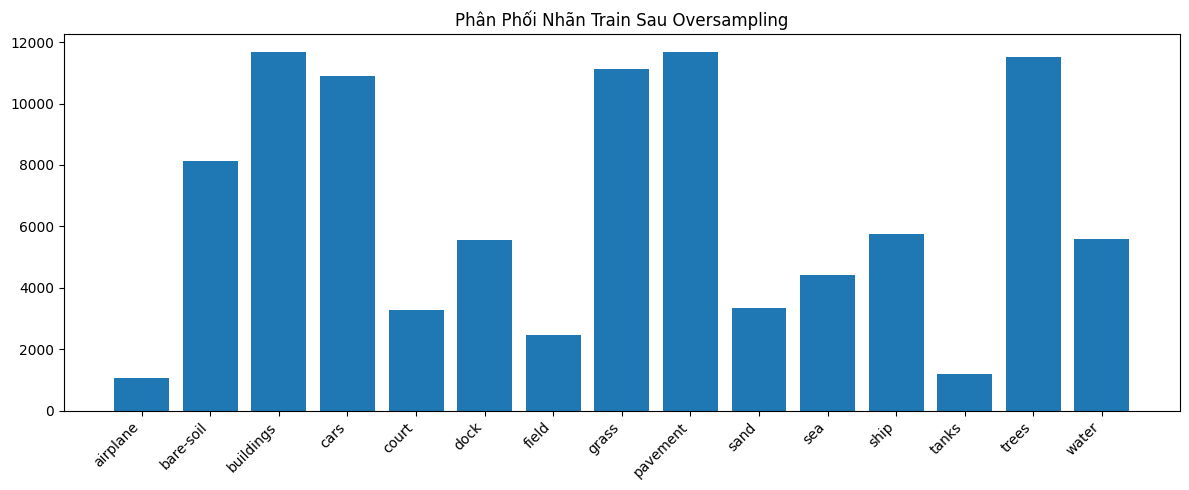

Train: 15000, Val: 480, Test: 600
So sánh phân phối nhãn giữa Train, Val, và Test...

Phân phối nhãn (số positive samples):
            Train  Validation   Test
airplane     67.0        12.0   20.0
bare-soil   947.0       224.0  304.0
buildings  1405.0       339.0  417.0
cars       1301.0       316.0  409.0
court       216.0        53.0   75.0
dock        180.0        41.0   50.0
field       139.0        36.0   39.0
grass      1464.0       365.0  466.0
pavement   1495.0       375.0  458.0
sand        168.0        39.0   52.0
sea         146.0        31.0   44.0
ship        193.0        44.0   47.0
tanks        72.0        15.0   21.0
trees      1540.0       383.0  483.0
water       547.0       127.0  178.0


<Figure size 1200x600 with 0 Axes>

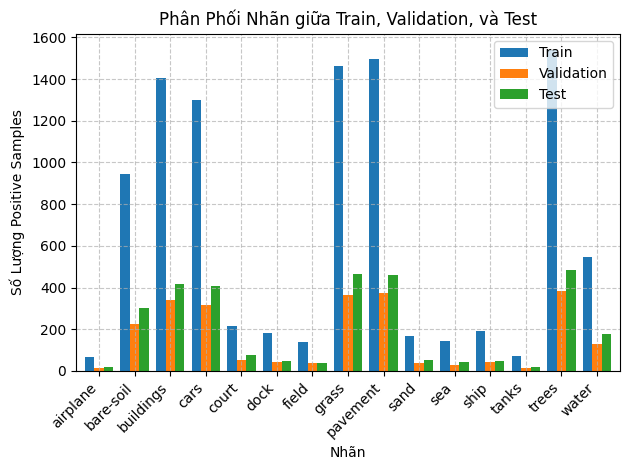


Tỷ lệ positive samples (%):
           Train  Validation   Test
airplane    3.49        2.50   3.33
bare-soil  49.32       46.67  50.67
buildings  73.18       70.62  69.50
cars       67.76       65.83  68.17
court      11.25       11.04  12.50
dock        9.38        8.54   8.33
field       7.24        7.50   6.50
grass      76.25       76.04  77.67
pavement   77.86       78.12  76.33
sand        8.75        8.12   8.67
sea         7.60        6.46   7.33
ship       10.05        9.17   7.83
tanks       3.75        3.12   3.50
trees      80.21       79.79  80.50
water      28.49       26.46  29.67


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:02<00:00, 50.1MB/s]


Epoch 1/50 - train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 1 - Phân phối nhãn trong batch đầu tiên: {'airplane': 0.0, 'bare-soil': 0.56, 'buildings': 0.88, 'cars': 0.81, 'court': 0.12, 'dock': 0.56, 'field': 0.12, 'grass': 0.81, 'pavement': 0.81, 'sand': 0.19, 'sea': 0.25, 'ship': 0.5, 'tanks': 0.19, 'trees': 0.88, 'water': 0.56}

--- Validation Classification Report ---
              precision    recall  f1-score   support

    airplane       1.00      0.17      0.29        12
   bare-soil       0.48      0.98      0.64       224
   buildings       0.87      0.95      0.91       339
        cars       0.82      0.91      0.86       316
       court       0.48      0.51      0.50        53
        dock       0.25      0.44      0.32        41
       field       0.38      0.56      0.45        36
       grass       0.78      0.98      0.87       365
    pavement       0.90      0.91      0.90       375
        sand       0.35      0.72      0.47        39
         sea       0.30      0.29      0.30        31
        ship       0.35      0

Epoch 2/50 - train:   0%|          | 0/938 [00:00<?, ?it/s]

...

Epoch 26 - Phân phối nhãn trong batch đầu tiên: {'airplane': 0.0, 'bare-soil': 0.62, 'buildings': 0.94, 'cars': 0.88, 'court': 0.12, 'dock': 0.44, 'field': 0.19, 'grass': 0.94, 'pavement': 0.94, 'sand': 0.06, 'sea': 0.38, 'ship': 0.56, 'tanks': 0.19, 'trees': 0.88, 'water': 0.31}

--- Validation Classification Report ---
              precision    recall  f1-score   support

    airplane       0.92      0.92      0.92        12
   bare-soil       0.59      0.92      0.72       224
   buildings       0.90      0.95      0.93       339
        cars       0.90      0.92      0.91       316
       court       0.74      0.66      0.70        53
        dock       0.85      0.83      0.84        41
       field       0.97      0.78      0.86        36
       grass       0.86      0.98      0.92       365
    pavement       0.93      0.98      0.96       375
        sand       0.92      0.85      0.88        39
         sea       0.93      0.90      0.92        31
        ship       0.69     

Epoch 27/50 - train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 27 - Phân phối nhãn trong batch đầu tiên: {'airplane': 0.0, 'bare-soil': 0.62, 'buildings': 0.94, 'cars': 0.88, 'court': 0.25, 'dock': 0.31, 'field': 0.06, 'grass': 0.81, 'pavement': 0.88, 'sand': 0.12, 'sea': 0.19, 'ship': 0.31, 'tanks': 0.31, 'trees': 0.69, 'water': 0.31}

--- Validation Classification Report ---
              precision    recall  f1-score   support

    airplane       0.67      1.00      0.80        12
   bare-soil       0.62      0.92      0.74       224
   buildings       0.92      0.95      0.93       339
        cars       0.87      0.96      0.91       316
       court       0.80      0.53      0.64        53
        dock       0.74      0.98      0.84        41
       field       0.84      0.72      0.78        36
       grass       0.86      0.98      0.92       365
    pavement       0.96      0.93      0.94       375
        sand       0.95      0.92      0.94        39
         sea       0.93      0.81      0.86        31
        ship       0.75     

Epoch 28/50 - train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 28 - Phân phối nhãn trong batch đầu tiên: {'airplane': 0.31, 'bare-soil': 0.62, 'buildings': 0.94, 'cars': 0.75, 'court': 0.12, 'dock': 0.25, 'field': 0.19, 'grass': 0.88, 'pavement': 0.94, 'sand': 0.12, 'sea': 0.19, 'ship': 0.25, 'tanks': 0.06, 'trees': 0.94, 'water': 0.44}

--- Validation Classification Report ---
              precision    recall  f1-score   support

    airplane       0.92      0.92      0.92        12
   bare-soil       0.70      0.88      0.78       224
   buildings       0.94      0.95      0.94       339
        cars       0.88      0.95      0.91       316
       court       0.60      0.58      0.59        53
        dock       0.73      0.85      0.79        41
       field       0.72      0.81      0.76        36
       grass       0.86      0.97      0.91       365
    pavement       0.92      0.97      0.95       375
        sand       0.89      0.82      0.85        39
         sea       0.84      0.87      0.86        31
        ship       0.77    

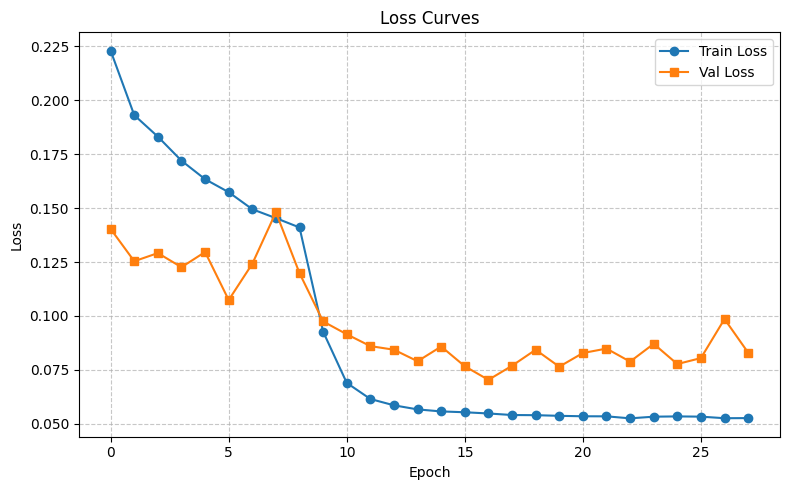

Training finished. Check /kaggle/working for best_model.pth, losses.png, label_distribution_*.png


In [4]:
import os, gc, time, copy, glob, logging, warnings
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler, ConcatDataset
from torchvision import transforms
from torchvision.models import resnet50
from PIL import Image
from sklearn.metrics import f1_score, average_precision_score, classification_report
from torch.cuda.amp import autocast, GradScaler
from torchvision.transforms import ToPILImage

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# ----- Config -----
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DATA_PATH = '/kaggle/input/aid-multilabel/AID_multilabel/'
CSV_PATH = os.path.join(DATA_PATH, 'multilabel.csv')
# ======= GỘP NHÃN TƯƠNG TỰ =======
# print("Đang xử lý gộp nhãn...")
# Đọc file gốc
df_labels = pd.read_csv(CSV_PATH)
first_col = df_labels.columns[0]
df_labels = df_labels.rename(columns={first_col: 'image_name'})
# print("Phân phối nhãn trước xử lý:",df_labels.columns[1:].tolist())
# print(df_labels.drop(columns=['image_name']).sum().sort_values(ascending=False))
# Các nhóm nhãn cần gộp
# merge_map = {
#     'Water': ['sea', 'water'],
#     'land': ['bare-soil', 'sand', 'field']
# }

# Loại nhãn trước khi gộp (thêm pavement để đạt L=11)
# drop_labels = ['mobile-home', 'chaparral']  # Thêm 'pavement' để giảm từ 12 xuống 11
# for drop_label in drop_labels:
#     if drop_label in df_labels.columns:
#         df_labels = df_labels.drop(columns=[drop_label])

# # Thực hiện gộp nhãn
# for new_label, old_labels in merge_map.items():
#     existing_cols = [col for col in old_labels if col in df_labels.columns]
#     if not existing_cols:
#         print(f"⚠️ Cảnh báo: Không tìm thấy nhãn nào trong {old_labels} để gộp thành '{new_label}'.")
#         continue
#     if new_label in df_labels.columns:
#         print(f"⚠️ Cảnh báo: Nhãn '{new_label}' đã tồn tại, đổi thành '{new_label}_merged'.")
#         new_label = f"{new_label}_merged"
#     df_labels[new_label] = df_labels[existing_cols].max(axis=1)

# # Loại bỏ các cột cũ đã gộp
# cols_to_drop = [c for group in merge_map.values() for c in group if c in df_labels.columns]
# df_labels = df_labels.drop(columns=cols_to_drop)

# In phân phối trước/sau gộp để kiểm tra
# print("Phân phối nhãn sau xử lý:", df_labels.columns[1:].tolist())
# print(df_labels.drop(columns=['image_name']).sum().sort_values(ascending=False))

# # Ghi file CSV mới
# NEW_CSV_PATH = '/kaggle/working/multilabel_merged.csv'
# try:
#     df_labels.to_csv(NEW_CSV_PATH, index=False)
#     print(f"Gộp nhãn xong, lưu thành: {NEW_CSV_PATH}")
# except PermissionError as e:
#     print(f"❌ Lỗi ghi file: {e}. Vui lòng kiểm tra quyền truy cập /kaggle/working/.")
# except Exception as e:
#     print(f"❌ Lỗi không xác định khi ghi file: {e}.")

# # Cập nhật đường dẫn CSV dùng cho dataset
# CSV_PATH = NEW_CSV_PATH

# # Cập nhật L để khớp với số nhãn
# L = len(df_labels.columns) - 1  # Cập nhật L dựa trên số cột nhãn thực tế
# print(f"Số nhãn sau gộp (L): {L}")

TRAIN_IMG_DIR = os.path.join(DATA_PATH, 'images/images_tr')
TEST_IMG_DIR = os.path.join(DATA_PATH, 'images/images_test')
L = 15 # loại bỏ mobile-home, chaparral, xử lý water, land 
K = 512
IMG_SIZE = 224
BATCH_SIZE = 16  # Giảm để tránh memory error
EPOCHS = 50
LR = 1e-4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True
UNFREEZE_LAST_AT = 3
UNFREEZE_ALL_AT = 10
USE_LOSS = 'asl'
CLIP = 0.15
GAMMA_POS = 0.0
GAMMA_NEG = 1.0  # Giảm để tăng precision
PATIENCE = 10
MAX_TRAIN_SAMPLES = 15000 # Giảm để tiết kiệm thời gian
DEBUG = False
print("Config ready. Device:", DEVICE)

# ----- Transforms -----
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=5),
    transforms.ToTensor(),
    transforms.GaussianBlur(3, sigma=(0.1, 2.0)),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform_val = transform_test = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ----- Dataset -----
class MultilabelDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None, drop_labels=['mobile-home', 'chaparral']):
        self.labels_df = pd.read_csv(csv_file)
        first_col = self.labels_df.columns[0]
        self.labels_df = self.labels_df.rename(columns={first_col: 'image_name'})
        self.img_dir = img_dir
        self.transform = transform
        label_cols = self.labels_df.columns[1:].tolist()
        for drop_label in drop_labels:
            if drop_label in label_cols:
                label_cols.remove(drop_label)
        self.label_columns = label_cols
        assert len(self.label_columns) == L
        available_files = set()
        for pattern in ['**/*.tif', '**/*.jpg', '**/*.png']:
            for f in glob.glob(os.path.join(img_dir, pattern), recursive=True):
                base = os.path.basename(f).rsplit('.',1)[0].lower()
                available_files.add(base)
        self.labels_df['image_name_lower'] = self.labels_df['image_name'].str.lower()
        self.labels_df = self.labels_df[self.labels_df['image_name_lower'].isin(available_files)].reset_index(drop=True)
        self.labels_df = self.labels_df.drop(columns=['image_name_lower'])

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        img_basename = row['image_name']
        base_lower = str(img_basename).lower()
        found = None
        for ext in ['tif', 'jpg', 'png']:
            candidates = glob.glob(os.path.join(self.img_dir, f'**/{base_lower}.{ext}'), recursive=True)
            if candidates:
                found = candidates[0]
                break
        img = Image.open(found).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        labels = torch.tensor(row[self.label_columns].values.astype(np.float32))
        return img, labels, img_basename

# ----- Weighted Sampler -----
def build_weighted_sampler(dataset):
    labels_all = []
    for _, labels, _ in dataset:
        labels_all.append(labels.numpy())
    labels_all = np.vstack(labels_all)
    pos_counts = labels_all.sum(axis=0)
    pos_counts = np.maximum(pos_counts, 1.0)
    class_weights = 1.0 / pos_counts
    # Tăng trọng số cho nhãn hiếm hơn
    sample_weights = np.mean([labels_all[:, i] * (class_weights[i] * 1.5) if pos_counts[i] < 500 else labels_all[:, i] * class_weights[i] for i in range(labels_all.shape[1])], axis=0)
    sample_weights = np.where(sample_weights == 0, class_weights.mean(), sample_weights)
    return WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ----- ASL with Label Smoothing -----
class AsymmetricLossMultiLabel(nn.Module):
    def __init__(self, gamma_pos=0.0, gamma_neg=1.0, clip=0.15, class_weights=None):
        super().__init__()
        self.gamma_pos = gamma_pos
        self.gamma_neg = gamma_neg
        self.clip = clip
        self.class_weights = class_weights

    def forward(self, logits, targets):
        targets_smooth = targets * 0.9 + 0.05
        probs = torch.sigmoid(logits)
        loss = F.binary_cross_entropy_with_logits(logits, targets_smooth, reduction='none')
        pt = probs * targets + (1 - probs) * (1 - targets)
        gamma = self.gamma_pos * targets + self.gamma_neg * (1 - targets)
        focal_factor = (1 - pt) ** gamma
        if self.clip is not None and self.clip > 0:
            neg_probs = (1 - probs)
            clipped_neg_probs = (neg_probs + self.clip).clamp(max=1)
            pt_neg = probs * targets + clipped_neg_probs * (1 - targets)
            focal_factor = (1 - pt_neg) ** gamma
        if self.class_weights is not None:
            loss = loss * self.class_weights.to(logits.device)
        return (focal_factor * loss).mean()

# ----- Model -----
class SpatialTransformer(nn.Module):
    def __init__(self, L, K, output_size):
        super().__init__()
        self.L = L
        self.K = K
        theta_init = torch.zeros(L, 2, 3)
        theta_init[:,0,0] = 1.0
        theta_init[:,1,1] = 1.0
        self.theta = nn.Parameter(theta_init)

    def forward(self, x):
        B = x.shape[0]
        out = []
        grids = []
        for l in range(self.L):
            theta_l = self.theta[l].unsqueeze(0).repeat(B,1,1).to(x.device)
            grid = F.affine_grid(theta_l, torch.Size([B, x.shape[2], x.shape[3], x.shape[4]]), align_corners=False)
            x_slice = x[:, l]
            attn_x = F.grid_sample(x_slice, grid, mode='bilinear', align_corners=False, padding_mode='zeros')
            out.append(attn_x)
            grids.append(grid)
        attn = torch.stack(out, dim=1)
        return attn, grids

class AttentionALRNCNN(nn.Module):
    def __init__(self, num_classes=L, feature_size=7):
        super().__init__()
        resnet = resnet50(pretrained=True)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.feature_channels = 2048
        self.num_classes = num_classes
        self.K = K
        self.label_wise_conv = nn.Conv2d(self.feature_channels, K * num_classes, kernel_size=1)
        self.stn = SpatialTransformer(num_classes, K, feature_size)
        self.pairwise_conv = nn.Conv2d(2 * K, K, kernel_size=1)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.mlp = nn.Sequential(nn.Linear(K, 512), nn.ReLU(), nn.Dropout(0.7), nn.Linear(512, 1))

    def forward(self, x):
        B = x.shape[0]
        features = self.backbone(x)
        lf = self.label_wise_conv(features)
        lf = lf.view(B, self.num_classes, self.K, lf.shape[2], lf.shape[3])
        attn, grids = self.stn(lf)
        logits = []
        for l in range(self.num_classes):
            A_l = attn[:, l]
            rels = []
            for m in range(self.num_classes):
                if m == l: continue
                A_m = attn[:, m]
                concat = torch.cat([A_l, A_m], dim=1)
                pairwise = self.pairwise_conv(concat)
                pooled = self.gap(pairwise).view(B, -1)
                out = self.mlp(pooled)
                rels.append(out)
            sum_rels = torch.sum(torch.stack(rels, dim=0), dim=0).squeeze(-1) if len(rels)>0 else torch.zeros(B, device=A_l.device)
            logits.append(sum_rels)
        return torch.stack(logits, dim=1), attn, grids

# ----- Prepare Data -----
# ----- Chuẩn hóa biến và cấu trúc -----

# Dataset gốc (đã có nhãn và đường dẫn hợp lệ)
full_dataset = MultilabelDataset(CSV_PATH, TRAIN_IMG_DIR, transform=transform_train)
test_dataset = MultilabelDataset(CSV_PATH, TEST_IMG_DIR, transform=transform_test)

# Chia train / val (80/20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size],
                                          generator=torch.Generator().manual_seed(SEED))

# Lấy danh sách nhãn gốc (từ dataset chính)
label_columns = full_dataset.label_columns

# --- Tính phân phối ban đầu ---
def get_label_distribution(dataset, label_columns):
    labels_all = []
    for _, labels, _ in dataset:
        labels_all.append(labels.numpy())
    labels_all = np.vstack(labels_all)
    return pd.Series(labels_all.sum(axis=0), index=label_columns)

train_dist = get_label_distribution(train_dataset, label_columns)
val_dist = get_label_distribution(val_dataset, label_columns)
print("Phân phối nhãn Train:")
print(train_dist)

# --- Oversampling cho nhãn hiếm ---
positive_counts = train_dist
rare_labels = [label for label, count in positive_counts.items() if count < 350]
print("Nhãn hiếm:", rare_labels)

def augment_rare_samples(dataset, rare_labels, positive_counts):
    aug_data = []
    to_pil = ToPILImage()
    for idx in range(len(dataset)):
        img, labels, img_name = dataset[idx]
        for label_idx, label in enumerate(dataset.dataset.label_columns):
            if labels[label_idx] == 1 and label in rare_labels:
                img_pil = to_pil(img)
                num_aug = 35 if positive_counts[label] < 100 else (30 if positive_counts[label] < 250 else 0)
                for i in range(num_aug):
                    aug_img = transform_train(img_pil)
                    aug_data.append((aug_img, labels, f"{img_name}_aug_{label}_{i}"))
    return aug_data

aug_samples = augment_rare_samples(train_dataset, rare_labels, positive_counts)
print(f"Đã tạo thêm {len(aug_samples)} mẫu tăng cường.")

# ✅ Gộp train_dataset gốc và các mẫu augment
# Chuyển list -> Dataset tạm
class AugmentedDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        return self.samples[idx]

aug_dataset = AugmentedDataset(aug_samples)
train_dataset_full = ConcatDataset([train_dataset, aug_dataset])

# ✅ Lưu lại label_columns để dùng sau
train_dataset_full.label_columns = label_columns

# Giới hạn nếu quá nhiều mẫu
if len(train_dataset_full) > MAX_TRAIN_SAMPLES:
    indices = np.random.choice(len(train_dataset_full), MAX_TRAIN_SAMPLES, replace=False)
    train_dataset_full = torch.utils.data.Subset(train_dataset_full, indices)

# Weighted sampler
sampler = build_weighted_sampler(train_dataset_full)

train_loader = DataLoader(train_dataset_full, batch_size=BATCH_SIZE, sampler=sampler, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

# --- Kiểm tra phân phối sau oversampling ---
aug_labels = []
for img, labels, _ in train_dataset_full:
    aug_labels.append(labels.numpy())
aug_labels = np.vstack(aug_labels)
aug_counts = aug_labels.sum(axis=0)

plt.figure(figsize=(12, 5))
plt.bar(label_columns, aug_counts)
plt.xticks(rotation=45, ha="right")
plt.title("Phân Phối Nhãn Train Sau Oversampling")
plt.tight_layout()
plt.savefig('/kaggle/working/label_distribution_train_oversampled.png')
plt.show()

print(f"Train: {len(train_dataset_full)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# ----- So sánh Phân Phối Train/Val/Test -----
print("So sánh phân phối nhãn giữa Train, Val, và Test...")

# Hàm tính phân phối nhãn từ dataset
def get_label_distribution(dataset, label_columns):
    labels_all = []
    for _, labels, _ in dataset:
        labels_all.append(labels.numpy())
    labels_all = np.vstack(labels_all)
    return pd.Series(labels_all.sum(axis=0), index=label_columns)

# Lấy label_columns từ dataset gốc
label_columns = train_dataset_full.dataset.label_columns

# Tính phân phối cho từng tập
train_dist = get_label_distribution(train_dataset, label_columns)
val_dist = get_label_distribution(val_dataset, label_columns)
test_dist = get_label_distribution(test_dataset, label_columns)

# Tạo DataFrame để so sánh
dist_df = pd.DataFrame({
    'Train': train_dist,
    'Validation': val_dist,
    'Test': test_dist
})

# In bảng phân phối
print("\nPhân phối nhãn (số positive samples):")
print(dist_df)

# Vẽ biểu đồ so sánh
plt.figure(figsize=(12, 6))
dist_df.plot(kind='bar', width=0.8)
plt.title("Phân Phối Nhãn giữa Train, Validation, và Test")
plt.xlabel("Nhãn")
plt.ylabel("Số Lượng Positive Samples")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('/kaggle/working/label_distribution_comparison.png')
plt.show()

# Tính tỷ lệ positive samples so với tổng số mẫu trong từng tập
total_train = len(train_dataset)
total_val = len(val_dataset)
total_test = len(test_dataset)
dist_df_percent = dist_df.div([total_train, total_val, total_test], axis=1) * 100
print("\nTỷ lệ positive samples (%):")
print(dist_df_percent.round(2))

# ----- Train -----
def evaluate_metrics(model, loader, label_columns, device=DEVICE, split='Validation'):
    model.eval()
    all_labels, all_outputs = [], []
    try:
        with torch.no_grad():
            for images, labels, _ in loader:
                images = images.to(device)
                labels = labels.cpu().numpy()
                outputs, _, _ = model(images)
                outputs = torch.sigmoid(outputs).cpu().numpy()
                all_labels.append(labels)
                all_outputs.append(outputs)
    except Exception as e:
        print(f"Error in {split} DataLoader: {e}")
        return 0.0, 0.0, 0.0, np.zeros(len(label_columns))
    
    all_labels = np.vstack(all_labels).astype(int)
    all_outputs = np.vstack(all_outputs)
    
    thresholds = np.zeros(all_outputs.shape[1])
    for i in range(all_outputs.shape[1]):
        best_f1, best_thresh = 0, 0.5
        for thresh in np.linspace(0.05, 0.95, 19):
            preds = (all_outputs[:, i] >= thresh).astype(int)
            f1 = f1_score(all_labels[:, i], preds, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh
        thresholds[i] = best_thresh
    
    preds = np.zeros_like(all_outputs)
    for i in range(all_outputs.shape[1]):
        preds[:, i] = (all_outputs[:, i] >= thresholds[i]).astype(int)
    
    f1_micro = f1_score(all_labels, preds, average='micro')
    f1_macro = f1_score(all_labels, preds, average='macro')
    mAP = average_precision_score(all_labels, all_outputs, average='macro')
    f1_per_class = f1_score(all_labels, preds, average=None)
    
    print(f"\n--- {split} Classification Report ---")
    print(classification_report(all_labels, preds, target_names=label_columns, zero_division=0))
    
    for i, label in enumerate(label_columns):
        print(f"{label}: F1={f1_per_class[i]:.4f}, Threshold={thresholds[i]:.4f}")
    
    return f1_micro, f1_macro, mAP, thresholds

model = AttentionALRNCNN(num_classes=L, feature_size=7).to(DEVICE)
for p in model.backbone.parameters():
    p.requires_grad = False
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, verbose=True)
scaler = GradScaler()
pos_counts = train_dist  # Sử dụng phân phối từ train_dist
class_weights = 1.0 / pos_counts
class_weights = class_weights / class_weights.sum() * len(class_weights)  # Chuẩn hóa
criterion = AsymmetricLossMultiLabel(gamma_pos=GAMMA_POS, gamma_neg=GAMMA_NEG, clip=CLIP, class_weights=torch.tensor(class_weights)).to(DEVICE)
# criterion = AsymmetricLossMultiLabel(gamma_pos=GAMMA_POS, gamma_neg=GAMMA_NEG, clip=CLIP).to(DEVICE)
best_val_f1_macro = 0.0
epochs_no_improve = 0
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    gc.collect()
    torch.cuda.empty_cache()
    epoch_start = time.time()
    if epoch + 1 == UNFREEZE_LAST_AT:
        print(f"Unfreezing last backbone block at epoch {epoch+1}")
        for name, module in model.backbone.named_children():
            if name == 'layer4':
                for p in module.parameters():
                    p.requires_grad = True
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=2e-4)
    if epoch + 1 == UNFREEZE_ALL_AT:
        print(f"Unfreezing entire backbone at epoch {epoch+1}")
        for p in model.backbone.parameters():
            p.requires_grad = True
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR/5.0, weight_decay=2e-4)

    model.train()
    running_loss = 0.0
    loop = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{EPOCHS} - train", leave=False)
    try:
        for batch_idx, (images, labels, _) in loop:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            with autocast():
                outputs, _, _ = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(filter(lambda p: p.requires_grad, model.parameters()), max_norm=2.0)
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item() * images.size(0)
    
            # Kiểm tra phân phối trong batch đầu tiên của mỗi epoch
            if batch_idx == 0:  # Chỉ in cho batch đầu tiên
                batch_labels = labels.cpu().numpy()  # Lấy nhãn từ batch
                batch_size = batch_labels.shape[0]
                batch_dist = np.mean(batch_labels, axis=0)  # Tính tỷ lệ positive samples
                batch_dist_dict = dict(zip(train_dataset_full.dataset.label_columns, batch_dist.round(2)))  # Sử dụng label_columns từ full_train_dataset
                print(f"Epoch {epoch+1} - Phân phối nhãn trong batch đầu tiên: {batch_dist_dict}")
    
    except Exception as e:
        print(f"Error in training loop: {e}")
        continue
    
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    val_loss_total = 0.0
    try:
        with torch.no_grad():
            for images, labels, _ in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                with autocast():
                    outputs, _, _ = model(images)
                    loss = criterion(outputs, labels)
                val_loss_total += loss.item() * images.size(0)
    except Exception as e:
        print(f"Error in validation loop: {e}")
        continue
    
    epoch_val_loss = val_loss_total / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    f1_micro, f1_macro, mAP, thresholds = evaluate_metrics(model, val_loader, train_dataset_full.dataset.label_columns, DEVICE, split='Validation')
    epoch_time = time.time() - epoch_start
    print(f"\nEpoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_train_loss:.6f} Val Loss: {epoch_val_loss:.6f} "
          f"| F1-micro: {f1_micro:.4f} F1-macro: {f1_macro:.4f} mAP: {mAP:.4f} | Time: {epoch_time:.2f}s | Thresholds: {thresholds[:5]}...")

    scheduler.step(f1_macro)
    if f1_macro > best_val_f1_macro:
        best_val_f1_macro = f1_macro
        epochs_no_improve = 0
        torch.save({'epoch': epoch+1, 'model_state': model.state_dict(), 'thresholds': thresholds}, '/kaggle/working/best_imblanced_model.pth')
        print("Saved best model.")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Final Test Evaluation
print("\n=== Final Test Results ===")
f1_micro, f1_macro, mAP, thresholds = evaluate_metrics(model, test_loader, train_dataset_full.dataset.label_columns, DEVICE, split='Test')
print(f"F1-micro: {f1_micro:.4f}, F1-macro: {f1_macro:.4f}, mAP: {mAP:.4f}")

# Plot Losses
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.title("Loss Curves")
plt.tight_layout()
plt.savefig('/kaggle/working/losses.png')
plt.show()

print("Training finished. Check /kaggle/working for best_model.pth, losses.png, label_distribution_*.png")

Config ready. Device: cuda
Phân phối nhãn Train:
airplane       67.0
bare-soil     947.0
buildings    1405.0
cars         1301.0
court         216.0
dock          180.0
field         139.0
grass        1464.0
pavement     1495.0
sand          168.0
sea           146.0
ship          193.0
tanks          72.0
trees        1540.0
water         547.0
dtype: float32
Nhãn hiếm: ['airplane', 'court', 'dock', 'field', 'sand', 'sea', 'ship', 'tanks']
Đã tạo thêm 36125 mẫu tăng cường.


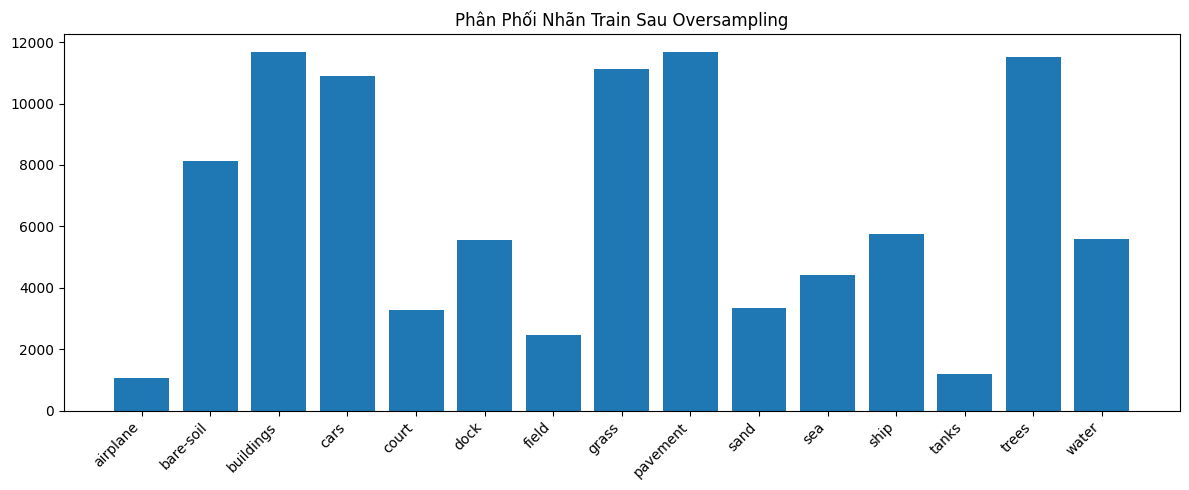

Train: 15000, Val: 480, Test: 600
So sánh phân phối nhãn giữa Train, Val, và Test...

Phân phối nhãn (số positive samples):
            Train  Validation   Test
airplane     67.0        12.0   20.0
bare-soil   947.0       224.0  304.0
buildings  1405.0       339.0  417.0
cars       1301.0       316.0  409.0
court       216.0        53.0   75.0
dock        180.0        41.0   50.0
field       139.0        36.0   39.0
grass      1464.0       365.0  466.0
pavement   1495.0       375.0  458.0
sand        168.0        39.0   52.0
sea         146.0        31.0   44.0
ship        193.0        44.0   47.0
tanks        72.0        15.0   21.0
trees      1540.0       383.0  483.0
water       547.0       127.0  178.0


<Figure size 1200x600 with 0 Axes>

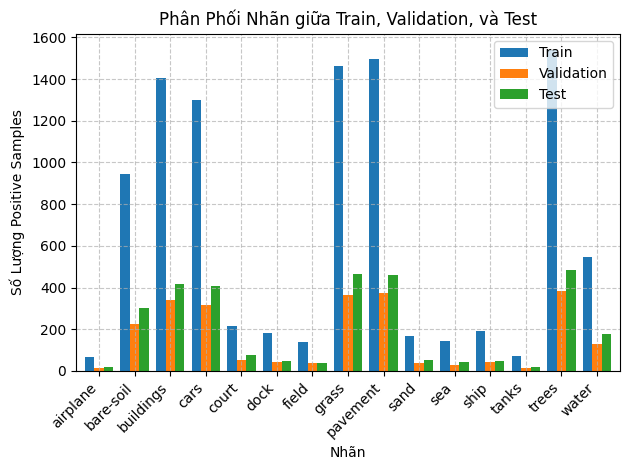


Tỷ lệ positive samples (%):
           Train  Validation   Test
airplane    3.49        2.50   3.33
bare-soil  49.32       46.67  50.67
buildings  73.18       70.62  69.50
cars       67.76       65.83  68.17
court      11.25       11.04  12.50
dock        9.38        8.54   8.33
field       7.24        7.50   6.50
grass      76.25       76.04  77.67
pavement   77.86       78.12  76.33
sand        8.75        8.12   8.67
sea         7.60        6.46   7.33
ship       10.05        9.17   7.83
tanks       3.75        3.12   3.50
trees      80.21       79.79  80.50
water      28.49       26.46  29.67


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:01<00:00, 66.1MB/s]


Epoch 1/50 - train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 1 - Phân phối nhãn trong batch đầu tiên: {'airplane': 0.19, 'bare-soil': 0.44, 'buildings': 0.81, 'cars': 0.94, 'court': 0.06, 'dock': 0.5, 'field': 0.38, 'grass': 0.94, 'pavement': 0.94, 'sand': 0.06, 'sea': 0.25, 'ship': 0.62, 'tanks': 0.06, 'trees': 0.94, 'water': 0.44}

--- Validation Classification Report ---
              precision    recall  f1-score   support

    airplane       0.16      0.25      0.19        12
   bare-soil       0.51      0.92      0.66       224
   buildings       0.88      0.91      0.89       339
        cars       0.78      0.92      0.85       316
       court       0.38      0.49      0.43        53
        dock       0.25      0.59      0.35        41
       field       0.67      0.39      0.49        36
       grass       0.82      0.95      0.88       365
    pavement       0.84      0.95      0.89       375
        sand       0.67      0.56      0.61        39
         sea       0.48      0.48      0.48        31
        ship       0.27      

Epoch 2/50 - train:   0%|          | 0/938 [00:00<?, ?it/s]

...

Epoch 27 - Phân phối nhãn trong batch đầu tiên: {'airplane': 0.06, 'bare-soil': 0.62, 'buildings': 0.75, 'cars': 0.69, 'court': 0.25, 'dock': 0.31, 'field': 0.12, 'grass': 0.81, 'pavement': 0.75, 'sand': 0.25, 'sea': 0.19, 'ship': 0.44, 'tanks': 0.06, 'trees': 0.75, 'water': 0.44}

--- Validation Classification Report ---
              precision    recall  f1-score   support

    airplane       0.91      0.83      0.87        12
   bare-soil       0.63      0.87      0.73       224
   buildings       0.94      0.95      0.94       339
        cars       0.89      0.94      0.92       316
       court       0.69      0.64      0.67        53
        dock       0.58      0.76      0.66        41
       field       0.84      0.75      0.79        36
       grass       0.83      0.96      0.89       365
    pavement       0.97      0.91      0.94       375
        sand       0.79      0.77      0.78        39
         sea       0.90      0.87      0.89        31
        ship       0.66    

Epoch 28/50 - train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 28 - Phân phối nhãn trong batch đầu tiên: {'airplane': 0.12, 'bare-soil': 0.56, 'buildings': 0.94, 'cars': 0.88, 'court': 0.06, 'dock': 0.69, 'field': 0.19, 'grass': 0.75, 'pavement': 0.94, 'sand': 0.12, 'sea': 0.38, 'ship': 0.69, 'tanks': 0.12, 'trees': 0.94, 'water': 0.38}

--- Validation Classification Report ---
              precision    recall  f1-score   support

    airplane       0.91      0.83      0.87        12
   bare-soil       0.70      0.83      0.76       224
   buildings       0.94      0.91      0.93       339
        cars       0.90      0.91      0.91       316
       court       0.77      0.68      0.72        53
        dock       0.82      0.76      0.78        41
       field       0.76      0.81      0.78        36
       grass       0.83      0.98      0.90       365
    pavement       0.93      0.92      0.93       375
        sand       0.86      0.79      0.83        39
         sea       0.84      0.84      0.84        31
        ship       0.75    

Epoch 29/50 - train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 29 - Phân phối nhãn trong batch đầu tiên: {'airplane': 0.12, 'bare-soil': 0.5, 'buildings': 0.88, 'cars': 0.88, 'court': 0.25, 'dock': 0.38, 'field': 0.19, 'grass': 0.88, 'pavement': 0.94, 'sand': 0.25, 'sea': 0.31, 'ship': 0.38, 'tanks': 0.12, 'trees': 0.94, 'water': 0.31}

--- Validation Classification Report ---
              precision    recall  f1-score   support

    airplane       1.00      0.83      0.91        12
   bare-soil       0.65      0.85      0.74       224
   buildings       0.93      0.96      0.94       339
        cars       0.86      0.96      0.91       316
       court       0.86      0.45      0.59        53
        dock       0.84      0.76      0.79        41
       field       0.85      0.81      0.83        36
       grass       0.84      0.97      0.90       365
    pavement       0.95      0.94      0.94       375
        sand       1.00      0.82      0.90        39
         sea       0.80      0.90      0.85        31
        ship       0.67     

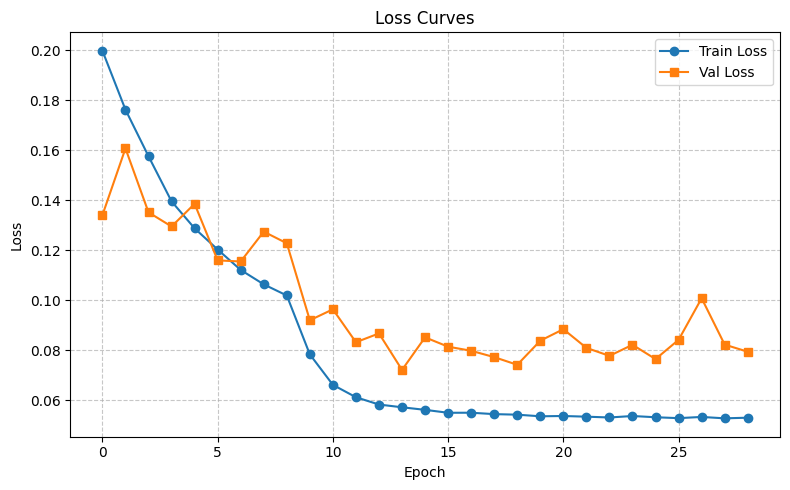

Training finished. Check /kaggle/working for best_model.pth, losses.png, label_distribution_*.png


In [1]:
import os, gc, time, copy, glob, logging, warnings
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler, ConcatDataset
from torchvision import transforms
from torchvision.models import resnet50
from PIL import Image
from sklearn.metrics import f1_score, average_precision_score, classification_report
from torch.cuda.amp import autocast, GradScaler
from torchvision.transforms import ToPILImage

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# ----- Config -----
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DATA_PATH = '/kaggle/input/aid-multilabel/AID_multilabel/'
CSV_PATH = os.path.join(DATA_PATH, 'multilabel.csv')
# ======= GỘP NHÃN TƯƠNG TỰ =======
# print("Đang xử lý gộp nhãn...")
# Đọc file gốc
df_labels = pd.read_csv(CSV_PATH)
first_col = df_labels.columns[0]
df_labels = df_labels.rename(columns={first_col: 'image_name'})
# print("Phân phối nhãn trước xử lý:",df_labels.columns[1:].tolist())
# print(df_labels.drop(columns=['image_name']).sum().sort_values(ascending=False))
# Các nhóm nhãn cần gộp
# merge_map = {
#     'Water': ['sea', 'water'],
#     'land': ['bare-soil', 'sand', 'field']
# }

# Loại nhãn trước khi gộp (thêm pavement để đạt L=11)
# drop_labels = ['mobile-home', 'chaparral']  # Thêm 'pavement' để giảm từ 12 xuống 11
# for drop_label in drop_labels:
#     if drop_label in df_labels.columns:
#         df_labels = df_labels.drop(columns=[drop_label])

# # Thực hiện gộp nhãn
# for new_label, old_labels in merge_map.items():
#     existing_cols = [col for col in old_labels if col in df_labels.columns]
#     if not existing_cols:
#         print(f"⚠️ Cảnh báo: Không tìm thấy nhãn nào trong {old_labels} để gộp thành '{new_label}'.")
#         continue
#     if new_label in df_labels.columns:
#         print(f"⚠️ Cảnh báo: Nhãn '{new_label}' đã tồn tại, đổi thành '{new_label}_merged'.")
#         new_label = f"{new_label}_merged"
#     df_labels[new_label] = df_labels[existing_cols].max(axis=1)

# # Loại bỏ các cột cũ đã gộp
# cols_to_drop = [c for group in merge_map.values() for c in group if c in df_labels.columns]
# df_labels = df_labels.drop(columns=cols_to_drop)

# In phân phối trước/sau gộp để kiểm tra
# print("Phân phối nhãn sau xử lý:", df_labels.columns[1:].tolist())
# print(df_labels.drop(columns=['image_name']).sum().sort_values(ascending=False))

# # Ghi file CSV mới
# NEW_CSV_PATH = '/kaggle/working/multilabel_merged.csv'
# try:
#     df_labels.to_csv(NEW_CSV_PATH, index=False)
#     print(f"Gộp nhãn xong, lưu thành: {NEW_CSV_PATH}")
# except PermissionError as e:
#     print(f"❌ Lỗi ghi file: {e}. Vui lòng kiểm tra quyền truy cập /kaggle/working/.")
# except Exception as e:
#     print(f"❌ Lỗi không xác định khi ghi file: {e}.")

# # Cập nhật đường dẫn CSV dùng cho dataset
# CSV_PATH = NEW_CSV_PATH

# # Cập nhật L để khớp với số nhãn
# L = len(df_labels.columns) - 1  # Cập nhật L dựa trên số cột nhãn thực tế
# print(f"Số nhãn sau gộp (L): {L}")

TRAIN_IMG_DIR = os.path.join(DATA_PATH, 'images/images_tr')
TEST_IMG_DIR = os.path.join(DATA_PATH, 'images/images_test')
L = 15 # loại bỏ mobile-home, chaparral, xử lý water, land 
K = 512
IMG_SIZE = 224
BATCH_SIZE = 16  # Giảm để tránh memory error
EPOCHS = 50
LR = 1e-4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True
UNFREEZE_LAST_AT = 3
UNFREEZE_ALL_AT = 10
USE_LOSS = 'asl'
CLIP = 0.15
GAMMA_POS = 0.0
GAMMA_NEG = 1.0  # Giảm để tăng precision
PATIENCE = 10
MAX_TRAIN_SAMPLES = 15000 # Giảm để tiết kiệm thời gian
DEBUG = False
print("Config ready. Device:", DEVICE)

# ----- Transforms -----
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=5),
    transforms.ToTensor(),
    transforms.GaussianBlur(3, sigma=(0.1, 2.0)),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform_val = transform_test = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ----- Dataset -----
class MultilabelDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None, drop_labels=['mobile-home', 'chaparral']):
        self.labels_df = pd.read_csv(csv_file)
        first_col = self.labels_df.columns[0]
        self.labels_df = self.labels_df.rename(columns={first_col: 'image_name'})
        self.img_dir = img_dir
        self.transform = transform
        label_cols = self.labels_df.columns[1:].tolist()
        for drop_label in drop_labels:
            if drop_label in label_cols:
                label_cols.remove(drop_label)
        self.label_columns = label_cols
        assert len(self.label_columns) == L
        available_files = set()
        for pattern in ['**/*.tif', '**/*.jpg', '**/*.png']:
            for f in glob.glob(os.path.join(img_dir, pattern), recursive=True):
                base = os.path.basename(f).rsplit('.',1)[0].lower()
                available_files.add(base)
        self.labels_df['image_name_lower'] = self.labels_df['image_name'].str.lower()
        self.labels_df = self.labels_df[self.labels_df['image_name_lower'].isin(available_files)].reset_index(drop=True)
        self.labels_df = self.labels_df.drop(columns=['image_name_lower'])

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        img_basename = row['image_name']
        base_lower = str(img_basename).lower()
        found = None
        for ext in ['tif', 'jpg', 'png']:
            candidates = glob.glob(os.path.join(self.img_dir, f'**/{base_lower}.{ext}'), recursive=True)
            if candidates:
                found = candidates[0]
                break
        img = Image.open(found).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        labels = torch.tensor(row[self.label_columns].values.astype(np.float32))
        return img, labels, img_basename

# ----- Weighted Sampler -----
def build_weighted_sampler(dataset):
    labels_all = []
    for _, labels, _ in dataset:
        labels_all.append(labels.numpy())
    labels_all = np.vstack(labels_all)
    pos_counts = labels_all.sum(axis=0)
    pos_counts = np.maximum(pos_counts, 1.0)
    class_weights = 1.0 / pos_counts
    # Tăng trọng số cho nhãn hiếm hơn
    sample_weights = np.mean([labels_all[:, i] * (class_weights[i] * 1.5) if pos_counts[i] < 500 else labels_all[:, i] * class_weights[i] for i in range(labels_all.shape[1])], axis=0)
    sample_weights = np.where(sample_weights == 0, class_weights.mean(), sample_weights)
    return WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ----- ASL with Label Smoothing -----
class AsymmetricLossMultiLabel(nn.Module):
    def __init__(self, gamma_pos=0.0, gamma_neg=1.0, clip=0.15, class_weights=None):
        super().__init__()
        self.gamma_pos = gamma_pos
        self.gamma_neg = gamma_neg
        self.clip = clip
        self.class_weights = class_weights

    def forward(self, logits, targets):
        targets_smooth = targets * 0.9 + 0.05
        probs = torch.sigmoid(logits)
        loss = F.binary_cross_entropy_with_logits(logits, targets_smooth, reduction='none')
        pt = probs * targets + (1 - probs) * (1 - targets)
        gamma = self.gamma_pos * targets + self.gamma_neg * (1 - targets)
        focal_factor = (1 - pt) ** gamma
        if self.clip is not None and self.clip > 0:
            neg_probs = (1 - probs)
            clipped_neg_probs = (neg_probs + self.clip).clamp(max=1)
            pt_neg = probs * targets + clipped_neg_probs * (1 - targets)
            focal_factor = (1 - pt_neg) ** gamma
        if self.class_weights is not None:
            loss = loss * self.class_weights.to(logits.device)
        return (focal_factor * loss).mean()

# ----- Model -----
class SpatialTransformer(nn.Module):
    def __init__(self, L, K, output_size):
        super().__init__()
        self.L = L
        self.K = K
        theta_init = torch.zeros(L, 2, 3)
        theta_init[:,0,0] = 1.0
        theta_init[:,1,1] = 1.0
        self.theta = nn.Parameter(theta_init)

    def forward(self, x):
        B = x.shape[0]
        out = []
        grids = []
        for l in range(self.L):
            theta_l = self.theta[l].unsqueeze(0).repeat(B,1,1).to(x.device)
            grid = F.affine_grid(theta_l, torch.Size([B, x.shape[2], x.shape[3], x.shape[4]]), align_corners=False)
            x_slice = x[:, l]
            attn_x = F.grid_sample(x_slice, grid, mode='bilinear', align_corners=False, padding_mode='zeros')
            out.append(attn_x)
            grids.append(grid)
        attn = torch.stack(out, dim=1)
        return attn, grids
# ----- MGP Block -----
class MGPBlock(nn.Module):
    """
    Multi-Granularity Perception module
    Kết hợp đặc trưng global, medium và local để tăng tính đa tỉ lệ.
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # Branch 1: Global context (1x1 conv)
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        # Branch 2: Medium context (3x3 conv)
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        # Branch 3: Local context (5x5 conv)
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=5, padding=2),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        # Hợp nhất 3 nhánh
        self.merge = nn.Conv2d(out_channels * 3, out_channels, kernel_size=1)

    def forward(self, x):
        g = self.branch1(x)
        m = self.branch2(x)
        l = self.branch3(x)
        fused = torch.cat([g, m, l], dim=1)
        return self.merge(fused)

# ----- Model with MGP -----
class AttentionALRNCNN(nn.Module):
    def __init__(self, num_classes=L, feature_size=7):
        super().__init__()
        resnet = resnet50(pretrained=True)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.feature_channels = 2048
        self.num_classes = num_classes
        self.K = K

        # 🌟 Thêm MGP ngay sau backbone
        self.mgp = MGPBlock(self.feature_channels, self.feature_channels)

        self.label_wise_conv = nn.Conv2d(self.feature_channels, K * num_classes, kernel_size=1)
        self.stn = SpatialTransformer(num_classes, K, feature_size)
        self.pairwise_conv = nn.Conv2d(2 * K, K, kernel_size=1)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(K, 512),
            nn.ReLU(),
            nn.Dropout(0.7),
            nn.Linear(512, 1)
        )

    def forward(self, x):
        B = x.shape[0]
        # 1️⃣ Trích đặc trưng bằng backbone
        features = self.backbone(x)

        # 2️⃣ Multi-Granularity Perception
        features = self.mgp(features)

        # 3️⃣ Label-wise attention
        lf = self.label_wise_conv(features)
        lf = lf.view(B, self.num_classes, self.K, lf.shape[2], lf.shape[3])
        attn, grids = self.stn(lf)

        # 4️⃣ Relation reasoning
        logits = []
        for l in range(self.num_classes):
            A_l = attn[:, l]
            rels = []
            for m in range(self.num_classes):
                if m == l: continue
                A_m = attn[:, m]
                concat = torch.cat([A_l, A_m], dim=1)
                pairwise = self.pairwise_conv(concat)
                pooled = self.gap(pairwise).view(B, -1)
                out = self.mlp(pooled)
                rels.append(out)
            sum_rels = torch.sum(torch.stack(rels, dim=0), dim=0).squeeze(-1) if len(rels) > 0 else torch.zeros(B, device=A_l.device)
            logits.append(sum_rels)
        return torch.stack(logits, dim=1), attn, grids


# class AttentionALRNCNN(nn.Module):
#     def __init__(self, num_classes=L, feature_size=7):
#         super().__init__()
#         resnet = resnet50(pretrained=True)
#         self.backbone = nn.Sequential(*list(resnet.children())[:-2])
#         self.feature_channels = 2048
#         self.num_classes = num_classes
#         self.K = K
#         self.label_wise_conv = nn.Conv2d(self.feature_channels, K * num_classes, kernel_size=1)
#         self.stn = SpatialTransformer(num_classes, K, feature_size)
#         self.pairwise_conv = nn.Conv2d(2 * K, K, kernel_size=1)
#         self.gap = nn.AdaptiveAvgPool2d(1)
#         self.mlp = nn.Sequential(nn.Linear(K, 512), nn.ReLU(), nn.Dropout(0.7), nn.Linear(512, 1))

#     def forward(self, x):
#         B = x.shape[0]
#         features = self.backbone(x)
#         lf = self.label_wise_conv(features)
#         lf = lf.view(B, self.num_classes, self.K, lf.shape[2], lf.shape[3])
#         attn, grids = self.stn(lf)
#         logits = []
#         for l in range(self.num_classes):
#             A_l = attn[:, l]
#             rels = []
#             for m in range(self.num_classes):
#                 if m == l: continue
#                 A_m = attn[:, m]
#                 concat = torch.cat([A_l, A_m], dim=1)
#                 pairwise = self.pairwise_conv(concat)
#                 pooled = self.gap(pairwise).view(B, -1)
#                 out = self.mlp(pooled)
#                 rels.append(out)
#             sum_rels = torch.sum(torch.stack(rels, dim=0), dim=0).squeeze(-1) if len(rels)>0 else torch.zeros(B, device=A_l.device)
#             logits.append(sum_rels)
#         return torch.stack(logits, dim=1), attn, grids

# ----- Prepare Data -----
# ----- Chuẩn hóa biến và cấu trúc -----

# Dataset gốc (đã có nhãn và đường dẫn hợp lệ)
full_dataset = MultilabelDataset(CSV_PATH, TRAIN_IMG_DIR, transform=transform_train)
test_dataset = MultilabelDataset(CSV_PATH, TEST_IMG_DIR, transform=transform_test)

# Chia train / val (80/20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size],
                                          generator=torch.Generator().manual_seed(SEED))

# Lấy danh sách nhãn gốc (từ dataset chính)
label_columns = full_dataset.label_columns

# --- Tính phân phối ban đầu ---
def get_label_distribution(dataset, label_columns):
    labels_all = []
    for _, labels, _ in dataset:
        labels_all.append(labels.numpy())
    labels_all = np.vstack(labels_all)
    return pd.Series(labels_all.sum(axis=0), index=label_columns)

train_dist = get_label_distribution(train_dataset, label_columns)
val_dist = get_label_distribution(val_dataset, label_columns)
print("Phân phối nhãn Train:")
print(train_dist)

# --- Oversampling cho nhãn hiếm ---
positive_counts = train_dist
rare_labels = [label for label, count in positive_counts.items() if count < 350]
print("Nhãn hiếm:", rare_labels)

def augment_rare_samples(dataset, rare_labels, positive_counts):
    aug_data = []
    to_pil = ToPILImage()
    for idx in range(len(dataset)):
        img, labels, img_name = dataset[idx]
        for label_idx, label in enumerate(dataset.dataset.label_columns):
            if labels[label_idx] == 1 and label in rare_labels:
                img_pil = to_pil(img)
                num_aug = 35 if positive_counts[label] < 100 else (30 if positive_counts[label] < 250 else 0)
                for i in range(num_aug):
                    aug_img = transform_train(img_pil)
                    aug_data.append((aug_img, labels, f"{img_name}_aug_{label}_{i}"))
    return aug_data

aug_samples = augment_rare_samples(train_dataset, rare_labels, positive_counts)
print(f"Đã tạo thêm {len(aug_samples)} mẫu tăng cường.")

# ✅ Gộp train_dataset gốc và các mẫu augment
# Chuyển list -> Dataset tạm
class AugmentedDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        return self.samples[idx]

aug_dataset = AugmentedDataset(aug_samples)
train_dataset_full = ConcatDataset([train_dataset, aug_dataset])

# ✅ Lưu lại label_columns để dùng sau
train_dataset_full.label_columns = label_columns

# Giới hạn nếu quá nhiều mẫu
if len(train_dataset_full) > MAX_TRAIN_SAMPLES:
    indices = np.random.choice(len(train_dataset_full), MAX_TRAIN_SAMPLES, replace=False)
    train_dataset_full = torch.utils.data.Subset(train_dataset_full, indices)

# Weighted sampler
sampler = build_weighted_sampler(train_dataset_full)

train_loader = DataLoader(train_dataset_full, batch_size=BATCH_SIZE, sampler=sampler, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

# --- Kiểm tra phân phối sau oversampling ---
aug_labels = []
for img, labels, _ in train_dataset_full:
    aug_labels.append(labels.numpy())
aug_labels = np.vstack(aug_labels)
aug_counts = aug_labels.sum(axis=0)

plt.figure(figsize=(12, 5))
plt.bar(label_columns, aug_counts)
plt.xticks(rotation=45, ha="right")
plt.title("Phân Phối Nhãn Train Sau Oversampling")
plt.tight_layout()
plt.savefig('/kaggle/working/label_distribution_train_oversampled.png')
plt.show()

print(f"Train: {len(train_dataset_full)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# ----- So sánh Phân Phối Train/Val/Test -----
print("So sánh phân phối nhãn giữa Train, Val, và Test...")

# Hàm tính phân phối nhãn từ dataset
def get_label_distribution(dataset, label_columns):
    labels_all = []
    for _, labels, _ in dataset:
        labels_all.append(labels.numpy())
    labels_all = np.vstack(labels_all)
    return pd.Series(labels_all.sum(axis=0), index=label_columns)

# Lấy label_columns từ dataset gốc
label_columns = train_dataset_full.dataset.label_columns

# Tính phân phối cho từng tập
train_dist = get_label_distribution(train_dataset, label_columns)
val_dist = get_label_distribution(val_dataset, label_columns)
test_dist = get_label_distribution(test_dataset, label_columns)

# Tạo DataFrame để so sánh
dist_df = pd.DataFrame({
    'Train': train_dist,
    'Validation': val_dist,
    'Test': test_dist
})

# In bảng phân phối
print("\nPhân phối nhãn (số positive samples):")
print(dist_df)

# Vẽ biểu đồ so sánh
plt.figure(figsize=(12, 6))
dist_df.plot(kind='bar', width=0.8)
plt.title("Phân Phối Nhãn giữa Train, Validation, và Test")
plt.xlabel("Nhãn")
plt.ylabel("Số Lượng Positive Samples")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('/kaggle/working/label_distribution_comparison.png')
plt.show()

# Tính tỷ lệ positive samples so với tổng số mẫu trong từng tập
total_train = len(train_dataset)
total_val = len(val_dataset)
total_test = len(test_dataset)
dist_df_percent = dist_df.div([total_train, total_val, total_test], axis=1) * 100
print("\nTỷ lệ positive samples (%):")
print(dist_df_percent.round(2))

# ----- Train -----
def evaluate_metrics(model, loader, label_columns, device=DEVICE, split='Validation'):
    model.eval()
    all_labels, all_outputs = [], []
    try:
        with torch.no_grad():
            for images, labels, _ in loader:
                images = images.to(device)
                labels = labels.cpu().numpy()
                outputs, _, _ = model(images)
                outputs = torch.sigmoid(outputs).cpu().numpy()
                all_labels.append(labels)
                all_outputs.append(outputs)
    except Exception as e:
        print(f"Error in {split} DataLoader: {e}")
        return 0.0, 0.0, 0.0, np.zeros(len(label_columns))
    
    all_labels = np.vstack(all_labels).astype(int)
    all_outputs = np.vstack(all_outputs)
    
    thresholds = np.zeros(all_outputs.shape[1])
    for i in range(all_outputs.shape[1]):
        best_f1, best_thresh = 0, 0.5
        for thresh in np.linspace(0.05, 0.95, 19):
            preds = (all_outputs[:, i] >= thresh).astype(int)
            f1 = f1_score(all_labels[:, i], preds, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh
        thresholds[i] = best_thresh
    
    preds = np.zeros_like(all_outputs)
    for i in range(all_outputs.shape[1]):
        preds[:, i] = (all_outputs[:, i] >= thresholds[i]).astype(int)
    
    f1_micro = f1_score(all_labels, preds, average='micro')
    f1_macro = f1_score(all_labels, preds, average='macro')
    mAP = average_precision_score(all_labels, all_outputs, average='macro')
    f1_per_class = f1_score(all_labels, preds, average=None)
    
    print(f"\n--- {split} Classification Report ---")
    print(classification_report(all_labels, preds, target_names=label_columns, zero_division=0))
    
    for i, label in enumerate(label_columns):
        print(f"{label}: F1={f1_per_class[i]:.4f}, Threshold={thresholds[i]:.4f}")
    
    return f1_micro, f1_macro, mAP, thresholds

model = AttentionALRNCNN(num_classes=L, feature_size=7).to(DEVICE)
for p in model.backbone.parameters():
    p.requires_grad = False
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, verbose=True)
scaler = GradScaler()
pos_counts = train_dist  # Sử dụng phân phối từ train_dist
class_weights = 1.0 / pos_counts
class_weights = class_weights / class_weights.sum() * len(class_weights)  # Chuẩn hóa
criterion = AsymmetricLossMultiLabel(gamma_pos=GAMMA_POS, gamma_neg=GAMMA_NEG, clip=CLIP, class_weights=torch.tensor(class_weights)).to(DEVICE)
# criterion = AsymmetricLossMultiLabel(gamma_pos=GAMMA_POS, gamma_neg=GAMMA_NEG, clip=CLIP).to(DEVICE)
best_val_f1_macro = 0.0
epochs_no_improve = 0
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    gc.collect()
    torch.cuda.empty_cache()
    epoch_start = time.time()
    if epoch + 1 == UNFREEZE_LAST_AT:
        print(f"Unfreezing last backbone block at epoch {epoch+1}")
        for name, module in model.backbone.named_children():
            if name == 'layer4':
                for p in module.parameters():
                    p.requires_grad = True
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=2e-4)
    if epoch + 1 == UNFREEZE_ALL_AT:
        print(f"Unfreezing entire backbone at epoch {epoch+1}")
        for p in model.backbone.parameters():
            p.requires_grad = True
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR/5.0, weight_decay=2e-4)

    model.train()
    running_loss = 0.0
    loop = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{EPOCHS} - train", leave=False)
    try:
        for batch_idx, (images, labels, _) in loop:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            with autocast():
                outputs, _, _ = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(filter(lambda p: p.requires_grad, model.parameters()), max_norm=2.0)
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item() * images.size(0)
    
            # Kiểm tra phân phối trong batch đầu tiên của mỗi epoch
            if batch_idx == 0:  # Chỉ in cho batch đầu tiên
                batch_labels = labels.cpu().numpy()  # Lấy nhãn từ batch
                batch_size = batch_labels.shape[0]
                batch_dist = np.mean(batch_labels, axis=0)  # Tính tỷ lệ positive samples
                batch_dist_dict = dict(zip(train_dataset_full.dataset.label_columns, batch_dist.round(2)))  # Sử dụng label_columns từ full_train_dataset
                print(f"Epoch {epoch+1} - Phân phối nhãn trong batch đầu tiên: {batch_dist_dict}")
    
    except Exception as e:
        print(f"Error in training loop: {e}")
        continue
    
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    val_loss_total = 0.0
    try:
        with torch.no_grad():
            for images, labels, _ in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                with autocast():
                    outputs, _, _ = model(images)
                    loss = criterion(outputs, labels)
                val_loss_total += loss.item() * images.size(0)
    except Exception as e:
        print(f"Error in validation loop: {e}")
        continue
    
    epoch_val_loss = val_loss_total / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    f1_micro, f1_macro, mAP, thresholds = evaluate_metrics(model, val_loader, train_dataset_full.dataset.label_columns, DEVICE, split='Validation')
    epoch_time = time.time() - epoch_start
    print(f"\nEpoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_train_loss:.6f} Val Loss: {epoch_val_loss:.6f} "
          f"| F1-micro: {f1_micro:.4f} F1-macro: {f1_macro:.4f} mAP: {mAP:.4f} | Time: {epoch_time:.2f}s | Thresholds: {thresholds[:5]}...")

    scheduler.step(f1_macro)
    if f1_macro > best_val_f1_macro:
        best_val_f1_macro = f1_macro
        epochs_no_improve = 0
        torch.save({'epoch': epoch+1, 'model_state': model.state_dict(), 'thresholds': thresholds}, '/kaggle/working/best_imblanced_model.pth')
        print("Saved best model.")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Final Test Evaluation
print("\n=== Final Test Results ===")
f1_micro, f1_macro, mAP, thresholds = evaluate_metrics(model, test_loader, train_dataset_full.dataset.label_columns, DEVICE, split='Test')
print(f"F1-micro: {f1_micro:.4f}, F1-macro: {f1_macro:.4f}, mAP: {mAP:.4f}")

# Plot Losses
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.title("Loss Curves")
plt.tight_layout()
plt.savefig('/kaggle/working/losses.png')
plt.show()

print("Training finished. Check /kaggle/working for best_model.pth, losses.png, label_distribution_*.png")

Config ready. Device: cuda
Phân phối nhãn Train:
airplane       67.0
bare-soil     947.0
buildings    1405.0
cars         1301.0
court         216.0
dock          180.0
field         139.0
grass        1464.0
pavement     1495.0
sand          168.0
sea           146.0
ship          193.0
tanks          72.0
trees        1540.0
water         547.0
dtype: float32
Nhãn hiếm: ['airplane', 'court', 'dock', 'field', 'sand', 'sea', 'ship', 'tanks']
Đã tạo thêm 36125 mẫu tăng cường.


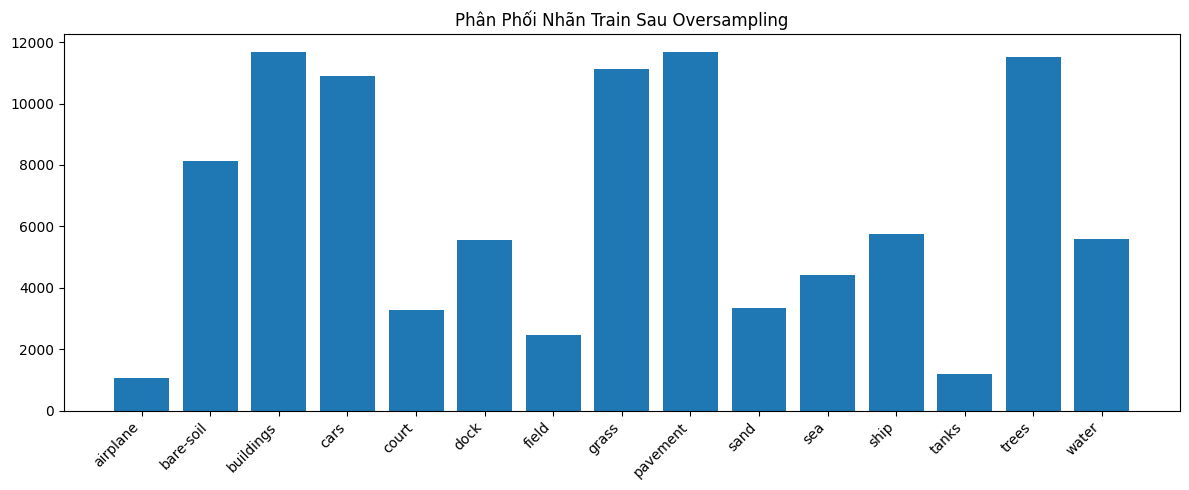

Train: 15000, Val: 480, Test: 600
So sánh phân phối nhãn giữa Train, Val, và Test...

Phân phối nhãn (số positive samples):
            Train  Validation   Test
airplane     67.0        12.0   20.0
bare-soil   947.0       224.0  304.0
buildings  1405.0       339.0  417.0
cars       1301.0       316.0  409.0
court       216.0        53.0   75.0
dock        180.0        41.0   50.0
field       139.0        36.0   39.0
grass      1464.0       365.0  466.0
pavement   1495.0       375.0  458.0
sand        168.0        39.0   52.0
sea         146.0        31.0   44.0
ship        193.0        44.0   47.0
tanks        72.0        15.0   21.0
trees      1540.0       383.0  483.0
water       547.0       127.0  178.0


<Figure size 1200x600 with 0 Axes>

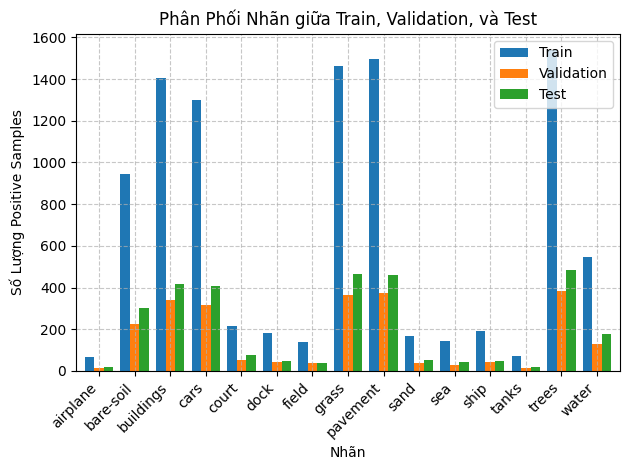


Tỷ lệ positive samples (%):
           Train  Validation   Test
airplane    3.49        2.50   3.33
bare-soil  49.32       46.67  50.67
buildings  73.18       70.62  69.50
cars       67.76       65.83  68.17
court      11.25       11.04  12.50
dock        9.38        8.54   8.33
field       7.24        7.50   6.50
grass      76.25       76.04  77.67
pavement   77.86       78.12  76.33
sand        8.75        8.12   8.67
sea         7.60        6.46   7.33
ship       10.05        9.17   7.83
tanks       3.75        3.12   3.50
trees      80.21       79.79  80.50
water      28.49       26.46  29.67


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth
100%|██████████| 47.2M/47.2M [00:00<00:00, 177MB/s]


Epoch 1/50 - train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 1 - Phân phối nhãn trong batch đầu tiên: {'airplane': 0.06, 'bare-soil': 0.69, 'buildings': 0.81, 'cars': 0.81, 'court': 0.19, 'dock': 0.5, 'field': 0.25, 'grass': 0.81, 'pavement': 0.88, 'sand': 0.25, 'sea': 0.31, 'ship': 0.56, 'tanks': 0.12, 'trees': 0.81, 'water': 0.69}

--- Validation Classification Report ---
              precision    recall  f1-score   support

    airplane       0.54      0.58      0.56        12
   bare-soil       0.51      0.94      0.66       224
   buildings       0.77      0.97      0.86       339
        cars       0.74      0.93      0.82       316
       court       0.62      0.49      0.55        53
        dock       0.38      0.32      0.35        41
       field       0.50      0.56      0.53        36
       grass       0.81      0.95      0.87       365
    pavement       0.89      0.93      0.91       375
        sand       0.71      0.44      0.54        39
         sea       0.39      0.65      0.49        31
        ship       0.33      

Epoch 2/50 - train:   0%|          | 0/938 [00:00<?, ?it/s]

...

Epoch 33 - Phân phối nhãn trong batch đầu tiên: {'airplane': 0.06, 'bare-soil': 0.75, 'buildings': 0.94, 'cars': 0.88, 'court': 0.31, 'dock': 0.12, 'field': 0.25, 'grass': 0.81, 'pavement': 0.88, 'sand': 0.06, 'sea': 0.0, 'ship': 0.06, 'tanks': 0.25, 'trees': 1.0, 'water': 0.25}

--- Validation Classification Report ---
              precision    recall  f1-score   support

    airplane       0.92      0.92      0.92        12
   bare-soil       0.74      0.76      0.75       224
   buildings       0.94      0.95      0.94       339
        cars       0.91      0.94      0.92       316
       court       0.72      0.49      0.58        53
        dock       0.76      0.76      0.76        41
       field       0.80      0.67      0.73        36
       grass       0.86      0.98      0.92       365
    pavement       0.96      0.97      0.96       375
        sand       0.91      0.77      0.83        39
         sea       1.00      0.84      0.91        31
        ship       0.73      

Epoch 34/50 - train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 34 - Phân phối nhãn trong batch đầu tiên: {'airplane': 0.06, 'bare-soil': 0.5, 'buildings': 0.81, 'cars': 0.69, 'court': 0.25, 'dock': 0.38, 'field': 0.06, 'grass': 0.75, 'pavement': 0.75, 'sand': 0.44, 'sea': 0.5, 'ship': 0.44, 'tanks': 0.06, 'trees': 0.75, 'water': 0.5}

--- Validation Classification Report ---
              precision    recall  f1-score   support

    airplane       0.85      0.92      0.88        12
   bare-soil       0.67      0.87      0.76       224
   buildings       0.95      0.93      0.94       339
        cars       0.88      0.98      0.93       316
       court       0.57      0.57      0.57        53
        dock       0.81      0.73      0.77        41
       field       0.93      0.69      0.79        36
       grass       0.84      0.99      0.91       365
    pavement       0.96      0.96      0.96       375
        sand       0.82      0.82      0.82        39
         sea       0.82      0.87      0.84        31
        ship       0.71      0

Epoch 35/50 - train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 35 - Phân phối nhãn trong batch đầu tiên: {'airplane': 0.06, 'bare-soil': 0.62, 'buildings': 0.81, 'cars': 0.75, 'court': 0.12, 'dock': 0.38, 'field': 0.25, 'grass': 0.75, 'pavement': 0.81, 'sand': 0.25, 'sea': 0.31, 'ship': 0.44, 'tanks': 0.12, 'trees': 0.88, 'water': 0.44}

--- Validation Classification Report ---
              precision    recall  f1-score   support

    airplane       0.91      0.83      0.87        12
   bare-soil       0.76      0.79      0.77       224
   buildings       0.91      0.96      0.94       339
        cars       0.90      0.95      0.92       316
       court       0.68      0.49      0.57        53
        dock       0.77      0.83      0.80        41
       field       0.81      0.69      0.75        36
       grass       0.87      0.98      0.92       365
    pavement       0.96      0.96      0.96       375
        sand       0.86      0.79      0.83        39
         sea       0.87      0.87      0.87        31
        ship       0.72    

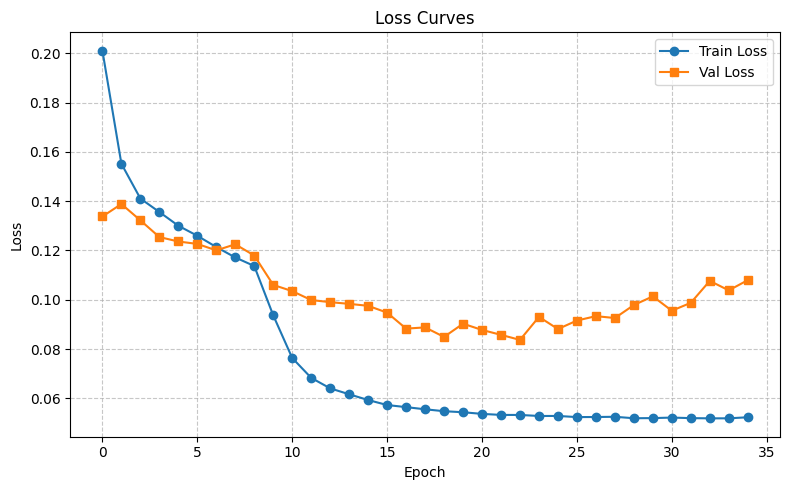

Training finished. Check /kaggle/working for best_model.pth, losses.png, label_distribution_*.png


In [1]:
import os, gc, time, copy, glob, logging, warnings
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler, ConcatDataset
from torchvision import transforms
from torchvision.models import resnet50
from torchvision.models import efficientnet_b3
from PIL import Image
from sklearn.metrics import f1_score, average_precision_score, classification_report
from torch.cuda.amp import autocast, GradScaler
from torchvision.transforms import ToPILImage

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# ----- Config -----
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DATA_PATH = '/kaggle/input/aid-multilabel/AID_multilabel/'
CSV_PATH = os.path.join(DATA_PATH, 'multilabel.csv')
# ======= GỘP NHÃN TƯƠNG TỰ =======
# print("Đang xử lý gộp nhãn...")
# Đọc file gốc
df_labels = pd.read_csv(CSV_PATH)
first_col = df_labels.columns[0]
df_labels = df_labels.rename(columns={first_col: 'image_name'})

TRAIN_IMG_DIR = os.path.join(DATA_PATH, 'images/images_tr')
TEST_IMG_DIR = os.path.join(DATA_PATH, 'images/images_test')
L = 15 # loại bỏ mobile-home, chaparral, xử lý water, land 
K = 512
IMG_SIZE = 224
BATCH_SIZE = 16  # Giảm để tránh memory error
EPOCHS = 50
LR = 1e-4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True
UNFREEZE_LAST_AT = 3
UNFREEZE_ALL_AT = 10
USE_LOSS = 'asl'
CLIP = 0.15
GAMMA_POS = 0.0
GAMMA_NEG = 1.0  # Giảm để tăng precision
PATIENCE = 10
MAX_TRAIN_SAMPLES = 15000 # Giảm để tiết kiệm thời gian
DEBUG = False
print("Config ready. Device:", DEVICE)

# ----- Transforms -----
# transform_train = transforms.Compose([
#     transforms.Resize((IMG_SIZE, IMG_SIZE)),
#     transforms.RandomHorizontalFlip(p=0.5),
#     transforms.RandomRotation(15),
#     transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=5),
#     transforms.ToTensor(),
#     transforms.GaussianBlur(3, sigma=(0.1, 2.0)),
#     transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225])
# ])
transform_train = transforms.Compose([
    # 1️⃣ Resize ảnh về kích thước chuẩn
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    
    # 2️⃣ Lật ngang mô phỏng thay đổi hướng quan sát
    transforms.RandomHorizontalFlip(p=0.5),
    
    # 3️⃣ Xoay nhẹ ảnh, vẫn giữ bố cục
    transforms.RandomRotation(degrees=10),
    
    # 4️⃣ Thay đổi ánh sáng và màu sắc, giữ nguyên hình dạng
    transforms.ColorJitter(
        brightness=0.2, 
        contrast=0.2, 
        saturation=0.2, 
        hue=0.05
    ),
    
    # 5️⃣ Thêm noise nhẹ để tăng độ bền với nhiễu cảm biến
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    
    # 6️⃣ Chuyển sang tensor và chuẩn hóa theo ImageNet
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

transform_val = transform_test = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ----- Dataset -----
class MultilabelDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None, drop_labels=['mobile-home', 'chaparral']):
        self.labels_df = pd.read_csv(csv_file)
        first_col = self.labels_df.columns[0]
        self.labels_df = self.labels_df.rename(columns={first_col: 'image_name'})
        self.img_dir = img_dir
        self.transform = transform
        label_cols = self.labels_df.columns[1:].tolist()
        for drop_label in drop_labels:
            if drop_label in label_cols:
                label_cols.remove(drop_label)
        self.label_columns = label_cols
        assert len(self.label_columns) == L
        available_files = set()
        for pattern in ['**/*.tif', '**/*.jpg', '**/*.png']:
            for f in glob.glob(os.path.join(img_dir, pattern), recursive=True):
                base = os.path.basename(f).rsplit('.',1)[0].lower()
                available_files.add(base)
        self.labels_df['image_name_lower'] = self.labels_df['image_name'].str.lower()
        self.labels_df = self.labels_df[self.labels_df['image_name_lower'].isin(available_files)].reset_index(drop=True)
        self.labels_df = self.labels_df.drop(columns=['image_name_lower'])

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        img_basename = row['image_name']
        base_lower = str(img_basename).lower()
        found = None
        for ext in ['tif', 'jpg', 'png']:
            candidates = glob.glob(os.path.join(self.img_dir, f'**/{base_lower}.{ext}'), recursive=True)
            if candidates:
                found = candidates[0]
                break
        img = Image.open(found).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        labels = torch.tensor(row[self.label_columns].values.astype(np.float32))
        return img, labels, img_basename

# ----- Weighted Sampler -----
def build_weighted_sampler(dataset):
    labels_all = []
    for _, labels, _ in dataset:
        labels_all.append(labels.numpy())
    labels_all = np.vstack(labels_all)
    pos_counts = labels_all.sum(axis=0)
    pos_counts = np.maximum(pos_counts, 1.0)
    class_weights = 1.0 / pos_counts
    # Tăng trọng số cho nhãn hiếm hơn
    sample_weights = np.mean([labels_all[:, i] * (class_weights[i] * 1.5) if pos_counts[i] < 500 else labels_all[:, i] * class_weights[i] for i in range(labels_all.shape[1])], axis=0)
    sample_weights = np.where(sample_weights == 0, class_weights.mean(), sample_weights)
    return WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ----- ASL with Label Smoothing -----
class AsymmetricLossMultiLabel(nn.Module):
    def __init__(self, gamma_pos=0.0, gamma_neg=1.0, clip=0.15, class_weights=None):
        super().__init__()
        self.gamma_pos = gamma_pos
        self.gamma_neg = gamma_neg
        self.clip = clip
        self.class_weights = class_weights

    def forward(self, logits, targets):
        targets_smooth = targets * 0.9 + 0.05
        probs = torch.sigmoid(logits)
        loss = F.binary_cross_entropy_with_logits(logits, targets_smooth, reduction='none')
        pt = probs * targets + (1 - probs) * (1 - targets)
        gamma = self.gamma_pos * targets + self.gamma_neg * (1 - targets)
        focal_factor = (1 - pt) ** gamma
        if self.clip is not None and self.clip > 0:
            neg_probs = (1 - probs)
            clipped_neg_probs = (neg_probs + self.clip).clamp(max=1)
            pt_neg = probs * targets + clipped_neg_probs * (1 - targets)
            focal_factor = (1 - pt_neg) ** gamma
        if self.class_weights is not None:
            loss = loss * self.class_weights.to(logits.device)
        return (focal_factor * loss).mean()

# # ----- Model -----
# class SpatialTransformer(nn.Module):
#     def __init__(self, L, K, output_size):
#         super().__init__()
#         self.L = L
#         self.K = K
#         theta_init = torch.zeros(L, 2, 3)
#         theta_init[:,0,0] = 1.0
#         theta_init[:,1,1] = 1.0
#         self.theta = nn.Parameter(theta_init)

#     def forward(self, x):
#         B = x.shape[0]
#         out = []
#         grids = []
#         for l in range(self.L):
#             theta_l = self.theta[l].unsqueeze(0).repeat(B,1,1).to(x.device)
#             grid = F.affine_grid(theta_l, torch.Size([B, x.shape[2], x.shape[3], x.shape[4]]), align_corners=False)
#             x_slice = x[:, l]
#             attn_x = F.grid_sample(x_slice, grid, mode='bilinear', align_corners=False, padding_mode='zeros')
#             out.append(attn_x)
#             grids.append(grid)
#         attn = torch.stack(out, dim=1)
#         return attn, grids
# # ----- MGP Block -----
# class MGPBlock(nn.Module):
    # """
    # Multi-Granularity Perception module
    # Kết hợp đặc trưng global, medium và local để tăng tính đa tỉ lệ.
    # """
    # def __init__(self, in_channels, out_channels):
    #     super().__init__()
    #     # Branch 1: Global context (1x1 conv)
    #     self.branch1 = nn.Sequential(
    #         nn.Conv2d(in_channels, out_channels, kernel_size=1),
    #         nn.BatchNorm2d(out_channels),
    #         nn.ReLU(inplace=True)
    #     )
    #     # Branch 2: Medium context (3x3 conv)
    #     self.branch2 = nn.Sequential(
    #         nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
    #         nn.BatchNorm2d(out_channels),
    #         nn.ReLU(inplace=True)
    #     )
    #     # Branch 3: Local context (5x5 conv)
    #     self.branch3 = nn.Sequential(
    #         nn.Conv2d(in_channels, out_channels, kernel_size=5, padding=2),
    #         nn.BatchNorm2d(out_channels),
    #         nn.ReLU(inplace=True)
    #     )
    #     # Hợp nhất 3 nhánh
    #     self.merge = nn.Conv2d(out_channels * 3, out_channels, kernel_size=1)

    # def forward(self, x):
    #     g = self.branch1(x)
    #     m = self.branch2(x)
    #     l = self.branch3(x)
    #     fused = torch.cat([g, m, l], dim=1)
    #     return self.merge(fused)

# # ----- Model with MGP -----
# class AttentionALRNCNN(nn.Module):
#     def __init__(self, num_classes=L, feature_size=7):
#         super().__init__()
#         resnet = resnet50(pretrained=True)
#         self.backbone = nn.Sequential(*list(resnet.children())[:-2])
#         self.feature_channels = 2048
#         self.num_classes = num_classes
#         self.K = K

#         # 🌟 Thêm MGP ngay sau backbone
#         self.mgp = MGPBlock(self.feature_channels, self.feature_channels)

#         self.label_wise_conv = nn.Conv2d(self.feature_channels, K * num_classes, kernel_size=1)
#         self.stn = SpatialTransformer(num_classes, K, feature_size)
#         self.pairwise_conv = nn.Conv2d(2 * K, K, kernel_size=1)
#         self.gap = nn.AdaptiveAvgPool2d(1)
#         self.mlp = nn.Sequential(
#             nn.Linear(K, 512),
#             nn.ReLU(),
#             nn.Dropout(0.7),
#             nn.Linear(512, 1)
#         )

    # def forward(self, x):
    #     B = x.shape[0]
    #     # 1️⃣ Trích đặc trưng bằng backbone
    #     features = self.backbone(x)

    #     # 2️⃣ Multi-Granularity Perception
    #     features = self.mgp(features)

    #     # 3️⃣ Label-wise attention
    #     lf = self.label_wise_conv(features)
    #     lf = lf.view(B, self.num_classes, self.K, lf.shape[2], lf.shape[3])
    #     attn, grids = self.stn(lf)

    #     # 4️⃣ Relation reasoning
    #     logits = []
    #     for l in range(self.num_classes):
    #         A_l = attn[:, l]
    #         rels = []
    #         for m in range(self.num_classes):
    #             if m == l: continue
    #             A_m = attn[:, m]
    #             concat = torch.cat([A_l, A_m], dim=1)
    #             pairwise = self.pairwise_conv(concat)
    #             pooled = self.gap(pairwise).view(B, -1)
    #             out = self.mlp(pooled)
    #             rels.append(out)
    #         sum_rels = torch.sum(torch.stack(rels, dim=0), dim=0).squeeze(-1) if len(rels) > 0 else torch.zeros(B, device=A_l.device)
    #         logits.append(sum_rels)
    #     return torch.stack(logits, dim=1), attn, grids
# # ----- MGP Block (thay thế phần cũ) -----
# class MGPBlock(nn.Module):
#     """
#     Multi-Granularity Perception module
#     - Branches: 1x1 (global), 3x3 (medium), 5x5 (local)
#     - Sau mỗi conv có BatchNorm + ReLU để ổn định
#     - Sau khi concat, giảm kênh bằng 1x1 conv, thêm BatchNorm + ReLU và residual
#     """
#     def __init__(self, in_channels, out_channels):
    #     super().__init__()
    #     # Branch 1: Global context (1x1 conv)
    #     self.branch1 = nn.Sequential(
    #         nn.Conv2d(in_channels, out_channels, kernel_size=1),
    #         nn.BatchNorm2d(out_channels),
    #         nn.ReLU(inplace=True)
    #     )
    #     # Branch 2: Medium context (3x3 conv)
    #     self.branch2 = nn.Sequential(
    #         nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
    #         nn.BatchNorm2d(out_channels),
    #         nn.ReLU(inplace=True)
    #     )
    #     # Branch 3: Local context (5x5 conv)
    #     self.branch3 = nn.Sequential(
    #         nn.Conv2d(in_channels, out_channels, kernel_size=5, padding=2),
    #         nn.BatchNorm2d(out_channels),
    #         nn.ReLU(inplace=True)
    #     )
    #     # Hợp nhất 3 nhánh -> giảm về out_channels
    #     self.merge = nn.Sequential(
    #         nn.Conv2d(out_channels * 3, out_channels, kernel_size=1),
    #         nn.BatchNorm2d(out_channels),
    #         nn.ReLU(inplace=True)
    #     )

    # def forward(self, x):
    #     g = self.branch1(x)
    #     m = self.branch2(x)
    #     l = self.branch3(x)
    #     fused = torch.cat([g, m, l], dim=1)
    #     out = self.merge(fused)
    #     # residual: nếu in_channels == out_channels thì cộng trực tiếp, nếu khác thì không
    #     if x.shape[1] == out.shape[1]:
    #         out = out + x
    #     return out


# # ----- SpatialTransformer (giữ nguyên hoặc thay thế nếu bạn đã có) -----
# class SpatialTransformer(nn.Module):
#     def __init__(self, L, K, output_size):
#         super().__init__()
#         self.L = L
#         self.K = K
#         theta_init = torch.zeros(L, 2, 3)
#         theta_init[:,0,0] = 1.0
#         theta_init[:,1,1] = 1.0
#         self.theta = nn.Parameter(theta_init)

    # def forward(self, x):
    #     # x: [B, L, K, H, W]
    #     B = x.shape[0]
    #     out = []
    #     grids = []
    #     for l in range(self.L):
    #         theta_l = self.theta[l].unsqueeze(0).repeat(B,1,1).to(x.device)
    #         # size positional arg for compatibility
    #         size = torch.Size([B, x.shape[2], x.shape[3], x.shape[4]])
    #         grid = F.affine_grid(theta_l, size, align_corners=False)
    #         x_slice = x[:, l]
    #         attn_x = F.grid_sample(x_slice, grid, mode='bilinear', align_corners=False, padding_mode='zeros')
    #         out.append(attn_x)
    #         grids.append(grid)
    #     attn = torch.stack(out, dim=1)  # [B, L, K, outH, outW]
    #     return attn, grids


# # ----- Model with MGP placed BEFORE label-wise conv -----
# class AttentionALRNCNN(nn.Module):
#     def __init__(self, num_classes=L, feature_size=7):
#         super().__init__()
#         # load resnet50 backbone (chiếm child list tới conv layer cuối)
#         resnet = resnet50(pretrained=True)
#         # dùng đến -2 children như bạn trước đó => feature map channels = 2048
#         self.backbone = nn.Sequential(*list(resnet.children())[:-2])
#         self.feature_channels = 2048
#         self.num_classes = num_classes
#         self.K = K

#         # 🌟 MGP ngay sau backbone (input=2048, giữ output=2048)
#         self.mgp = MGPBlock(self.feature_channels, self.feature_channels)

#         # Sau MGP: label-wise conv (map 2048 -> K * num_classes)
#         self.label_wise_conv = nn.Conv2d(self.feature_channels, K * num_classes, kernel_size=1)

#         # STN & relation heads (giữ nguyên logic trước)
#         self.stn = SpatialTransformer(num_classes, K, feature_size)
#         self.pairwise_conv = nn.Conv2d(2 * K, K, kernel_size=1)
#         self.gap = nn.AdaptiveAvgPool2d(1)
#         self.mlp = nn.Sequential(
#             nn.Linear(K, 512),
#             nn.ReLU(),
#             nn.Dropout(0.7),
#             nn.Linear(512, 1)
#         )

    # def forward(self, x):
    #     B = x.shape[0]
    #     # 1) Backbone
    #     features = self.backbone(x)                   # [B, 2048, H, W] (H,W ~ 7 or 14 depending backbone)
    #     # 2) MGP (multi-grain perception)
    #     features = self.mgp(features)                 # [B, 2048, H, W]
    #     # 3) Label-wise conv -> reshape thành per-label feature maps
    #     lf = self.label_wise_conv(features)           # [B, L*K, H, W]
    #     _, _, Hf, Wf = lf.shape
    #     lf = lf.view(B, self.num_classes, self.K, Hf, Wf)
    #     # 4) STN: tạo attention crops/features
    #     attn, grids = self.stn(lf)                    # attn: [B, L, K, outH, outW]
    #     # 5) Relation reasoning (pairwise)
    #     logits = []
    #     for l in range(self.num_classes):
    #         A_l = attn[:, l]  # [B, K, outH, outW]
    #         rels = []
    #         for m in range(self.num_classes):
    #             if m == l:
    #                 continue
    #             A_m = attn[:, m]
    #             concat = torch.cat([A_l, A_m], dim=1)  # [B, 2K, outH, outW]
    #             pairwise = self.pairwise_conv(concat)  # [B, K, outH, outW]
    #             pooled = self.gap(pairwise).view(B, -1) # [B, K]
    #             out = self.mlp(pooled)                  # [B, 1]
    #             rels.append(out)
    #         if len(rels) > 0:
    #             sum_rels = torch.sum(torch.stack(rels, dim=0), dim=0).squeeze(-1)
    #         else:
    #             sum_rels = torch.zeros(B, device=A_l.device)
    #         logits.append(sum_rels)
    #     logits = torch.stack(logits, dim=1)  # [B, L]
    #     return logits, attn, grids
# ----- Spatial Transformer giữ nguyên -----
class SpatialTransformer(nn.Module):
    def __init__(self, L, K, output_size):
        super().__init__()
        self.L = L
        self.K = K
        theta_init = torch.zeros(L, 2, 3)
        theta_init[:,0,0] = 1.0
        theta_init[:,1,1] = 1.0
        self.theta = nn.Parameter(theta_init)

    def forward(self, x):
        B = x.shape[0]
        out = []
        grids = []
        for l in range(self.L):
            theta_l = self.theta[l].unsqueeze(0).repeat(B,1,1).to(x.device)
            size = torch.Size([B, x.shape[2], x.shape[3], x.shape[4]])
            grid = F.affine_grid(theta_l, size, align_corners=False)
            x_slice = x[:, l]
            attn_x = F.grid_sample(x_slice, grid, mode='bilinear', align_corners=False, padding_mode='zeros')
            out.append(attn_x)
            grids.append(grid)
        attn = torch.stack(out, dim=1)  # [B, L, K, H, W]
        return attn, grids


# ----- Model chính với EfficientNet backbone -----
class AttentionALRNCNN(nn.Module):
    def __init__(self, num_classes, K=8, feature_size=7):
        super().__init__()
        self.num_classes = num_classes
        self.K = K

        # 1️⃣ EfficientNet backbone
        # backbone = efficientnet_b0(pretrained=True)
        backbone = efficientnet_b3(pretrained=True)
        self.backbone = backbone.features
        self.feature_channels = backbone.classifier[1].in_features  # 1280 cho B0

        # 2️⃣ Label-wise Conv (map 1280 -> K*num_classes)
        self.label_wise_conv = nn.Conv2d(self.feature_channels, K * num_classes, kernel_size=1)

        # 3️⃣ STN
        self.stn = SpatialTransformer(num_classes, K, feature_size)

        # 4️⃣ Relation reasoning
        self.pairwise_conv = nn.Conv2d(2 * K, K, kernel_size=1)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(K, 512),
            nn.ReLU(),
            nn.Dropout(0.7),
            nn.Linear(512, 1)
        )

    def forward(self, x):
        B = x.shape[0]
        # (1) Backbone
        features = self.backbone(x)  # [B, 1280, H, W]
        # (2) Label-wise conv
        lf = self.label_wise_conv(features)  # [B, L*K, H, W]
        _, _, Hf, Wf = lf.shape
        lf = lf.view(B, self.num_classes, self.K, Hf, Wf)
        # (3) STN
        attn, grids = self.stn(lf)
        # (4) Relation reasoning
        logits = []
        for l in range(self.num_classes):
            A_l = attn[:, l]
            rels = []
            for m in range(self.num_classes):
                if m == l:
                    continue
                A_m = attn[:, m]
                concat = torch.cat([A_l, A_m], dim=1)
                pairwise = self.pairwise_conv(concat)
                pooled = self.gap(pairwise).view(B, -1)
                out = self.mlp(pooled)
                rels.append(out)
            sum_rels = torch.sum(torch.stack(rels, dim=0), dim=0).squeeze(-1)
            logits.append(sum_rels)
        logits = torch.stack(logits, dim=1)
        return logits, attn, grids


# ----- Prepare Data -----
# ----- Chuẩn hóa biến và cấu trúc -----

# Dataset gốc (đã có nhãn và đường dẫn hợp lệ)
full_dataset = MultilabelDataset(CSV_PATH, TRAIN_IMG_DIR, transform=transform_train)
test_dataset = MultilabelDataset(CSV_PATH, TEST_IMG_DIR, transform=transform_test)

# Chia train / val (80/20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size],
                                          generator=torch.Generator().manual_seed(SEED))

# Lấy danh sách nhãn gốc (từ dataset chính)
label_columns = full_dataset.label_columns

# --- Tính phân phối ban đầu ---
def get_label_distribution(dataset, label_columns):
    labels_all = []
    for _, labels, _ in dataset:
        labels_all.append(labels.numpy())
    labels_all = np.vstack(labels_all)
    return pd.Series(labels_all.sum(axis=0), index=label_columns)

train_dist = get_label_distribution(train_dataset, label_columns)
val_dist = get_label_distribution(val_dataset, label_columns)
print("Phân phối nhãn Train:")
print(train_dist)

# --- Oversampling cho nhãn hiếm ---
positive_counts = train_dist
rare_labels = [label for label, count in positive_counts.items() if count < 350]
print("Nhãn hiếm:", rare_labels)

def augment_rare_samples(dataset, rare_labels, positive_counts):
    aug_data = []
    to_pil = ToPILImage()
    for idx in range(len(dataset)):
        img, labels, img_name = dataset[idx]
        for label_idx, label in enumerate(dataset.dataset.label_columns):
            if labels[label_idx] == 1 and label in rare_labels:
                img_pil = to_pil(img)
                num_aug = 35 if positive_counts[label] < 100 else (30 if positive_counts[label] < 250 else 0)
                for i in range(num_aug):
                    aug_img = transform_train(img_pil)
                    aug_data.append((aug_img, labels, f"{img_name}_aug_{label}_{i}"))
    return aug_data

aug_samples = augment_rare_samples(train_dataset, rare_labels, positive_counts)
print(f"Đã tạo thêm {len(aug_samples)} mẫu tăng cường.")

# ✅ Gộp train_dataset gốc và các mẫu augment
# Chuyển list -> Dataset tạm
class AugmentedDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        return self.samples[idx]

aug_dataset = AugmentedDataset(aug_samples)
train_dataset_full = ConcatDataset([train_dataset, aug_dataset])

# ✅ Lưu lại label_columns để dùng sau
train_dataset_full.label_columns = label_columns

# Giới hạn nếu quá nhiều mẫu
if len(train_dataset_full) > MAX_TRAIN_SAMPLES:
    indices = np.random.choice(len(train_dataset_full), MAX_TRAIN_SAMPLES, replace=False)
    train_dataset_full = torch.utils.data.Subset(train_dataset_full, indices)

# Weighted sampler
sampler = build_weighted_sampler(train_dataset_full)

train_loader = DataLoader(train_dataset_full, batch_size=BATCH_SIZE, sampler=sampler, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

# --- Kiểm tra phân phối sau oversampling ---
aug_labels = []
for img, labels, _ in train_dataset_full:
    aug_labels.append(labels.numpy())
aug_labels = np.vstack(aug_labels)
aug_counts = aug_labels.sum(axis=0)

plt.figure(figsize=(12, 5))
plt.bar(label_columns, aug_counts)
plt.xticks(rotation=45, ha="right")
plt.title("Phân Phối Nhãn Train Sau Oversampling")
plt.tight_layout()
plt.savefig('/kaggle/working/label_distribution_train_oversampled.png')
plt.show()

print(f"Train: {len(train_dataset_full)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# ----- So sánh Phân Phối Train/Val/Test -----
print("So sánh phân phối nhãn giữa Train, Val, và Test...")

# Hàm tính phân phối nhãn từ dataset
def get_label_distribution(dataset, label_columns):
    labels_all = []
    for _, labels, _ in dataset:
        labels_all.append(labels.numpy())
    labels_all = np.vstack(labels_all)
    return pd.Series(labels_all.sum(axis=0), index=label_columns)

# Lấy label_columns từ dataset gốc
label_columns = train_dataset_full.dataset.label_columns

# Tính phân phối cho từng tập
train_dist = get_label_distribution(train_dataset, label_columns)
val_dist = get_label_distribution(val_dataset, label_columns)
test_dist = get_label_distribution(test_dataset, label_columns)

# Tạo DataFrame để so sánh
dist_df = pd.DataFrame({
    'Train': train_dist,
    'Validation': val_dist,
    'Test': test_dist
})

# In bảng phân phối
print("\nPhân phối nhãn (số positive samples):")
print(dist_df)

# Vẽ biểu đồ so sánh
plt.figure(figsize=(12, 6))
dist_df.plot(kind='bar', width=0.8)
plt.title("Phân Phối Nhãn giữa Train, Validation, và Test")
plt.xlabel("Nhãn")
plt.ylabel("Số Lượng Positive Samples")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('/kaggle/working/label_distribution_comparison.png')
plt.show()

# Tính tỷ lệ positive samples so với tổng số mẫu trong từng tập
total_train = len(train_dataset)
total_val = len(val_dataset)
total_test = len(test_dataset)
dist_df_percent = dist_df.div([total_train, total_val, total_test], axis=1) * 100
print("\nTỷ lệ positive samples (%):")
print(dist_df_percent.round(2))

# ----- Train -----
def evaluate_metrics(model, loader, label_columns, device=DEVICE, split='Validation'):
    model.eval()
    all_labels, all_outputs = [], []
    try:
        with torch.no_grad():
            for images, labels, _ in loader:
                images = images.to(device)
                labels = labels.cpu().numpy()
                outputs, _, _ = model(images)
                outputs = torch.sigmoid(outputs).cpu().numpy()
                all_labels.append(labels)
                all_outputs.append(outputs)
    except Exception as e:
        print(f"Error in {split} DataLoader: {e}")
        return 0.0, 0.0, 0.0, np.zeros(len(label_columns))
    
    all_labels = np.vstack(all_labels).astype(int)
    all_outputs = np.vstack(all_outputs)
    
    thresholds = np.zeros(all_outputs.shape[1])
    for i in range(all_outputs.shape[1]):
        best_f1, best_thresh = 0, 0.5
        for thresh in np.linspace(0.05, 0.95, 19):
            preds = (all_outputs[:, i] >= thresh).astype(int)
            f1 = f1_score(all_labels[:, i], preds, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh
        thresholds[i] = best_thresh
    
    preds = np.zeros_like(all_outputs)
    for i in range(all_outputs.shape[1]):
        preds[:, i] = (all_outputs[:, i] >= thresholds[i]).astype(int)
    
    f1_micro = f1_score(all_labels, preds, average='micro')
    f1_macro = f1_score(all_labels, preds, average='macro')
    mAP = average_precision_score(all_labels, all_outputs, average='macro')
    f1_per_class = f1_score(all_labels, preds, average=None)
    
    print(f"\n--- {split} Classification Report ---")
    print(classification_report(all_labels, preds, target_names=label_columns, zero_division=0))
    
    for i, label in enumerate(label_columns):
        print(f"{label}: F1={f1_per_class[i]:.4f}, Threshold={thresholds[i]:.4f}")
    
    return f1_micro, f1_macro, mAP, thresholds

model = AttentionALRNCNN(num_classes=L, feature_size=7).to(DEVICE)
for p in model.backbone.parameters():
    p.requires_grad = False
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, verbose=True)
scaler = GradScaler()
pos_counts = train_dist  # Sử dụng phân phối từ train_dist
class_weights = 1.0 / pos_counts
class_weights = class_weights / class_weights.sum() * len(class_weights)  # Chuẩn hóa
criterion = AsymmetricLossMultiLabel(gamma_pos=GAMMA_POS, gamma_neg=GAMMA_NEG, clip=CLIP, class_weights=torch.tensor(class_weights)).to(DEVICE)
# criterion = AsymmetricLossMultiLabel(gamma_pos=GAMMA_POS, gamma_neg=GAMMA_NEG, clip=CLIP).to(DEVICE)
best_val_f1_macro = 0.0
epochs_no_improve = 0
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    gc.collect()
    torch.cuda.empty_cache()
    epoch_start = time.time()
    if epoch + 1 == UNFREEZE_LAST_AT:
        print(f"Unfreezing last backbone block at epoch {epoch+1}")
        for name, module in model.backbone.named_children():
            if name == 'layer4':
                for p in module.parameters():
                    p.requires_grad = True
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=2e-4)
    if epoch + 1 == UNFREEZE_ALL_AT:
        print(f"Unfreezing entire backbone at epoch {epoch+1}")
        for p in model.backbone.parameters():
            p.requires_grad = True
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR/5.0, weight_decay=2e-4)

    model.train()
    running_loss = 0.0
    loop = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{EPOCHS} - train", leave=False)
    try:
        for batch_idx, (images, labels, _) in loop:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            with autocast():
                outputs, _, _ = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(filter(lambda p: p.requires_grad, model.parameters()), max_norm=2.0)
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item() * images.size(0)
    
            # Kiểm tra phân phối trong batch đầu tiên của mỗi epoch
            if batch_idx == 0:  # Chỉ in cho batch đầu tiên
                batch_labels = labels.cpu().numpy()  # Lấy nhãn từ batch
                batch_size = batch_labels.shape[0]
                batch_dist = np.mean(batch_labels, axis=0)  # Tính tỷ lệ positive samples
                batch_dist_dict = dict(zip(train_dataset_full.dataset.label_columns, batch_dist.round(2)))  # Sử dụng label_columns từ full_train_dataset
                print(f"Epoch {epoch+1} - Phân phối nhãn trong batch đầu tiên: {batch_dist_dict}")
    
    except Exception as e:
        print(f"Error in training loop: {e}")
        continue
    
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    val_loss_total = 0.0
    try:
        with torch.no_grad():
            for images, labels, _ in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                with autocast():
                    outputs, _, _ = model(images)
                    loss = criterion(outputs, labels)
                val_loss_total += loss.item() * images.size(0)
    except Exception as e:
        print(f"Error in validation loop: {e}")
        continue
    
    epoch_val_loss = val_loss_total / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    f1_micro, f1_macro, mAP, thresholds = evaluate_metrics(model, val_loader, train_dataset_full.dataset.label_columns, DEVICE, split='Validation')
    epoch_time = time.time() - epoch_start
    print(f"\nEpoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_train_loss:.6f} Val Loss: {epoch_val_loss:.6f} "
          f"| F1-micro: {f1_micro:.4f} F1-macro: {f1_macro:.4f} mAP: {mAP:.4f} | Time: {epoch_time:.2f}s | Thresholds: {thresholds[:5]}...")

    scheduler.step(f1_macro)
    if f1_macro > best_val_f1_macro:
        best_val_f1_macro = f1_macro
        epochs_no_improve = 0
        torch.save({'epoch': epoch+1, 'model_state': model.state_dict(), 'thresholds': thresholds}, '/kaggle/working/best_imblanced_model.pth')
        print("Saved best model.")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Final Test Evaluation
print("\n=== Final Test Results ===")
f1_micro, f1_macro, mAP, thresholds = evaluate_metrics(model, test_loader, train_dataset_full.dataset.label_columns, DEVICE, split='Test')
print(f"F1-micro: {f1_micro:.4f}, F1-macro: {f1_macro:.4f}, mAP: {mAP:.4f}")

# Plot Losses
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.title("Loss Curves")
plt.tight_layout()
plt.savefig('/kaggle/working/losses.png')
plt.show()

print("Training finished. Check /kaggle/working for best_model.pth, losses.png, label_distribution_*.png")

Config ready. Device: cuda
Preparing datasets...


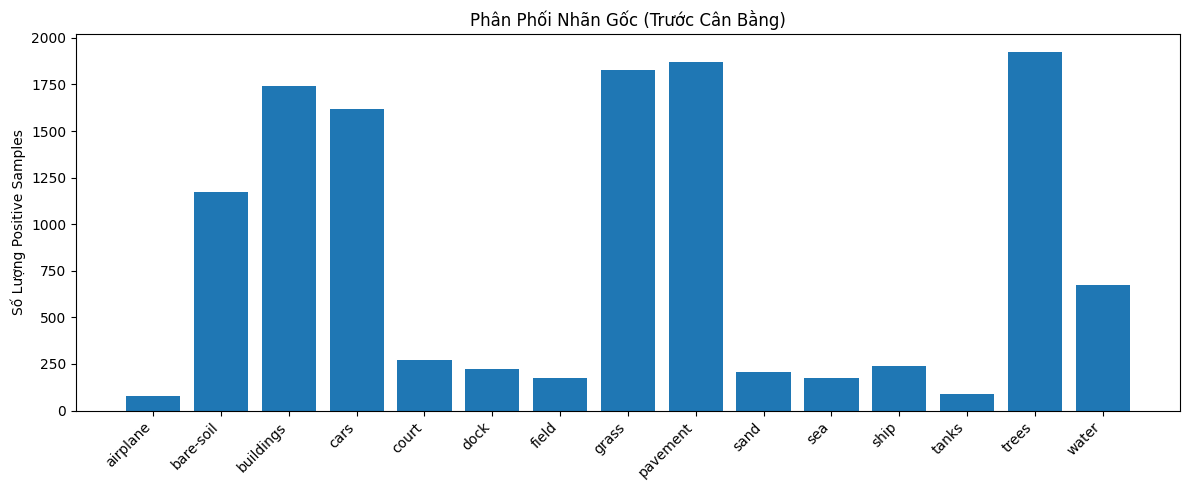

Nhãn hiếm (<350 samples): ['airplane', 'court', 'dock', 'field', 'sand', 'sea', 'ship', 'tanks']


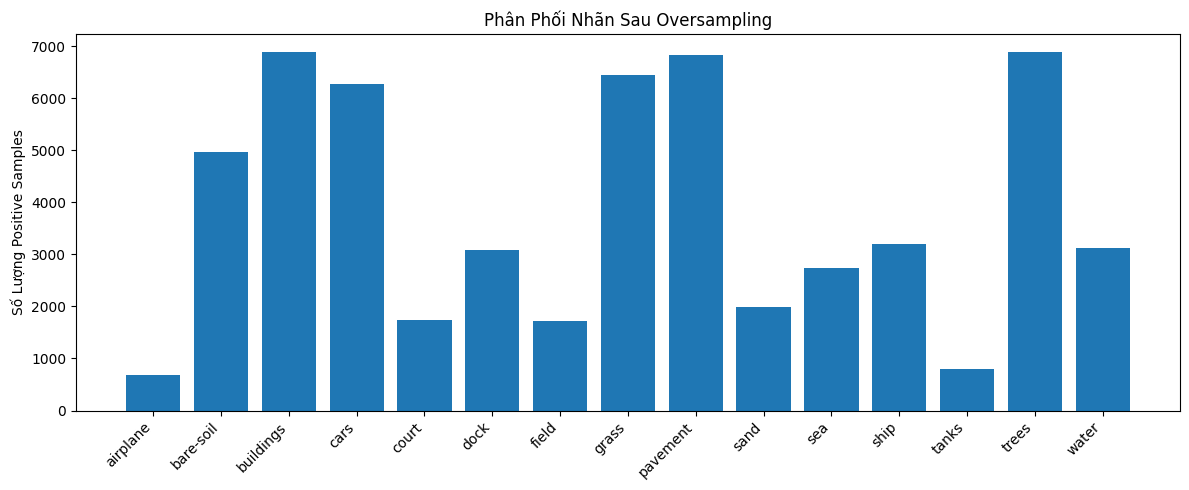

Train 6750, Val 2250, Test 600
So sánh phân phối nhãn giữa Train, Val, và Test...

Phân phối nhãn (số positive samples):
            Train  Validation   Test
airplane    520.0       168.0   20.0
bare-soil  3730.0      1245.0  304.0
buildings  5160.0      1734.0  417.0
cars       4703.0      1569.0  409.0
court      1287.0       461.0   75.0
dock       2315.0       764.0   50.0
field      1292.0       426.0   39.0
grass      4805.0      1640.0  466.0
pavement   5109.0      1719.0  458.0
sand       1497.0       492.0   52.0
sea        2061.0       672.0   44.0
ship       2408.0       785.0   47.0
tanks       594.0       197.0   21.0
trees      5129.0      1754.0  483.0
water      2358.0       773.0  178.0


<Figure size 1200x600 with 0 Axes>

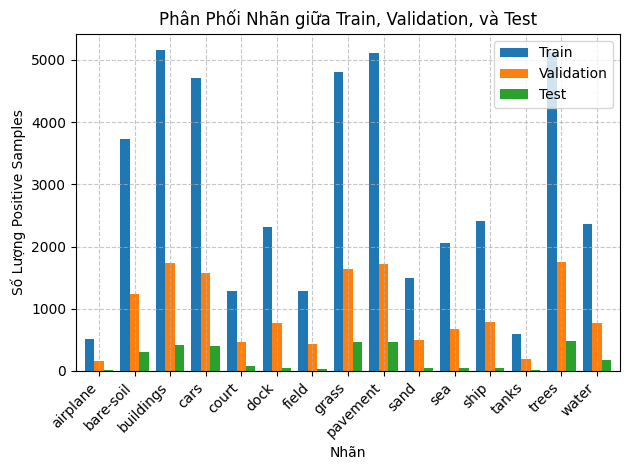


Tỷ lệ positive samples (%):
           Train  Validation   Test
airplane    7.70        7.47   3.33
bare-soil  55.26       55.33  50.67
buildings  76.44       77.07  69.50
cars       69.67       69.73  68.17
court      19.07       20.49  12.50
dock       34.30       33.96   8.33
field      19.14       18.93   6.50
grass      71.19       72.89  77.67
pavement   75.69       76.40  76.33
sand       22.18       21.87   8.67
sea        30.53       29.87   7.33
ship       35.67       34.89   7.83
tanks       8.80        8.76   3.50
trees      75.99       77.96  80.50
water      34.93       34.36  29.67


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth
100%|██████████| 47.2M/47.2M [00:01<00:00, 27.2MB/s]


Epoch 1/50 - train:   0%|          | 0/422 [00:00<?, ?it/s]

Epoch 1 - Phân phối nhãn trong batch đầu tiên: {'airplane': 0.0, 'bare-soil': 0.75, 'buildings': 0.88, 'cars': 0.94, 'court': 0.12, 'dock': 0.62, 'field': 0.06, 'grass': 1.0, 'pavement': 1.0, 'sand': 0.12, 'sea': 0.31, 'ship': 0.69, 'tanks': 0.06, 'trees': 0.94, 'water': 0.56}

--- Validation Classification Report ---
              precision    recall  f1-score   support

    airplane       0.68      0.65      0.66       168
   bare-soil       0.70      0.88      0.78      1245
   buildings       0.84      0.97      0.90      1734
        cars       0.79      0.95      0.86      1569
       court       0.57      0.70      0.63       461
        dock       0.64      0.82      0.72       764
       field       0.66      0.62      0.64       426
       grass       0.83      0.93      0.88      1640
    pavement       0.88      0.94      0.91      1719
        sand       0.59      0.76      0.67       492
         sea       0.75      0.77      0.76       672
        ship       0.66      0.

Epoch 2/50 - train:   0%|          | 0/422 [00:00<?, ?it/s]

...

Epoch 41 - Phân phối nhãn trong batch đầu tiên: {'airplane': 0.19, 'bare-soil': 0.69, 'buildings': 0.94, 'cars': 0.94, 'court': 0.25, 'dock': 0.5, 'field': 0.12, 'grass': 1.0, 'pavement': 1.0, 'sand': 0.12, 'sea': 0.25, 'ship': 0.5, 'tanks': 0.06, 'trees': 0.94, 'water': 0.38}

--- Validation Classification Report ---
              precision    recall  f1-score   support

    airplane       1.00      0.98      0.99       168
   bare-soil       0.96      0.97      0.97      1245
   buildings       0.98      0.99      0.99      1734
        cars       0.99      0.98      0.99      1569
       court       0.98      0.95      0.97       461
        dock       0.99      0.99      0.99       764
       field       1.00      0.98      0.99       426
       grass       0.99      0.99      0.99      1640
    pavement       0.99      0.99      0.99      1719
        sand       0.99      0.99      0.99       492
         sea       1.00      0.99      0.99       672
        ship       0.99      0.

Epoch 42/50 - train:   0%|          | 0/422 [00:00<?, ?it/s]

Epoch 42 - Phân phối nhãn trong batch đầu tiên: {'airplane': 0.06, 'bare-soil': 0.69, 'buildings': 0.88, 'cars': 0.94, 'court': 0.19, 'dock': 0.44, 'field': 0.12, 'grass': 0.88, 'pavement': 0.94, 'sand': 0.19, 'sea': 0.38, 'ship': 0.5, 'tanks': 0.06, 'trees': 1.0, 'water': 0.38}

--- Validation Classification Report ---
              precision    recall  f1-score   support

    airplane       0.99      0.99      0.99       168
   bare-soil       0.96      0.98      0.97      1245
   buildings       0.99      1.00      0.99      1734
        cars       0.99      0.99      0.99      1569
       court       0.98      0.97      0.97       461
        dock       0.98      0.99      0.99       764
       field       0.99      1.00      0.99       426
       grass       0.98      1.00      0.99      1640
    pavement       0.99      0.99      0.99      1719
        sand       1.00      0.98      0.99       492
         sea       1.00      0.99      0.99       672
        ship       0.99      

Epoch 43/50 - train:   0%|          | 0/422 [00:00<?, ?it/s]

Epoch 43 - Phân phối nhãn trong batch đầu tiên: {'airplane': 0.0, 'bare-soil': 0.56, 'buildings': 0.81, 'cars': 0.81, 'court': 0.12, 'dock': 0.56, 'field': 0.31, 'grass': 0.81, 'pavement': 0.81, 'sand': 0.06, 'sea': 0.25, 'ship': 0.62, 'tanks': 0.12, 'trees': 0.94, 'water': 0.56}


In [ ]:
import os, gc, time, copy, glob, logging, warnings
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler, ConcatDataset
from torchvision import transforms
from torchvision.models import resnet50
from torchvision.models import efficientnet_b3
from PIL import Image
from sklearn.metrics import f1_score, average_precision_score, classification_report
from torch.cuda.amp import autocast, GradScaler
from torchvision.transforms import ToPILImage

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# ----- Config -----
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DATA_PATH = '/kaggle/input/aid-multilabel/AID_multilabel/'
CSV_PATH = os.path.join(DATA_PATH, 'multilabel.csv')
# ======= GỘP NHÃN TƯƠNG TỰ =======
# print("Đang xử lý gộp nhãn...")
# Đọc file gốc
df_labels = pd.read_csv(CSV_PATH)
first_col = df_labels.columns[0]
df_labels = df_labels.rename(columns={first_col: 'image_name'})
# print("Phân phối nhãn trước xử lý:",df_labels.columns[1:].tolist())
# print(df_labels.drop(columns=['image_name']).sum().sort_values(ascending=False))
# Các nhóm nhãn cần gộp
# merge_map = {
#     'Water': ['sea', 'water'],
#     'land': ['bare-soil', 'sand', 'field']
# }

# Loại nhãn trước khi gộp (thêm pavement để đạt L=11)
# drop_labels = ['mobile-home', 'chaparral']  # Thêm 'pavement' để giảm từ 12 xuống 11
# for drop_label in drop_labels:
#     if drop_label in df_labels.columns:
#         df_labels = df_labels.drop(columns=[drop_label])

# # Thực hiện gộp nhãn
# for new_label, old_labels in merge_map.items():
#     existing_cols = [col for col in old_labels if col in df_labels.columns]
#     if not existing_cols:
#         print(f"⚠️ Cảnh báo: Không tìm thấy nhãn nào trong {old_labels} để gộp thành '{new_label}'.")
#         continue
#     if new_label in df_labels.columns:
#         print(f"⚠️ Cảnh báo: Nhãn '{new_label}' đã tồn tại, đổi thành '{new_label}_merged'.")
#         new_label = f"{new_label}_merged"
#     df_labels[new_label] = df_labels[existing_cols].max(axis=1)

# # Loại bỏ các cột cũ đã gộp
# cols_to_drop = [c for group in merge_map.values() for c in group if c in df_labels.columns]
# df_labels = df_labels.drop(columns=cols_to_drop)

# In phân phối trước/sau gộp để kiểm tra
# print("Phân phối nhãn sau xử lý:", df_labels.columns[1:].tolist())
# print(df_labels.drop(columns=['image_name']).sum().sort_values(ascending=False))

# # Ghi file CSV mới
# NEW_CSV_PATH = '/kaggle/working/multilabel_merged.csv'
# try:
#     df_labels.to_csv(NEW_CSV_PATH, index=False)
#     print(f"Gộp nhãn xong, lưu thành: {NEW_CSV_PATH}")
# except PermissionError as e:
#     print(f"❌ Lỗi ghi file: {e}. Vui lòng kiểm tra quyền truy cập /kaggle/working/.")
# except Exception as e:
#     print(f"❌ Lỗi không xác định khi ghi file: {e}.")

# # Cập nhật đường dẫn CSV dùng cho dataset
# CSV_PATH = NEW_CSV_PATH

# # Cập nhật L để khớp với số nhãn
# L = len(df_labels.columns) - 1  # Cập nhật L dựa trên số cột nhãn thực tế
# print(f"Số nhãn sau gộp (L): {L}")

TRAIN_IMG_DIR = os.path.join(DATA_PATH, 'images/images_tr')
TEST_IMG_DIR = os.path.join(DATA_PATH, 'images/images_test')
L = 15 # loại bỏ mobile-home, chaparral, xử lý water, land 
K = 512
IMG_SIZE = 224
BATCH_SIZE = 16  # Giảm để tránh memory error
EPOCHS = 50
LR = 1e-4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True
UNFREEZE_LAST_AT = 3
UNFREEZE_ALL_AT = 10
USE_LOSS = 'asl'
CLIP = 0.15
GAMMA_POS = 0.0
GAMMA_NEG = 1.0  # Giảm để tăng precision
PATIENCE = 10
MAX_TRAIN_SAMPLES = 9000  # Giảm để tiết kiệm thời gian
DEBUG = False
print("Config ready. Device:", DEVICE)

# ----- Transforms -----
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=5),
    transforms.ToTensor(),
    transforms.GaussianBlur(3, sigma=(0.1, 2.0)),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform_val = transform_test = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ----- Dataset -----
class MultilabelDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None, drop_labels=['mobile-home', 'chaparral']):
        self.labels_df = pd.read_csv(csv_file)
        first_col = self.labels_df.columns[0]
        self.labels_df = self.labels_df.rename(columns={first_col: 'image_name'})
        self.img_dir = img_dir
        self.transform = transform
        label_cols = self.labels_df.columns[1:].tolist()
        for drop_label in drop_labels:
            if drop_label in label_cols:
                label_cols.remove(drop_label)
        self.label_columns = label_cols
        assert len(self.label_columns) == L
        available_files = set()
        for pattern in ['**/*.tif', '**/*.jpg', '**/*.png']:
            for f in glob.glob(os.path.join(img_dir, pattern), recursive=True):
                base = os.path.basename(f).rsplit('.',1)[0].lower()
                available_files.add(base)
        self.labels_df['image_name_lower'] = self.labels_df['image_name'].str.lower()
        self.labels_df = self.labels_df[self.labels_df['image_name_lower'].isin(available_files)].reset_index(drop=True)
        self.labels_df = self.labels_df.drop(columns=['image_name_lower'])

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        img_basename = row['image_name']
        base_lower = str(img_basename).lower()
        found = None
        for ext in ['tif', 'jpg', 'png']:
            candidates = glob.glob(os.path.join(self.img_dir, f'**/{base_lower}.{ext}'), recursive=True)
            if candidates:
                found = candidates[0]
                break
        img = Image.open(found).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        labels = torch.tensor(row[self.label_columns].values.astype(np.float32))
        return img, labels, img_basename

# ----- Weighted Sampler -----
def build_weighted_sampler(dataset):
    labels_all = []
    for _, labels, _ in dataset:
        labels_all.append(labels.numpy())
    labels_all = np.vstack(labels_all)
    pos_counts = labels_all.sum(axis=0)
    pos_counts = np.maximum(pos_counts, 1.0)
    class_weights = 1.0 / pos_counts
    # Tăng trọng số cho nhãn hiếm hơn
    sample_weights = np.mean([labels_all[:, i] * (class_weights[i] * 1.5) if pos_counts[i] < 500 else labels_all[:, i] * class_weights[i] for i in range(labels_all.shape[1])], axis=0)
    sample_weights = np.where(sample_weights == 0, class_weights.mean(), sample_weights)
    return WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ----- ASL with Label Smoothing -----
class AsymmetricLossMultiLabel(nn.Module):
    def __init__(self, gamma_pos=0.0, gamma_neg=1.0, clip=0.15, class_weights=None):
        super().__init__()
        self.gamma_pos = gamma_pos
        self.gamma_neg = gamma_neg
        self.clip = clip
        self.class_weights = class_weights

    def forward(self, logits, targets):
        targets_smooth = targets * 0.9 + 0.05
        probs = torch.sigmoid(logits)
        loss = F.binary_cross_entropy_with_logits(logits, targets_smooth, reduction='none')
        pt = probs * targets + (1 - probs) * (1 - targets)
        gamma = self.gamma_pos * targets + self.gamma_neg * (1 - targets)
        focal_factor = (1 - pt) ** gamma
        if self.clip is not None and self.clip > 0:
            neg_probs = (1 - probs)
            clipped_neg_probs = (neg_probs + self.clip).clamp(max=1)
            pt_neg = probs * targets + clipped_neg_probs * (1 - targets)
            focal_factor = (1 - pt_neg) ** gamma
        if self.class_weights is not None:
            loss = loss * self.class_weights.to(logits.device)
        return (focal_factor * loss).mean()

# ----- Model -----
class SpatialTransformer(nn.Module):
    def __init__(self, L, K, output_size):
        super().__init__()
        self.L = L
        self.K = K
        theta_init = torch.zeros(L, 2, 3)
        theta_init[:,0,0] = 1.0
        theta_init[:,1,1] = 1.0
        self.theta = nn.Parameter(theta_init)

    def forward(self, x):
        B = x.shape[0]
        out = []
        grids = []
        for l in range(self.L):
            theta_l = self.theta[l].unsqueeze(0).repeat(B,1,1).to(x.device)
            grid = F.affine_grid(theta_l, torch.Size([B, x.shape[2], x.shape[3], x.shape[4]]), align_corners=False)
            x_slice = x[:, l]
            attn_x = F.grid_sample(x_slice, grid, mode='bilinear', align_corners=False, padding_mode='zeros')
            out.append(attn_x)
            grids.append(grid)
        attn = torch.stack(out, dim=1)
        return attn, grids

# class AttentionALRNCNN(nn.Module):
#     def __init__(self, num_classes=L, feature_size=7):
#         super().__init__()
#         resnet = resnet50(pretrained=True)
#         self.backbone = nn.Sequential(*list(resnet.children())[:-2])
#         self.feature_channels = 2048
#         self.num_classes = num_classes
#         self.K = K
#         self.label_wise_conv = nn.Conv2d(self.feature_channels, K * num_classes, kernel_size=1)
#         self.stn = SpatialTransformer(num_classes, K, feature_size)
#         self.pairwise_conv = nn.Conv2d(2 * K, K, kernel_size=1)
#         self.gap = nn.AdaptiveAvgPool2d(1)
#         self.mlp = nn.Sequential(nn.Linear(K, 512), nn.ReLU(), nn.Dropout(0.7), nn.Linear(512, 1))

#     def forward(self, x):
#         B = x.shape[0]
#         features = self.backbone(x)
#         lf = self.label_wise_conv(features)
#         lf = lf.view(B, self.num_classes, self.K, lf.shape[2], lf.shape[3])
#         attn, grids = self.stn(lf)
#         logits = []
#         for l in range(self.num_classes):
#             A_l = attn[:, l]
#             rels = []
#             for m in range(self.num_classes):
#                 if m == l: continue
#                 A_m = attn[:, m]
#                 concat = torch.cat([A_l, A_m], dim=1)
#                 pairwise = self.pairwise_conv(concat)
#                 pooled = self.gap(pairwise).view(B, -1)
#                 out = self.mlp(pooled)
#                 rels.append(out)
#             sum_rels = torch.sum(torch.stack(rels, dim=0), dim=0).squeeze(-1) if len(rels)>0 else torch.zeros(B, device=A_l.device)
#             logits.append(sum_rels)
#         return torch.stack(logits, dim=1), attn, grids

class AttentionALRNCNN(nn.Module):
    def __init__(self, num_classes, K=8, feature_size=7):
        super().__init__()
        self.num_classes = num_classes
        self.K = K

        # 1️⃣ EfficientNet backbone
        # backbone = efficientnet_b0(pretrained=True)
        backbone = efficientnet_b3(pretrained=True)
        self.backbone = backbone.features
        self.feature_channels = backbone.classifier[1].in_features  # 1280 cho B0

        # 2️⃣ Label-wise Conv (map 1280 -> K*num_classes)
        self.label_wise_conv = nn.Conv2d(self.feature_channels, K * num_classes, kernel_size=1)

        # 3️⃣ STN
        self.stn = SpatialTransformer(num_classes, K, feature_size)

        # 4️⃣ Relation reasoning
        self.pairwise_conv = nn.Conv2d(2 * K, K, kernel_size=1)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(K, 512),
            nn.ReLU(),
            nn.Dropout(0.7),
            nn.Linear(512, 1)
        )

    def forward(self, x):
        B = x.shape[0]
        # (1) Backbone
        features = self.backbone(x)  # [B, 1280, H, W]
        # (2) Label-wise conv
        lf = self.label_wise_conv(features)  # [B, L*K, H, W]
        _, _, Hf, Wf = lf.shape
        lf = lf.view(B, self.num_classes, self.K, Hf, Wf)
        # (3) STN
        attn, grids = self.stn(lf)
        # (4) Relation reasoning
        logits = []
        for l in range(self.num_classes):
            A_l = attn[:, l]
            rels = []
            for m in range(self.num_classes):
                if m == l:
                    continue
                A_m = attn[:, m]
                concat = torch.cat([A_l, A_m], dim=1)
                pairwise = self.pairwise_conv(concat)
                pooled = self.gap(pairwise).view(B, -1)
                out = self.mlp(pooled)
                rels.append(out)
            sum_rels = torch.sum(torch.stack(rels, dim=0), dim=0).squeeze(-1)
            logits.append(sum_rels)
        logits = torch.stack(logits, dim=1)
        return logits, attn, grids

# ----- Prepare Data -----
print("Preparing datasets...")
full_train_dataset = MultilabelDataset(CSV_PATH, TRAIN_IMG_DIR, transform=transform_train)
test_dataset = MultilabelDataset(CSV_PATH, TEST_IMG_DIR, transform=transform_test)
all_labels = []
for _, lab, _ in full_train_dataset:
    all_labels.append(lab.numpy())
all_labels = np.vstack(all_labels)
label_counts = all_labels.sum(axis=0)
plt.figure(figsize=(12,5))
plt.bar(full_train_dataset.label_columns, label_counts)
plt.xticks(rotation=45, ha="right")
plt.title("Phân Phối Nhãn Gốc (Trước Cân Bằng)")
plt.ylabel("Số Lượng Positive Samples")
plt.tight_layout()
plt.savefig('/kaggle/working/label_distribution_original.png')
plt.show()

# Xác định nhãn hiếm (<200 samples)
positive_counts = pd.Series(label_counts, index=full_train_dataset.label_columns)
rare_labels = [label for label in positive_counts[positive_counts < 350].index.tolist()]
print("Nhãn hiếm (<350 samples):", rare_labels)

# Oversampling nhãn hiếm
def augment_rare_samples(dataset, rare_labels, positive_counts):
    aug_data = []
    to_pil = ToPILImage()
    for idx in range(len(dataset)):
        img, labels, img_name = dataset[idx]
        for label_idx, label in enumerate(dataset.label_columns):
            if labels[label_idx] == 1 and label in rare_labels:
                img_pil = to_pil(img)
                num_aug = 30 if positive_counts[label] < 200 else (20 if positive_counts[label] < 350 else 0)
                for i in range(num_aug):
                    aug_img = transform_train(img_pil)
                    aug_data.append((aug_img, labels, f"{img_name}_aug_{label}_{i}"))
    return aug_data

aug_samples = augment_rare_samples(full_train_dataset, rare_labels, positive_counts)
aug_dataset_new = [tuple(s) for s in aug_samples]
train_dataset_full = ConcatDataset([full_train_dataset] + [aug_dataset_new])
if len(train_dataset_full) > MAX_TRAIN_SAMPLES:
    indices = np.random.choice(len(train_dataset_full), MAX_TRAIN_SAMPLES, replace=False)
    train_dataset_full = torch.utils.data.Subset(train_dataset_full, indices)
val_size = max(1, int(0.25 * len(train_dataset_full)))
train_size = len(train_dataset_full) - val_size
train_dataset, val_dataset = random_split(train_dataset_full, [train_size, val_size], generator=torch.Generator().manual_seed(SEED))

sampler = build_weighted_sampler(train_dataset)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

aug_labels = np.vstack([labels for _, labels, _ in train_dataset_full])
aug_counts = aug_labels.sum(axis=0)
plt.figure(figsize=(12, 5))
plt.bar(full_train_dataset.label_columns, aug_counts)
plt.xticks(rotation=45, ha="right")
plt.title("Phân Phối Nhãn Sau Oversampling")
plt.ylabel("Số Lượng Positive Samples")
plt.tight_layout()
plt.savefig('/kaggle/working/label_distribution_oversampled.png')
plt.show()
print(f"Train {len(train_dataset)}, Val {len(val_dataset)}, Test {len(test_dataset)}")

# ----- So sánh Phân Phối Train/Val/Test -----
print("So sánh phân phối nhãn giữa Train, Val, và Test...")

# Hàm tính phân phối nhãn từ dataset
def get_label_distribution(dataset, label_columns):
    labels_all = []
    for _, labels, _ in dataset:
        labels_all.append(labels.numpy())
    labels_all = np.vstack(labels_all)
    return pd.Series(labels_all.sum(axis=0), index=label_columns)

# Lấy label_columns từ dataset gốc
label_columns = full_train_dataset.label_columns  # Sử dụng từ full_train_dataset

# Tính phân phối cho từng tập
train_dist = get_label_distribution(train_dataset, label_columns)
val_dist = get_label_distribution(val_dataset, label_columns)
test_dist = get_label_distribution(test_dataset, label_columns)

# Tạo DataFrame để so sánh
dist_df = pd.DataFrame({
    'Train': train_dist,
    'Validation': val_dist,
    'Test': test_dist
})

# In bảng phân phối
print("\nPhân phối nhãn (số positive samples):")
print(dist_df)

# Vẽ biểu đồ so sánh
plt.figure(figsize=(12, 6))
dist_df.plot(kind='bar', width=0.8)
plt.title("Phân Phối Nhãn giữa Train, Validation, và Test")
plt.xlabel("Nhãn")
plt.ylabel("Số Lượng Positive Samples")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('/kaggle/working/label_distribution_comparison.png')
plt.show()

# Tính tỷ lệ positive samples so với tổng số mẫu trong từng tập
total_train = len(train_dataset)
total_val = len(val_dataset)
total_test = len(test_dataset)
dist_df_percent = dist_df.div([total_train, total_val, total_test], axis=1) * 100
print("\nTỷ lệ positive samples (%):")
print(dist_df_percent.round(2))

# ----- Train -----
def evaluate_metrics(model, loader, label_columns, device=DEVICE, split='Validation'):
    model.eval()
    all_labels, all_outputs = [], []
    try:
        with torch.no_grad():
            for images, labels, _ in loader:
                images = images.to(device)
                labels = labels.cpu().numpy()
                outputs, _, _ = model(images)
                outputs = torch.sigmoid(outputs).cpu().numpy()
                all_labels.append(labels)
                all_outputs.append(outputs)
    except Exception as e:
        print(f"Error in {split} DataLoader: {e}")
        return 0.0, 0.0, 0.0, np.zeros(len(label_columns))
    
    all_labels = np.vstack(all_labels).astype(int)
    all_outputs = np.vstack(all_outputs)
    
    thresholds = np.zeros(all_outputs.shape[1])
    for i in range(all_outputs.shape[1]):
        best_f1, best_thresh = 0, 0.5
        for thresh in np.linspace(0.05, 0.95, 19):
            preds = (all_outputs[:, i] >= thresh).astype(int)
            f1 = f1_score(all_labels[:, i], preds, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh
        thresholds[i] = best_thresh
    
    preds = np.zeros_like(all_outputs)
    for i in range(all_outputs.shape[1]):
        preds[:, i] = (all_outputs[:, i] >= thresholds[i]).astype(int)
    
    f1_micro = f1_score(all_labels, preds, average='micro')
    f1_macro = f1_score(all_labels, preds, average='macro')
    mAP = average_precision_score(all_labels, all_outputs, average='macro')
    f1_per_class = f1_score(all_labels, preds, average=None)
    
    print(f"\n--- {split} Classification Report ---")
    print(classification_report(all_labels, preds, target_names=label_columns, zero_division=0))
    
    for i, label in enumerate(label_columns):
        print(f"{label}: F1={f1_per_class[i]:.4f}, Threshold={thresholds[i]:.4f}")
    
    return f1_micro, f1_macro, mAP, thresholds

model = AttentionALRNCNN(num_classes=L, feature_size=7).to(DEVICE)
for p in model.backbone.parameters():
    p.requires_grad = False
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, verbose=True)
scaler = GradScaler()
pos_counts = train_dist  # Sử dụng phân phối từ train_dist
class_weights = 1.0 / pos_counts
class_weights = class_weights / class_weights.sum() * len(class_weights)  # Chuẩn hóa
criterion = AsymmetricLossMultiLabel(gamma_pos=GAMMA_POS, gamma_neg=GAMMA_NEG, clip=CLIP, class_weights=torch.tensor(class_weights)).to(DEVICE)
# criterion = AsymmetricLossMultiLabel(gamma_pos=GAMMA_POS, gamma_neg=GAMMA_NEG, clip=CLIP).to(DEVICE)
best_val_f1_macro = 0.0
epochs_no_improve = 0
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    gc.collect()
    torch.cuda.empty_cache()
    epoch_start = time.time()
    if epoch + 1 == UNFREEZE_LAST_AT:
        print(f"Unfreezing last backbone block at epoch {epoch+1}")
        for name, module in model.backbone.named_children():
            if name == 'layer4':
                for p in module.parameters():
                    p.requires_grad = True
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=2e-4)
    if epoch + 1 == UNFREEZE_ALL_AT:
        print(f"Unfreezing entire backbone at epoch {epoch+1}")
        for p in model.backbone.parameters():
            p.requires_grad = True
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR/5.0, weight_decay=2e-4)

    model.train()
    running_loss = 0.0
    loop = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{EPOCHS} - train", leave=False)
    try:
        for batch_idx, (images, labels, _) in loop:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            with autocast():
                outputs, _, _ = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(filter(lambda p: p.requires_grad, model.parameters()), max_norm=2.0)
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item() * images.size(0)
    
            # Kiểm tra phân phối trong batch đầu tiên của mỗi epoch
            if batch_idx == 0:  # Chỉ in cho batch đầu tiên
                batch_labels = labels.cpu().numpy()  # Lấy nhãn từ batch
                batch_size = batch_labels.shape[0]
                batch_dist = np.mean(batch_labels, axis=0)  # Tính tỷ lệ positive samples
                batch_dist_dict = dict(zip(full_train_dataset.label_columns, batch_dist.round(2)))  # Sử dụng label_columns từ full_train_dataset
                print(f"Epoch {epoch+1} - Phân phối nhãn trong batch đầu tiên: {batch_dist_dict}")
    
    except Exception as e:
        print(f"Error in training loop: {e}")
        continue
    
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    val_loss_total = 0.0
    try:
        with torch.no_grad():
            for images, labels, _ in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                with autocast():
                    outputs, _, _ = model(images)
                    loss = criterion(outputs, labels)
                val_loss_total += loss.item() * images.size(0)
    except Exception as e:
        print(f"Error in validation loop: {e}")
        continue
    
    epoch_val_loss = val_loss_total / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    f1_micro, f1_macro, mAP, thresholds = evaluate_metrics(model, val_loader, full_train_dataset.label_columns, DEVICE, split='Validation')
    epoch_time = time.time() - epoch_start
    print(f"\nEpoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_train_loss:.6f} Val Loss: {epoch_val_loss:.6f} "
          f"| F1-micro: {f1_micro:.4f} F1-macro: {f1_macro:.4f} mAP: {mAP:.4f} | Time: {epoch_time:.2f}s | Thresholds: {thresholds[:5]}...")

    scheduler.step(f1_macro)
    if f1_macro > best_val_f1_macro:
        best_val_f1_macro = f1_macro
        epochs_no_improve = 0
        torch.save({'epoch': epoch+1, 'model_state': model.state_dict(), 'thresholds': thresholds}, '/kaggle/working/best_imblanced_model.pth')
        print("Saved best model.")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Final Test Evaluation
print("\n=== Final Test Results ===")
f1_micro, f1_macro, mAP, thresholds = evaluate_metrics(model, test_loader, full_train_dataset.label_columns, DEVICE, split='Test')
print(f"F1-micro: {f1_micro:.4f}, F1-macro: {f1_macro:.4f}, mAP: {mAP:.4f}")

# Plot Losses
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.title("Loss Curves")
plt.tight_layout()
plt.savefig('/kaggle/working/losses.png')
plt.show()

print("Training finished. Check /kaggle/working for best_model.pth, losses.png, label_distribution_*.png")